# An Ambiguous Arrangement of Dots

This notebook develops a controlled visual stimulus to study how the same spatial pattern can be perceived differently at fixation and in peripheral vision. The central goal is to obtain an image in which the dot lattice appears clear where gaze lands while becoming weaker or less structured away from fixation.

![Teaser image](../files/2026-07-31-pale-blue-dots.svg)

<!-- TEASER_END -->

This perceptual asymmetry is grounded in retinal physiology. Cone density is maximal in the foveal and parafoveal region and supports fine spatial sampling and color discrimination, whereas rod density dominates the peripheral retina and supports high sensitivity to luminance changes under broader pooling but with poorer chromatic and fine-form precision. Because of this organization, a single static image can look sharply segmented at fixation and more texture-like in the periphery.

A useful intuition is that the macular visual region corresponds to roughly the apparent size of a thumb seen at arm length. Inside that central zone, color and fine contour cues are sampled with high fidelity; outside it, feature integration grows coarser, crowding increases, and local dot structure is more likely to collapse perceptually.

The following sections explain the method step by step, then analyze each parameter sweep in terms of both image statistics and visual physiology.

### Method Step 1: Initialize Numerical Tools

This cell imports numerical utilities used throughout the notebook and configures readable numeric printing. The purpose is to keep all subsequent geometric and color computations explicit and reproducible.

In [1]:
import numpy as np
np.set_printoptions(precision=6, suppress=True)
import os

## Method: Building The Stimulus Step By Step

The method is organized as a sequence of implementation blocks. Each code cell introduces one technical layer, and each layer has a specific perceptual purpose. The progression goes from environment setup, to rendering infrastructure, to color and shape modeling, and finally to generation of a baseline stimulus that is later explored through one-parameter sweeps.

### Method Step 2: Install Rendering Dependency

This cell installs the Cairo backend used to rasterize and export the stimulus. Cairo provides precise vector-to-pixel control, which is essential when small contour and spacing differences are expected to produce perceptual effects.

In [2]:
%pip install pycairo

Note: you may need to restart the kernel to use updated packages.


### Method Step 3: Define Canvas Geometry

This cell imports rendering modules and defines image dimensions. The selected aspect ratio and scale determine the lattice footprint and therefore the eccentricity range over which central and peripheral processing can be compared.

In [3]:
import cairo
from IPython.display import Image, display
from math import pi
from io import BytesIO

N_height, N_width = int(1400/1.618), 1400
N_height, N_width

(865, 1400)

### Method Step 4: Create Display and Export Utilities

This cell defines helper functions for on-screen visualization and file export. The goal is to keep stimulus generation and result inspection tightly coupled so that parameter changes can be interpreted immediately.

In [4]:
def disp(draw_func):
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, N_width, N_height)
    ctx = cairo.Context(surface)
    draw_func(ctx, N_height=N_height, N_width=N_width)
    with BytesIO() as fileobj:
        surface.write_to_png(fileobj)
        display(Image(fileobj.getvalue(), width=N_width))

def render_pdf(draw_func, savepath):
    with cairo.PDFSurface(f"{savepath}.pdf", N_width, N_height) as surface:
        ctx = cairo.Context(surface)
        draw_func(ctx, N_height=N_height, N_width=N_width)        

def render_svg(draw_func, savepath):
    with cairo.SVGSurface(f"{savepath}.svg", N_width, N_height) as surface:
        ctx = cairo.Context(surface)
        draw_func(ctx, N_height=N_height, N_width=N_width)        

figpath = '../files'
%mkdir -p {figpath}
import numpy as np
np.set_printoptions(precision=2, suppress=True)

import os
from IPython import get_ipython
ip = get_ipython()
# print(ip.user_ns)
study_name = None
if '__vsc_ipynb_file__' in ip.user_ns:
    # https://github.com/msm1089/ipynbname/issues/17
    study_name = os.path.split(os.path.basename(ip.user_ns['__vsc_ipynb_file__']))[1]
elif '__file__' in ip.user_ns:
    study_name = ip.user_ns['__file__']#.replace('.ipynb', '')
else:
    import ipynbname
    study_name = ipynbname.name()

savepath = os.path.join(figpath, study_name.replace('.ipynb', ''))
print(f'{savepath=}')

savepath='../files/2026-07-31-pale-blue-dots'


### Method Step 5: Build a Controlled Color Mapping

This cell defines a hue and saturation mapping that approximately preserves luminance. Isoluminant-like control is important because rods and cones differ in spectral and spatial behavior, and we want to manipulate chromatic cues without introducing large luminance confounds.

In [5]:
def hue_to_rgba(hue, sat=1., alpha=1., chroma_max = 0.2):
    """
    Convert a hue value to an isoluminant RGB color.
    The hue value should be in degrees [0, 360).
    sat in [0, 1] controls chroma while keeping luminance constant.
    """
    hue = np.mod(hue, 360.)
    theta = np.deg2rad(hue)
    sat = float(np.clip(sat, 0.0, 1.0))

    # Linear-RGB luminance weights.
    luma = np.array([0.2126, 0.7152, 0.0722])

    # Two orthonormal directions in the plane orthogonal to luminance.
    basis_u = np.array([luma[1], -luma[0], 0.0])
    basis_u /= np.linalg.norm(basis_u)
    basis_v = np.cross(luma, basis_u)
    basis_v /= np.linalg.norm(basis_v)

    # Constant luminance in linear RGB, with a safe chroma radius.
    base_luminance = 0.5
    5
    rgb_linear = base_luminance + sat * chroma_max * (
        np.cos(theta) * basis_u + np.sin(theta) * basis_v
    )
    rgb_linear = np.clip(rgb_linear, 0.0, 1.0)

    return (*rgb_linear, alpha)

### Method Step 6: Define Local Shape Primitives

This cell defines the local geometric primitive drawn at each lattice location. By switching between circles, diagonals, and polygons, the stimulus can vary orientation and corner energy, which changes how contours are grouped by the visual system.

In [6]:
def do_shape(cr, x, y, radius, shape_mode='circle', n_sides=6, angle0=0.0):
    """
    Draw either a circle or a regular polygon centered at (x, y).

    shape_mode: 'circle', 'polygon', or 'diagonal'
    n_sides: number of polygon sides when shape_mode='polygon'
    """
    rr = radius / 2.0

    if shape_mode == 'diagonal':
        # Diagonal mode = rotated square (diamond-like look).
        n_sides = 4
        angle0 = pi / 4

    if shape_mode in ('polygon', 'diagonal'):
        n_sides = int(max(3, n_sides))
        cr.new_sub_path()
        for k in range(n_sides):
            angle = angle0 + 2.0 * pi * k / n_sides
            px = x + rr * np.cos(angle)
            py = y + rr * np.sin(angle)
            if k == 0:
                cr.move_to(px, py)
            else:
                cr.line_to(px, py)
        cr.close_path()
    else:
        cr.save()
        cr.translate(x, y)
        cr.scale(rr, rr)
        cr.arc(0.0, 0.0, 1.0, 0.0, 2.0 * pi)
        cr.restore()


### Method Step 7: Generate the Hexagonal Lattice and Render the Field

This cell constructs the hexagonal arrangement by shifting alternating rows of a Cartesian mesh, computes dot attributes, paints the background, and draws all local shapes. This is the core of the stimulus synthesis pipeline and sets the spatial layout that interacts with eccentricity-dependent vision.

In [7]:
def hexagonal_grid(cr, N_height, N_width, N_H, N_W, size_mag, alpha, c_mean, c_std, s_mean, s_std, operator, shape_mode='diagonal', n_sides=6):

    cr.save()
    cr.set_operator(cairo.OPERATOR_SOURCE)
    cr.set_source_rgba(*hue_to_rgba(c_mean, sat=s_mean, alpha=1.))
    cr.paint()
    cr.restore()

    cr.set_operator(operator)

    # Compute the grid
    # https://laurentperrinet.github.io/sciblog/posts/2020-04-16-creating-an-hexagonal-grid.html
    width_v, height_v = np.meshgrid(np.linspace(0, N_width, N_W+2, endpoint=True)[1:-1],
                                    np.linspace(0, N_height, N_H+2, endpoint=True)[1:-1], sparse=False, indexing='xy')

    width_v[::2, :] += N_width/N_W/4  # shift every second row by half a column
    width_v[1::2, :] -= N_width/N_W/4  # shift every second row by half a column

    # convert to cartesian coordinates
    X = width_v
    Y = height_v
    R = size_mag * N_height / N_H * np.ones_like(X)  # constant radius
    # C = (c_mean + c_std) * np.ones_like(X)  # incremented hue values
    C = c_mean + c_std * np.sign(np.random.randn(*X.shape))  # incremented hue values
    S = s_mean + s_std * np.ones_like(X)  # saturation values

    # draw
    for x, y, r, c, s in zip(X.ravel(), Y.ravel(), R.ravel(), C.ravel(), S.ravel()):
        do_shape(cr, x, y, r, shape_mode=shape_mode, n_sides=n_sides)
        cr.set_source_rgba(*hue_to_rgba(c, sat=s, alpha=alpha))
        cr.fill()

    return cr


## Results

This section reports the baseline output and then explores one parameter at a time. For each sweep, the interpretation follows a three-part structure: first what is changed, second how the code produces and displays the sweep, and third how the observed visual trend can be explained by perceptual physiology.

### Method Step 8: Set Lattice Density Regime

This cell selects the effective lattice density by defining the relation between image size and grid counts. Density tuning is crucial because peripheral pooling is strongly scale-dependent, and the illusion emerges only in a limited spacing regime.

In [8]:
N = 5
N = 8
N = 24
N = 35
N = 71
N = 20
N_H, N_W = int(N*N_height/N_width), N
N*N_height/N_width, N_H, N_W

(12.357142857142858, 12, 20)

### Method Step 9: Define a Baseline Parameter Set

This cell sets a baseline for hue, saturation, opacity, shape, and size before systematic scans. A stable baseline is required so that each subsequent sweep can be interpreted as the effect of one controlled change.

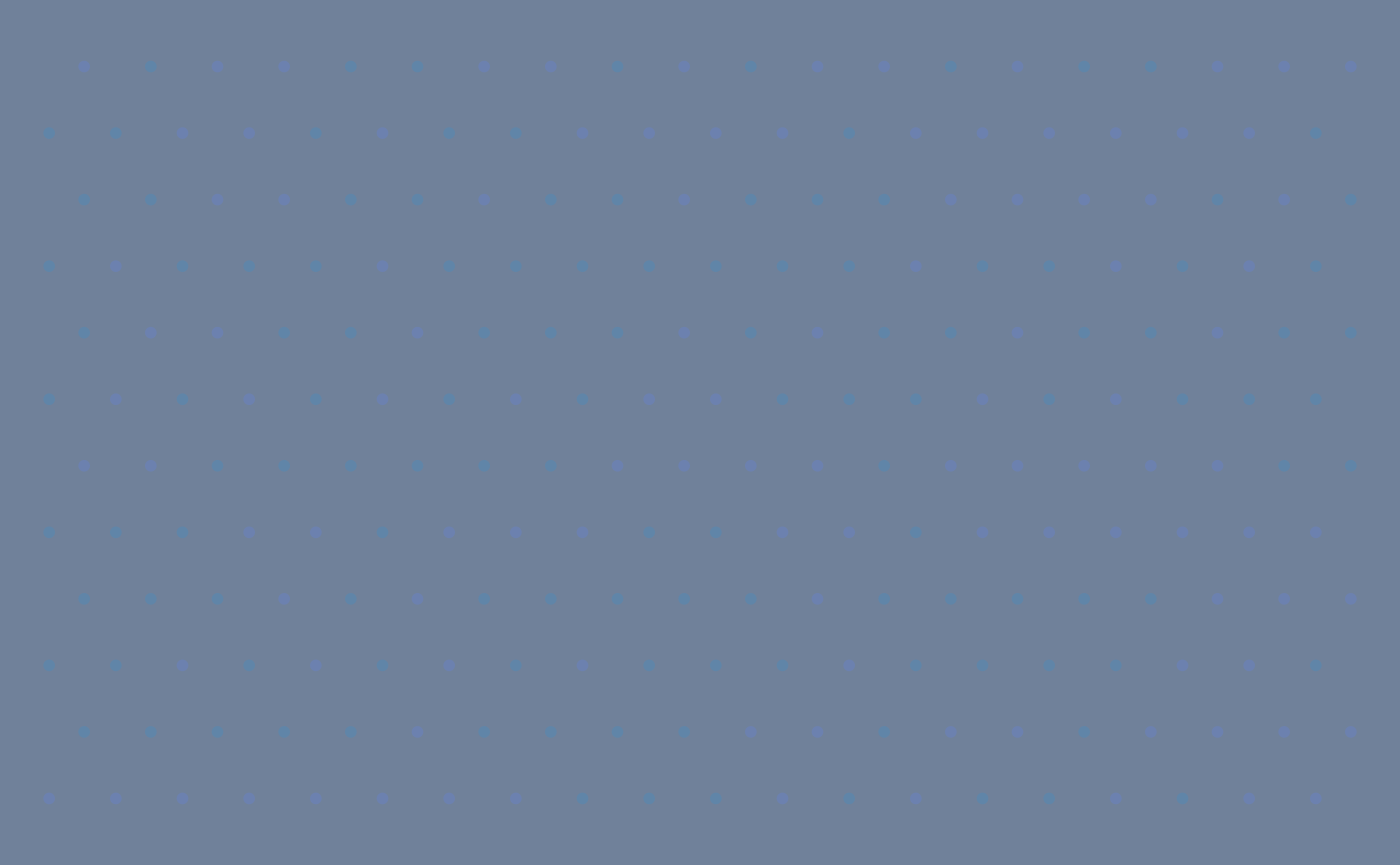

In [9]:
c_ref = 240
c_std = 8
s_ref = .6
s_std = .4
opts = {"N_height": N_height, "N_width": N_width, # image size
        "N_H": N_H, "N_W": N_W, # grid size
        "shape_mode": 'circular', "n_sides": 6, # shapes
        "size_mag": .1618, # size of the shapes
        "alpha": 1., # transparency
        "c_mean": c_ref, "c_std": c_std, # HUE
        "s_mean": s_ref, "s_std": s_std, # STAURATION
        "operator": cairo.OPERATOR_OVER, # blending mode
        }

@disp
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)

### Baseline Stimulus Interpretation

First, this stage defines the reference image that all later comparisons rely on, so no perceptual claim should be made without checking this baseline. Second, the associated code instantiates one fixed parameter vector and renders the corresponding field for inspection and export. Third, the expected visual pattern is a central region with clearer segmentation than the periphery, which is consistent with stronger cone-mediated color and fine-form sampling near the fovea and broader rod-dominated pooling at larger eccentricities.

In [10]:
def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts)
render_pdf(draw, savepath)
render_svg(draw, savepath)

## Parameter Sweeps

Each sweep modifies a single control variable while keeping the others fixed. This strategy isolates causal effects and makes the resulting perceptual transitions easier to interpret.

In [11]:
N_scan = 9

## alpha

alpha_=1.00e-01


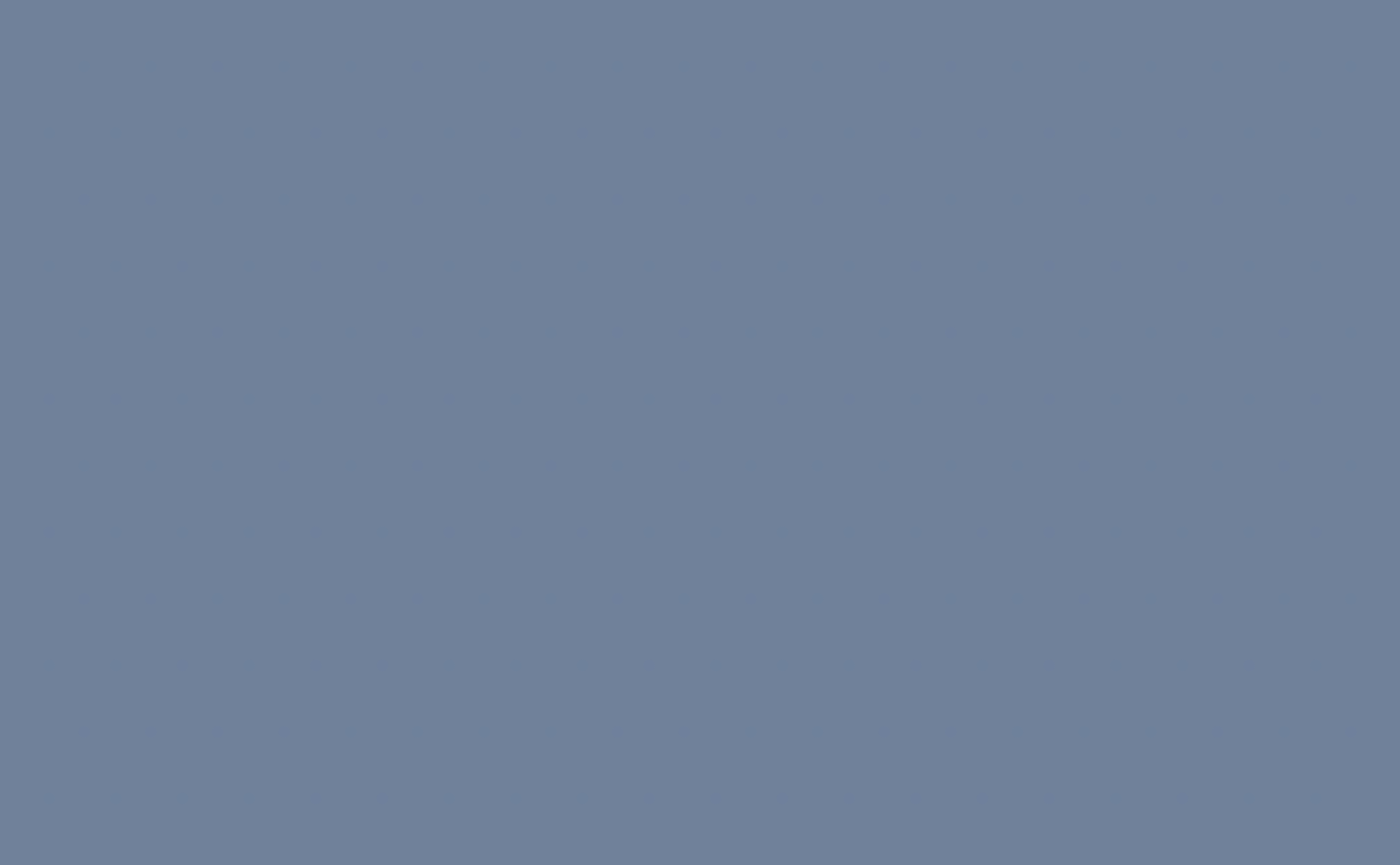

alpha_=2.13e-01


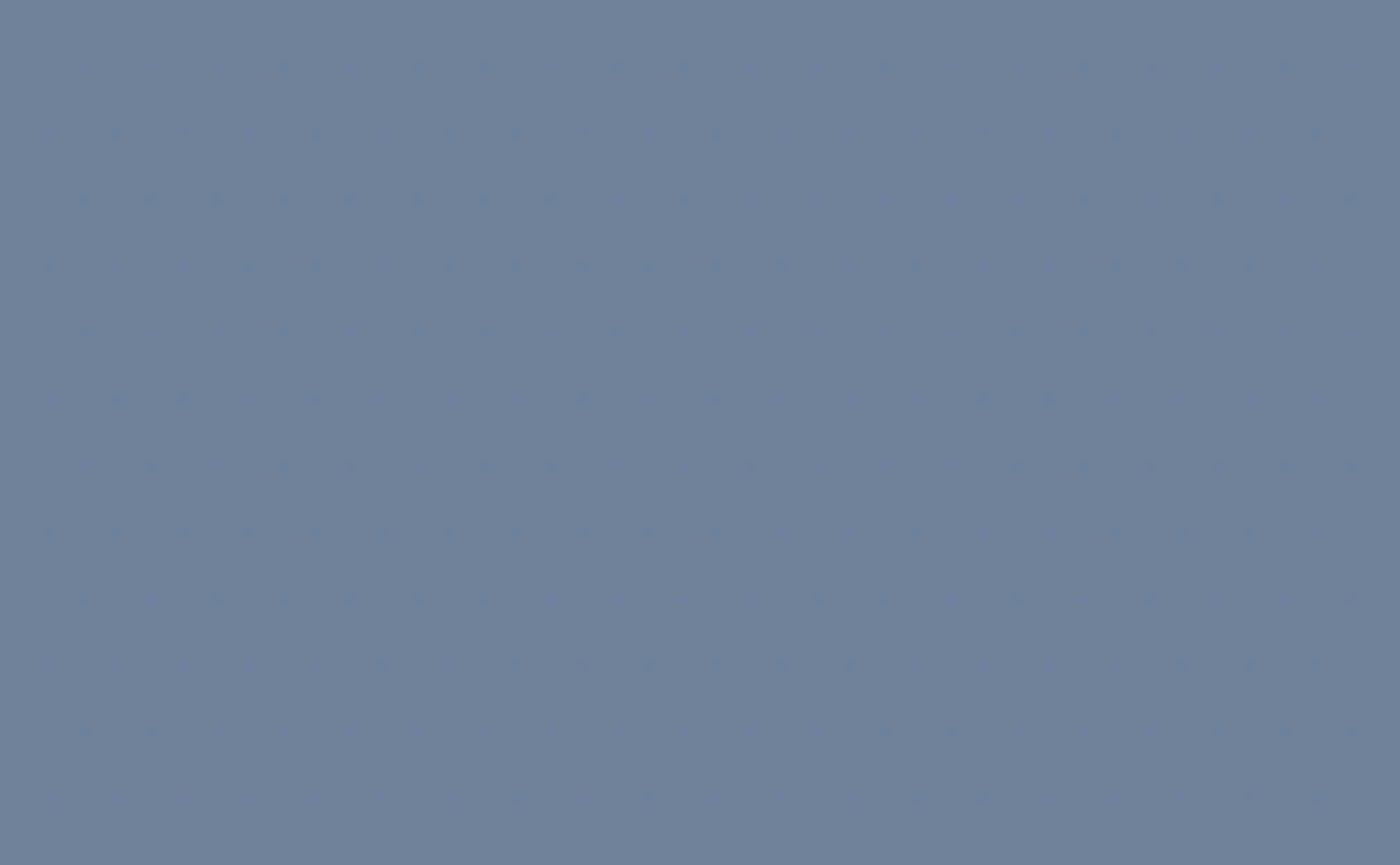

alpha_=3.25e-01


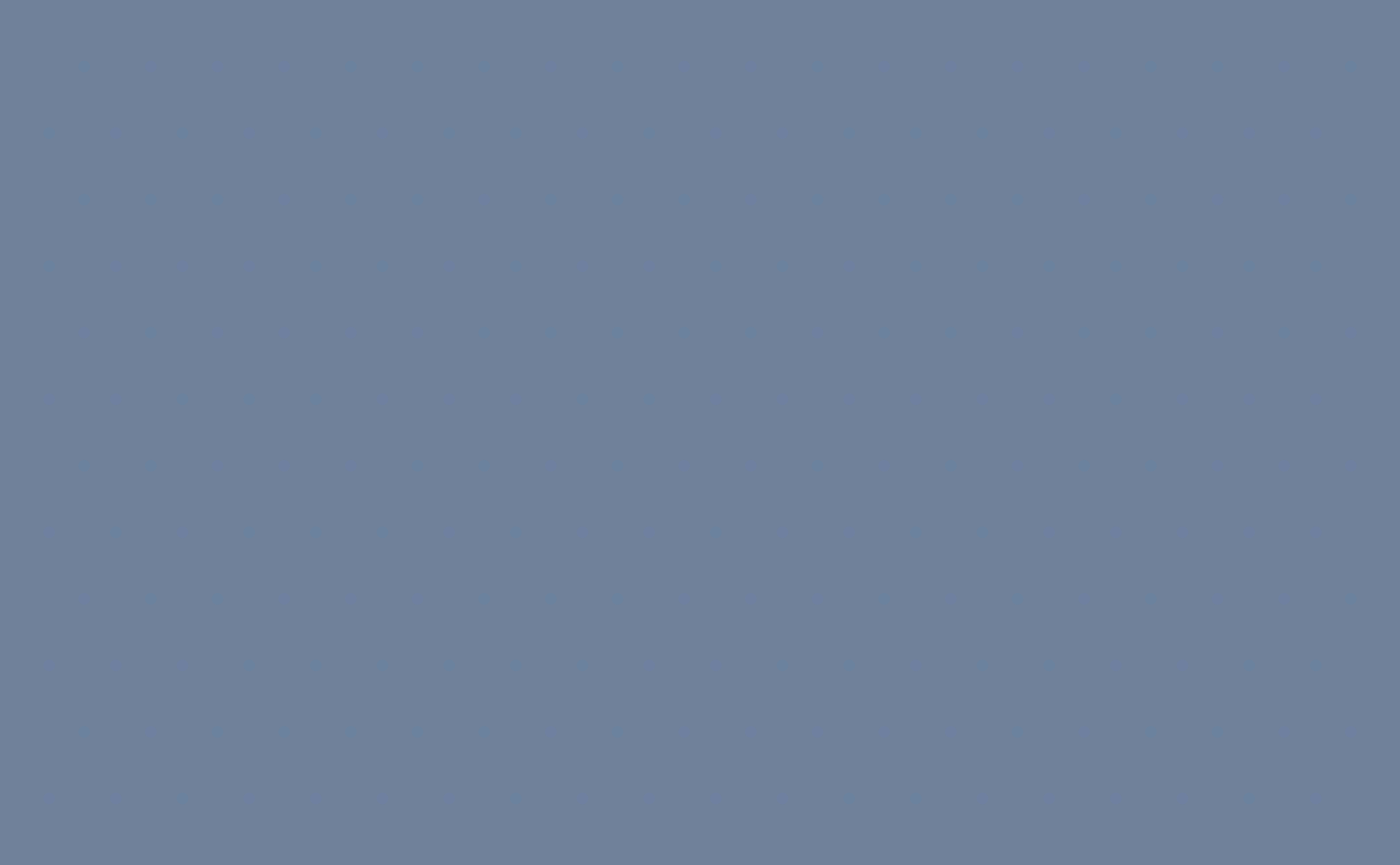

alpha_=4.38e-01


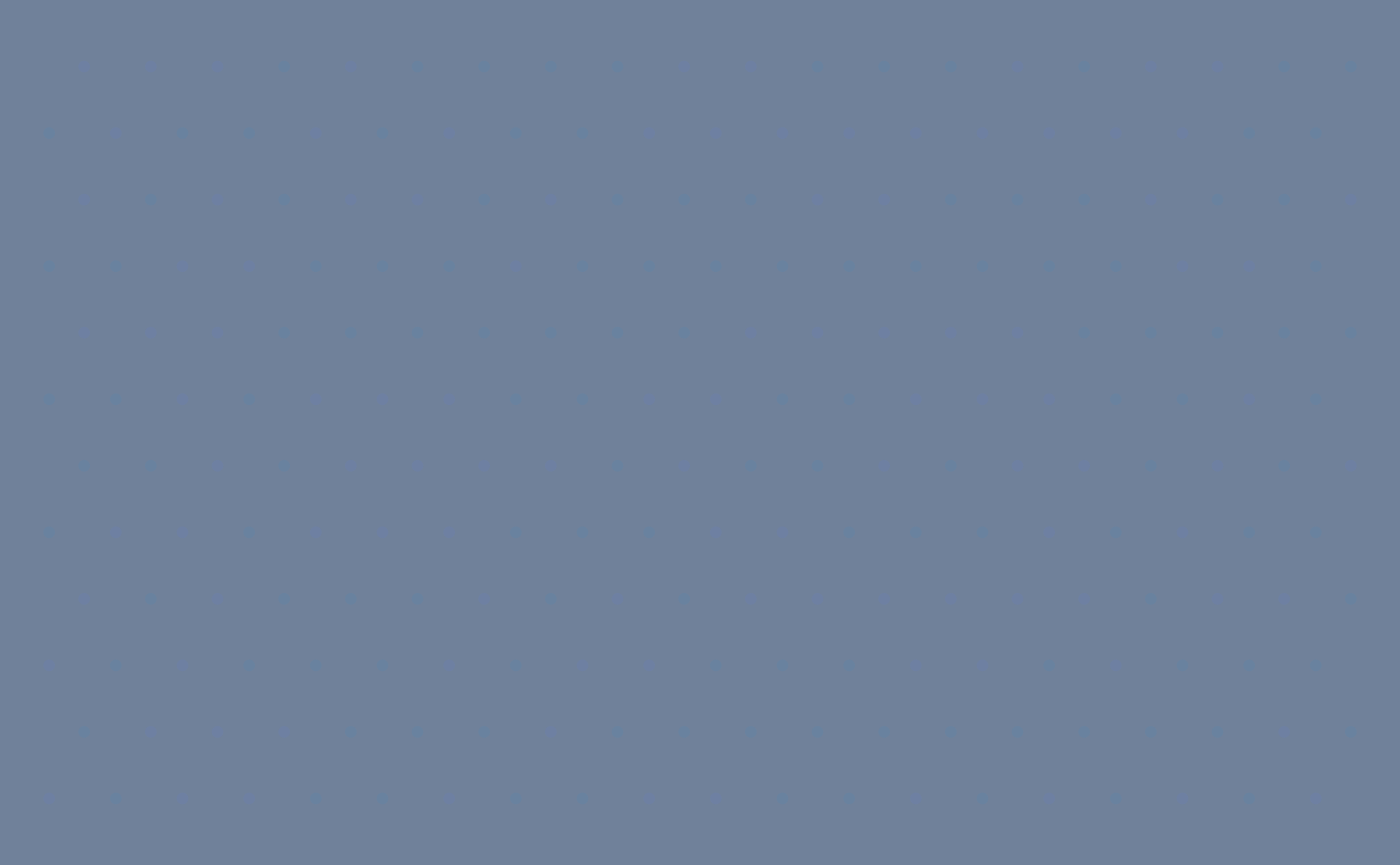

alpha_=5.50e-01


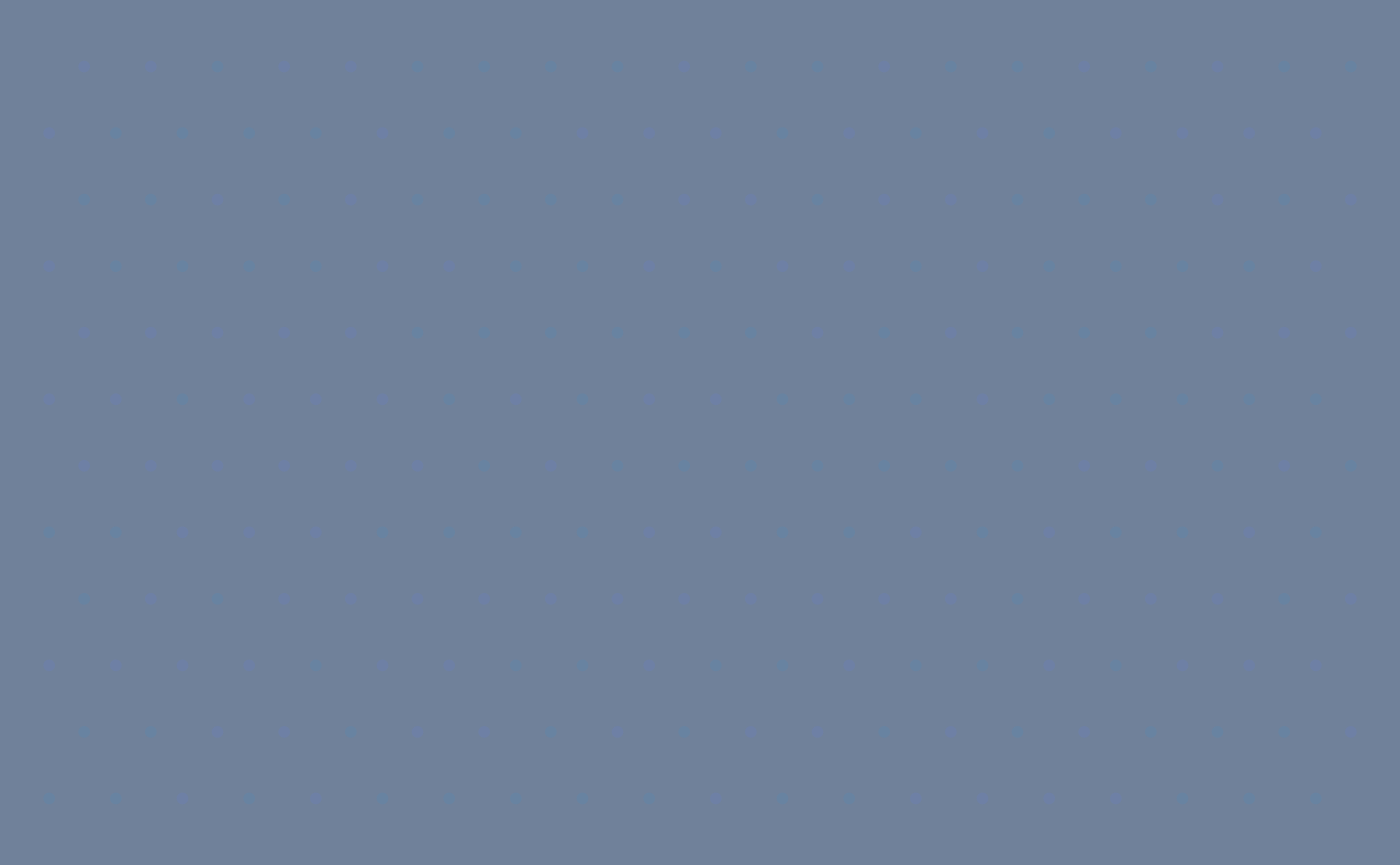

alpha_=6.62e-01


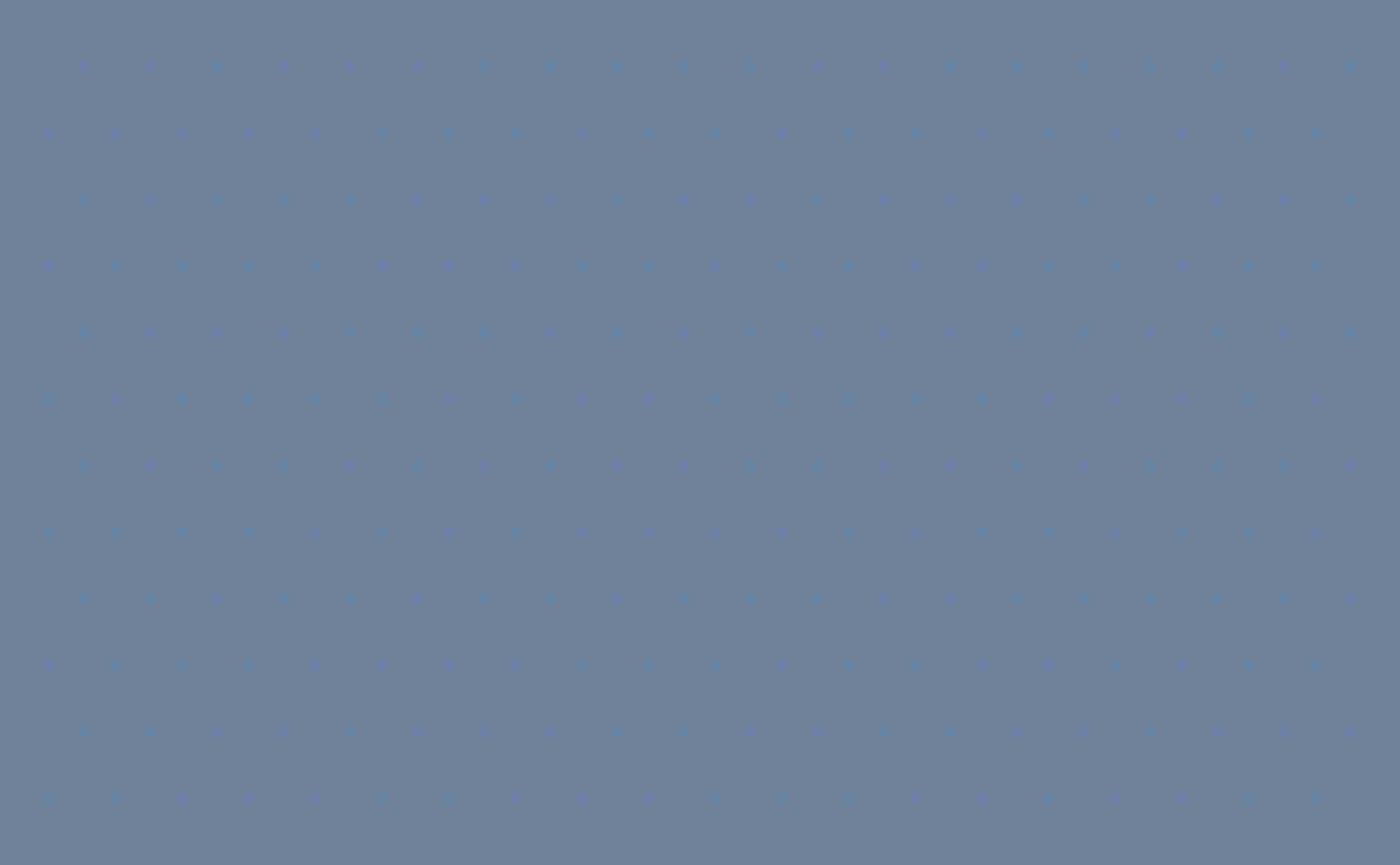

alpha_=7.75e-01


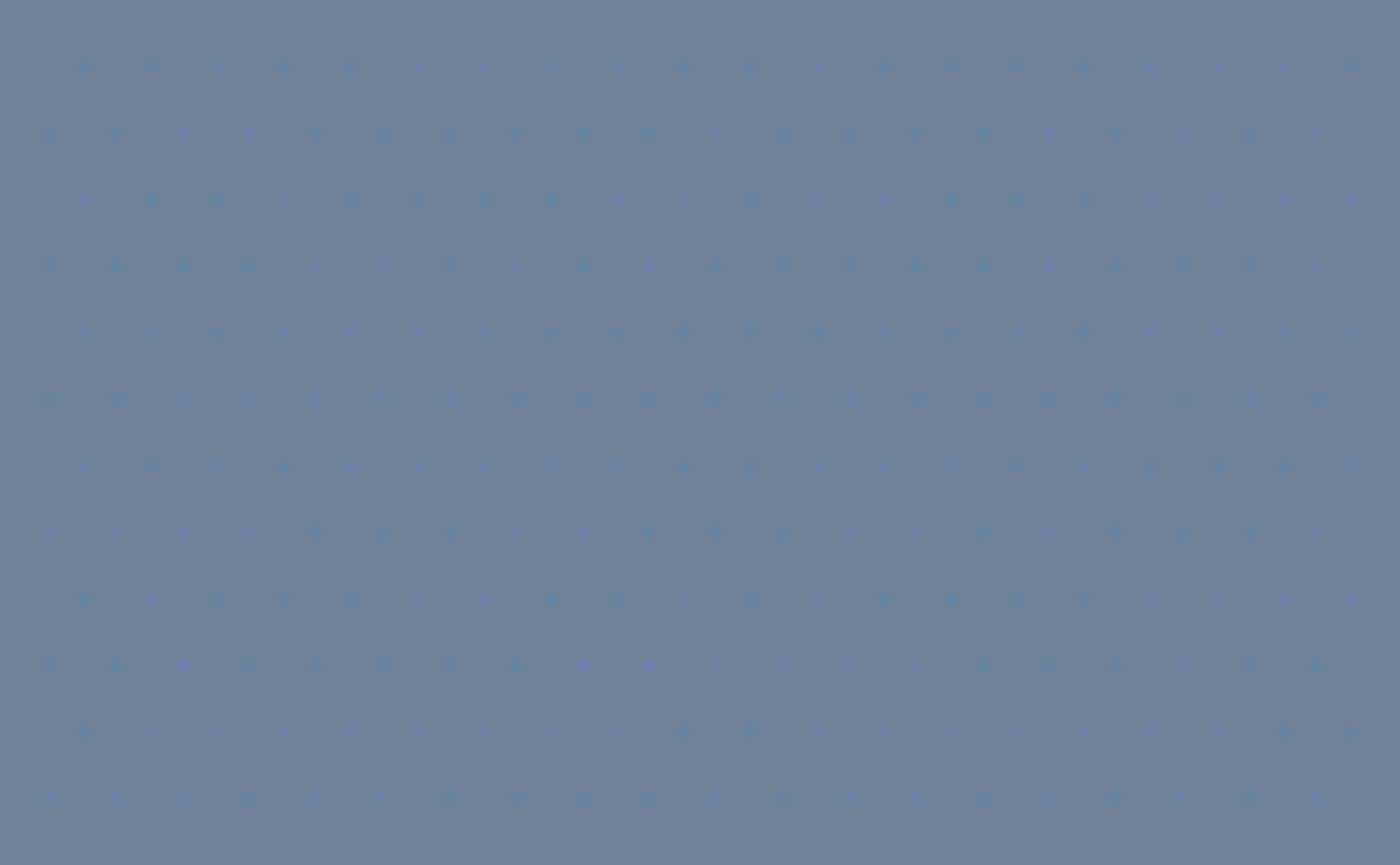

alpha_=8.87e-01


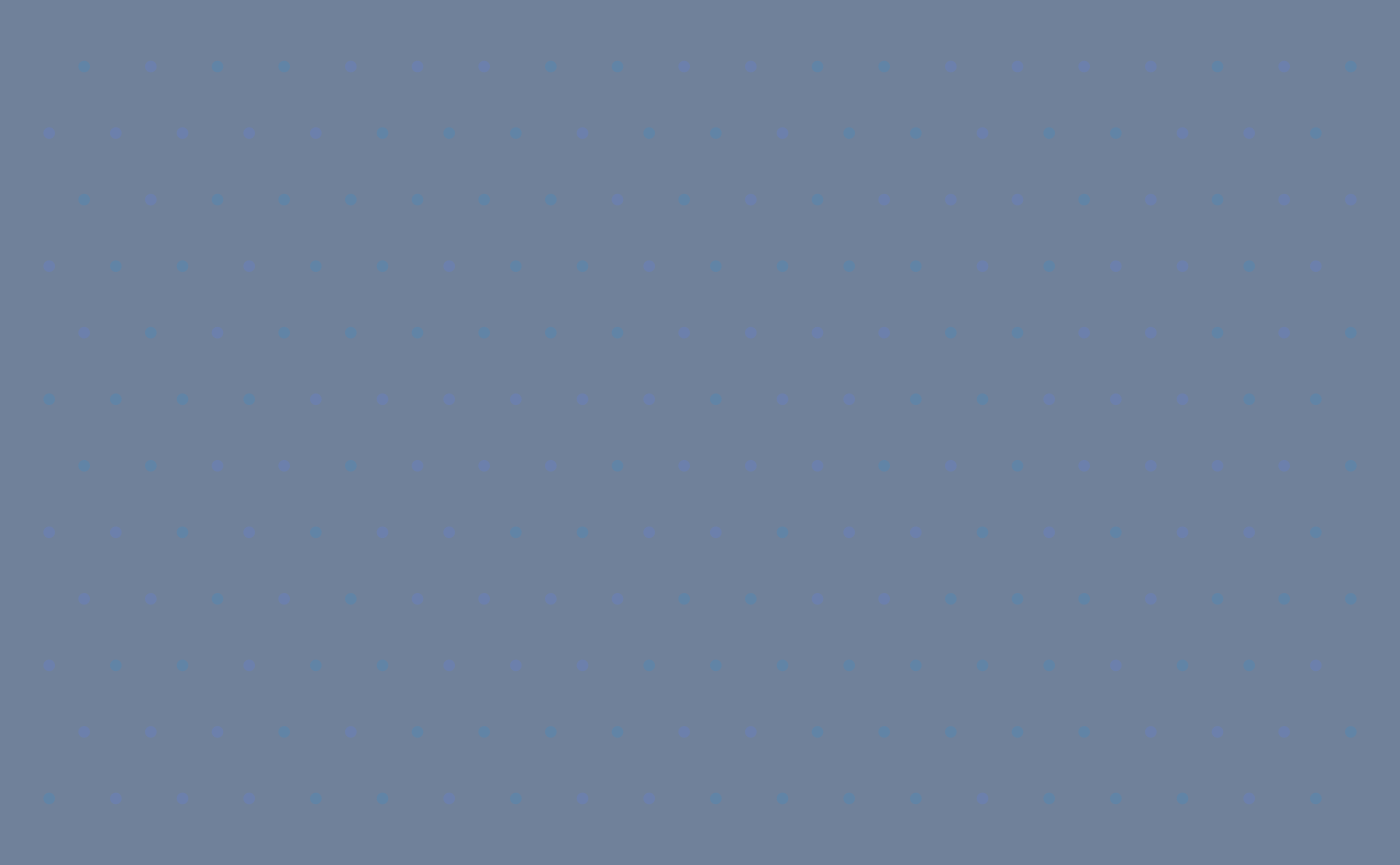

alpha_=1.00e+00


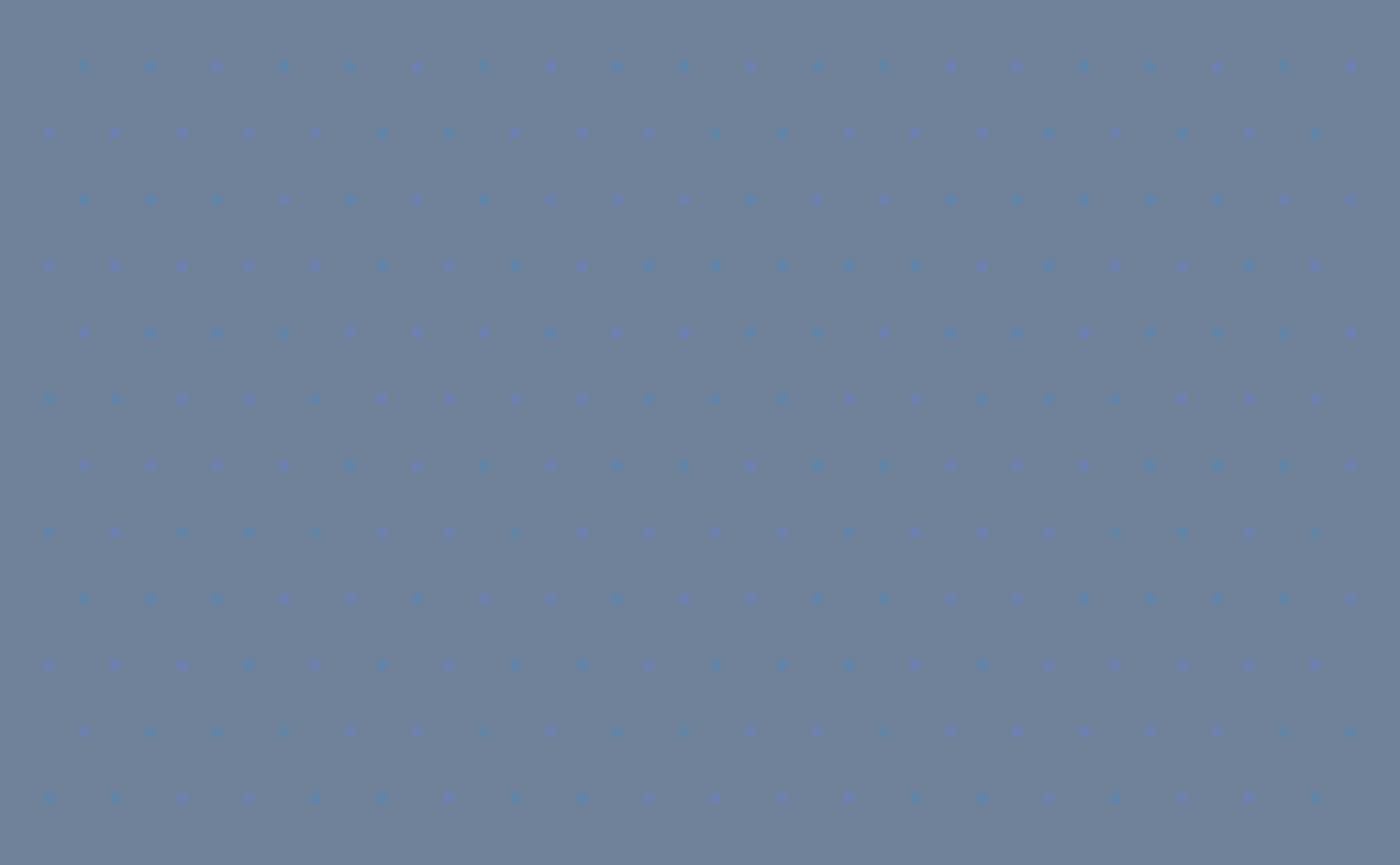

In [12]:
opts_ = opts.copy()
for alpha_ in np.linspace(0.1, 1., N_scan, endpoint=True): 
    opts_.update(alpha=alpha_)
    print(f'{alpha_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: Alpha (Opacity)

First, this sweep changes only opacity, which directly scales the effective contrast of each dot against the background. Second, the code iterates over alpha values and displays one rendered frame per value so that visibility transitions can be read continuously. Third, low alpha usually suppresses segmentation everywhere, high alpha usually stabilizes structure everywhere, and an intermediate alpha often maximizes the fixation advantage expected from foveal cone precision relative to peripheral pooling.

## size_mag

size_mag_=1.00e-01


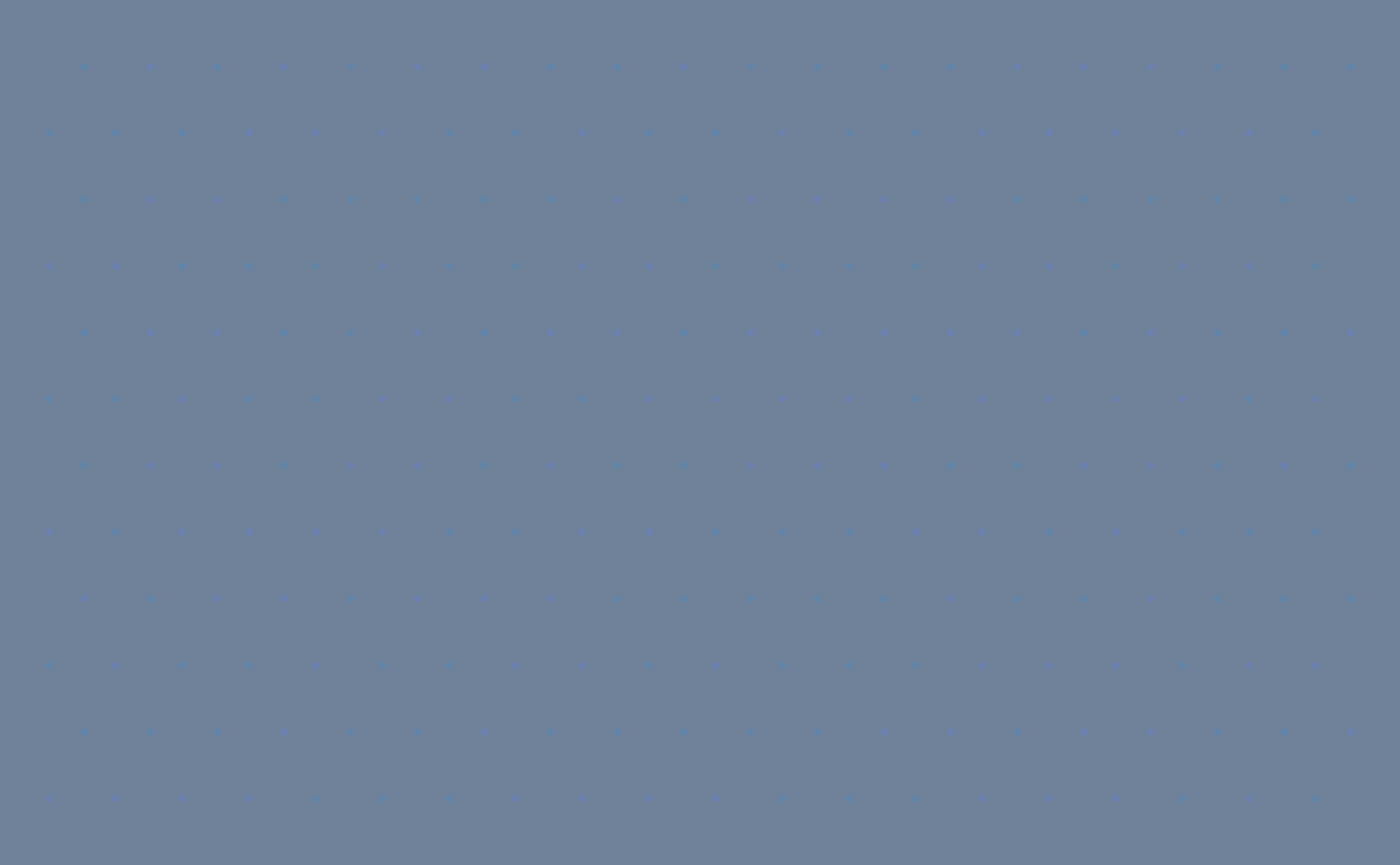

size_mag_=1.19e-01


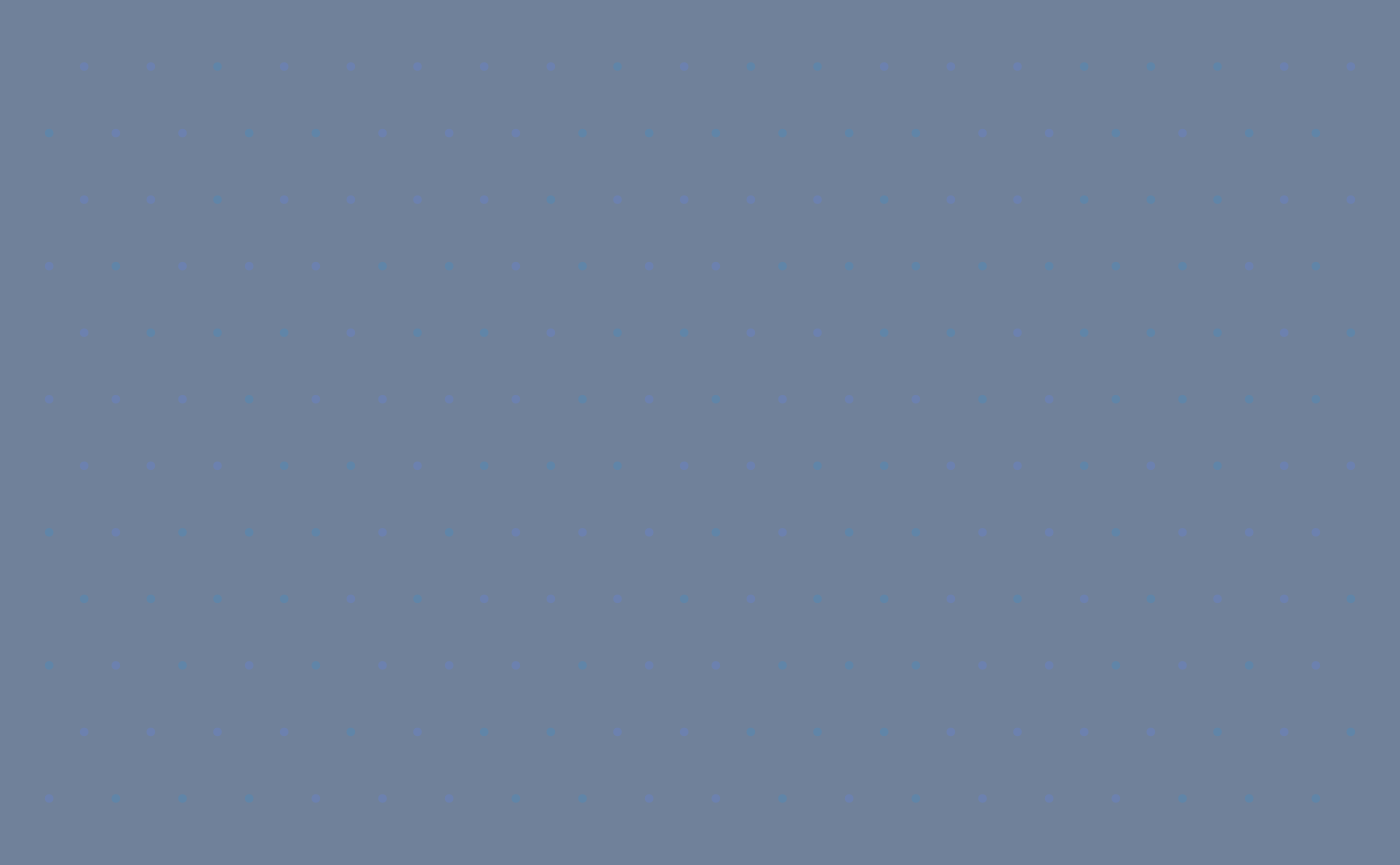

size_mag_=1.41e-01


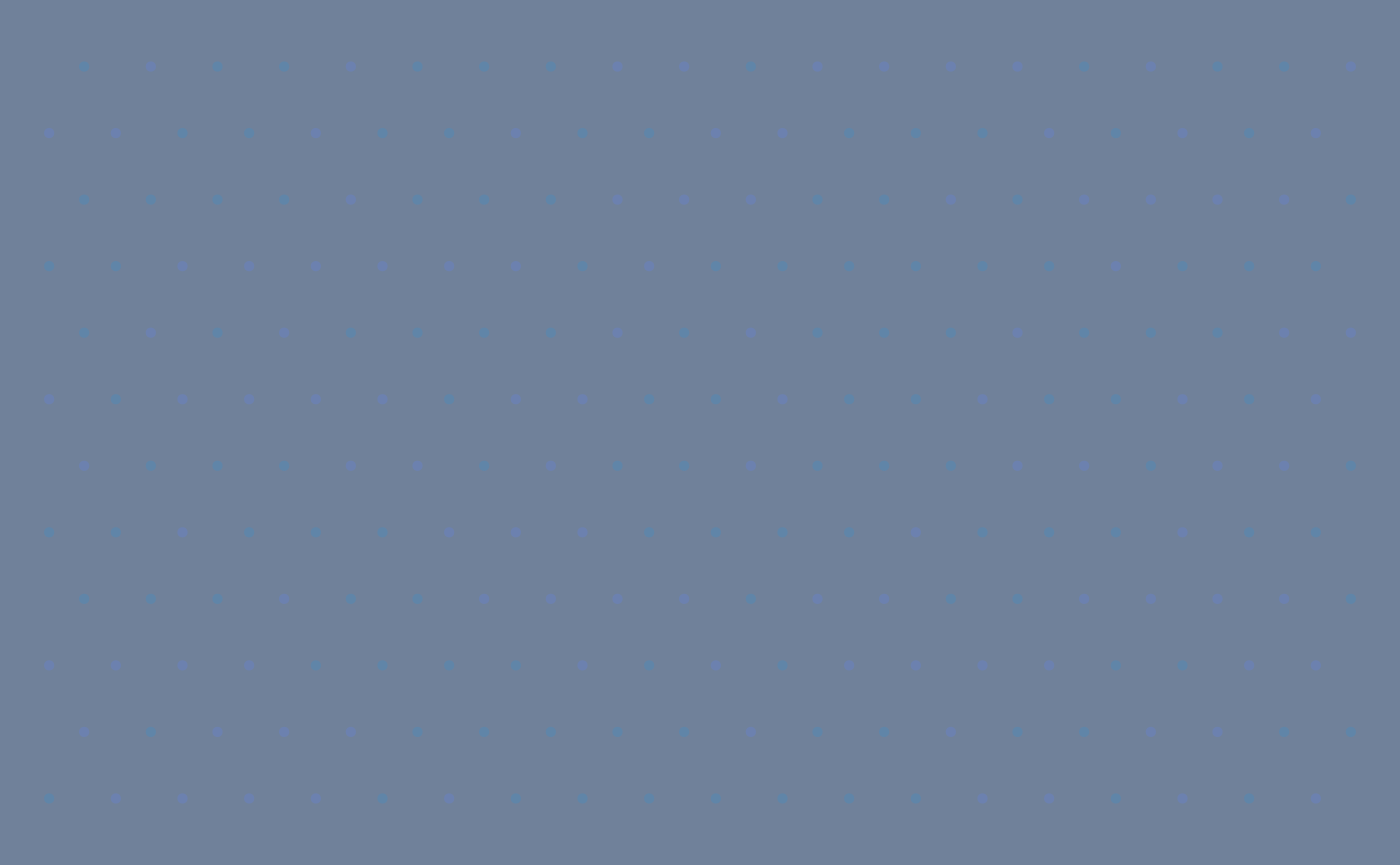

size_mag_=1.68e-01


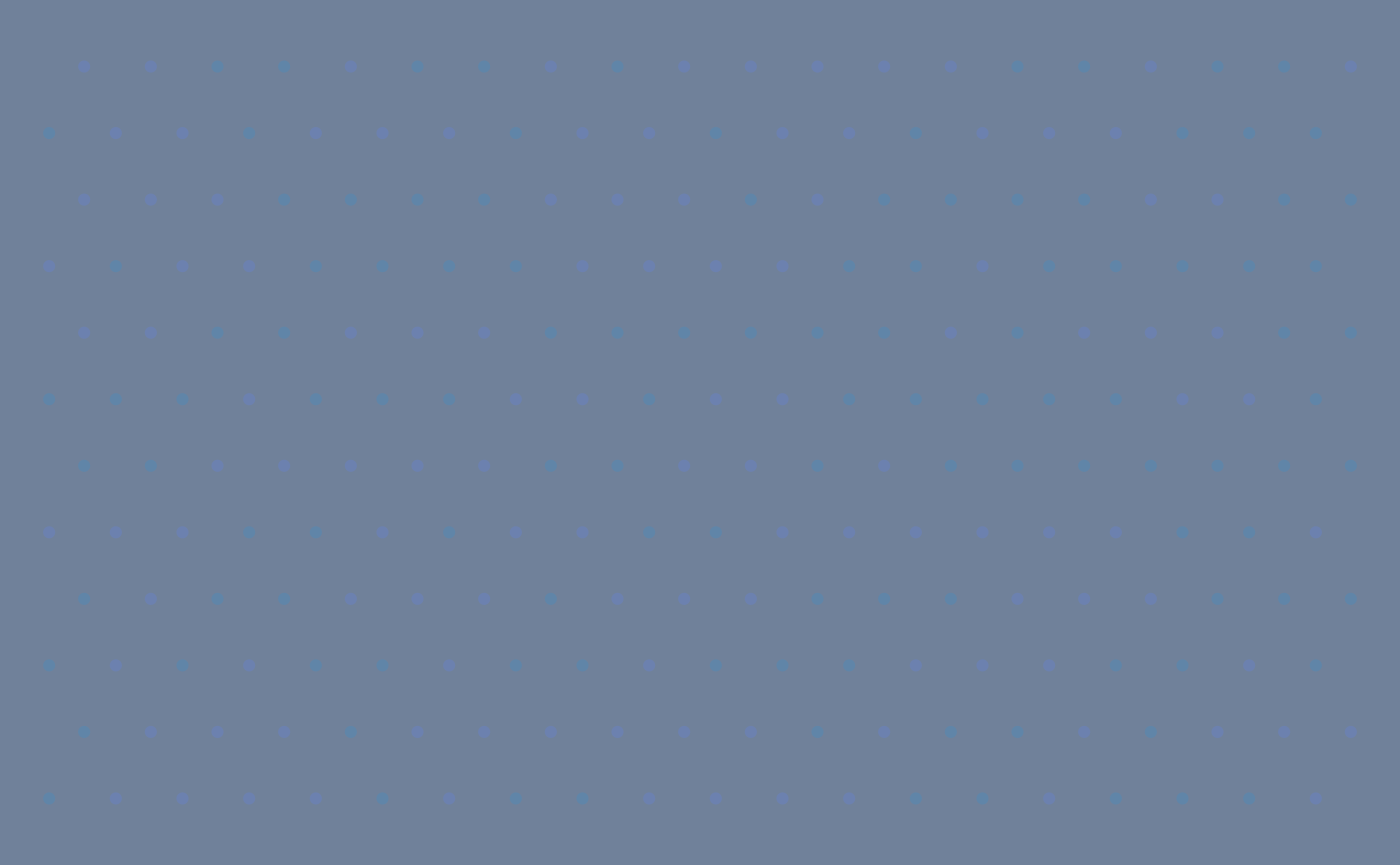

size_mag_=2.00e-01


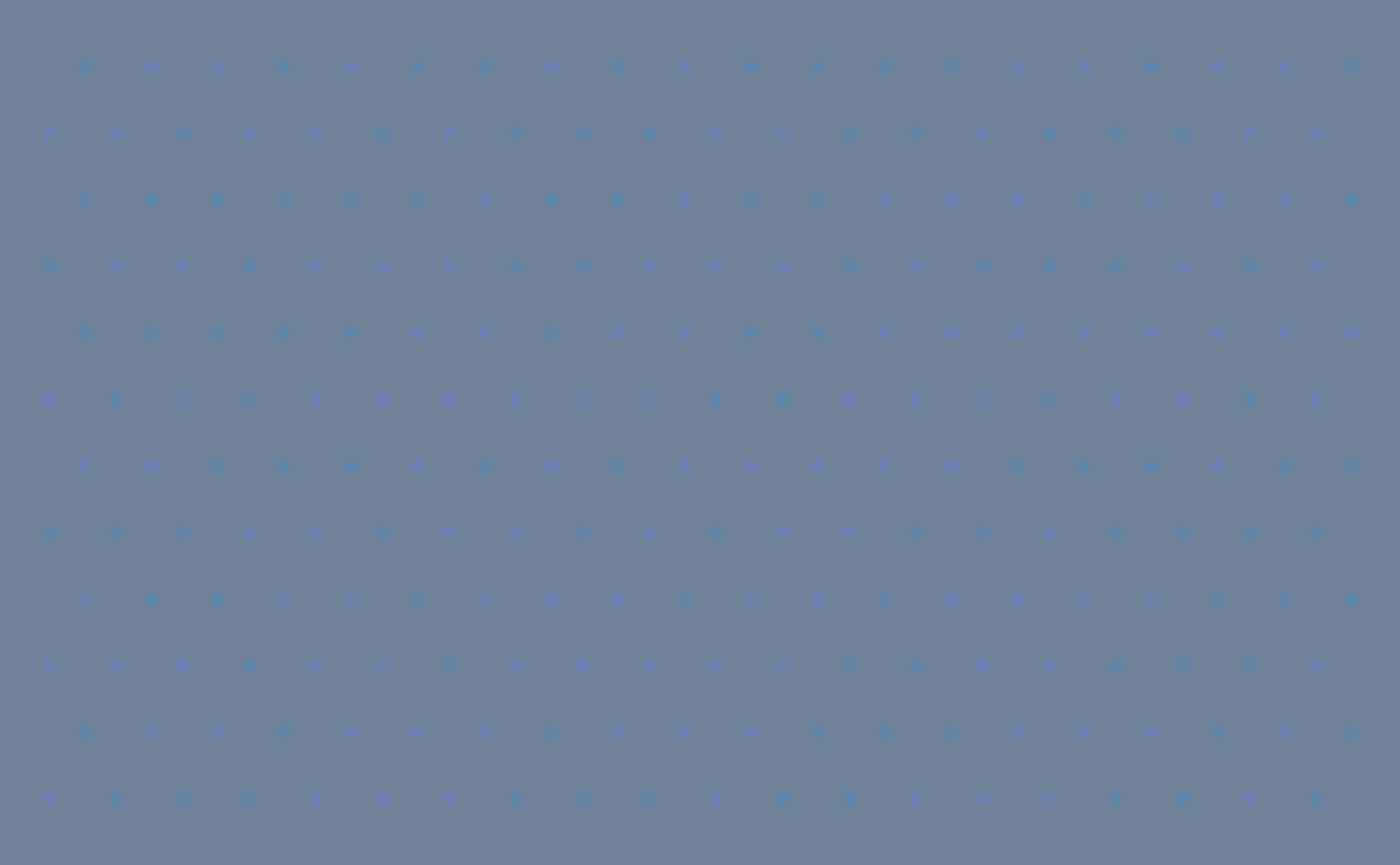

size_mag_=2.38e-01


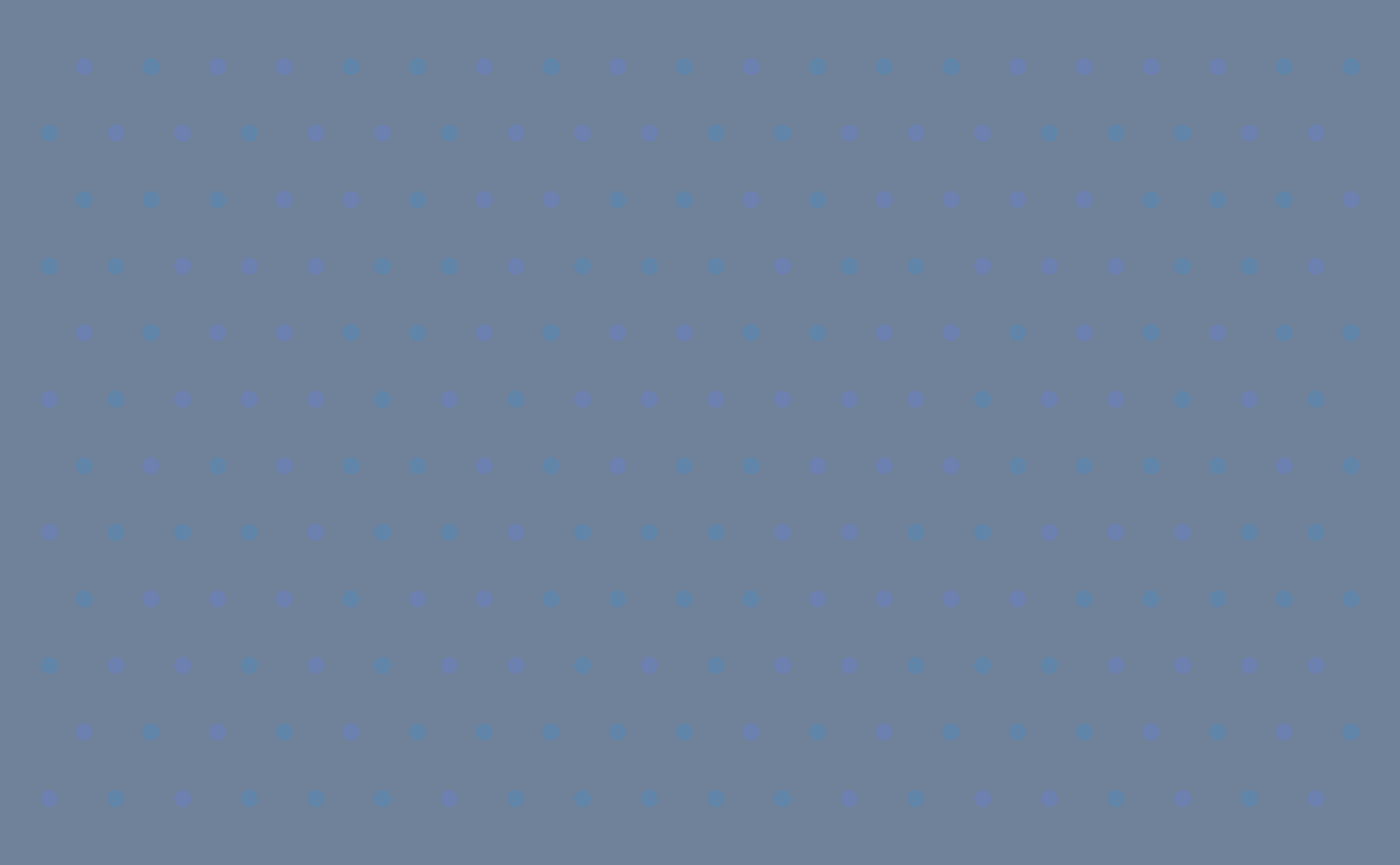

size_mag_=2.83e-01


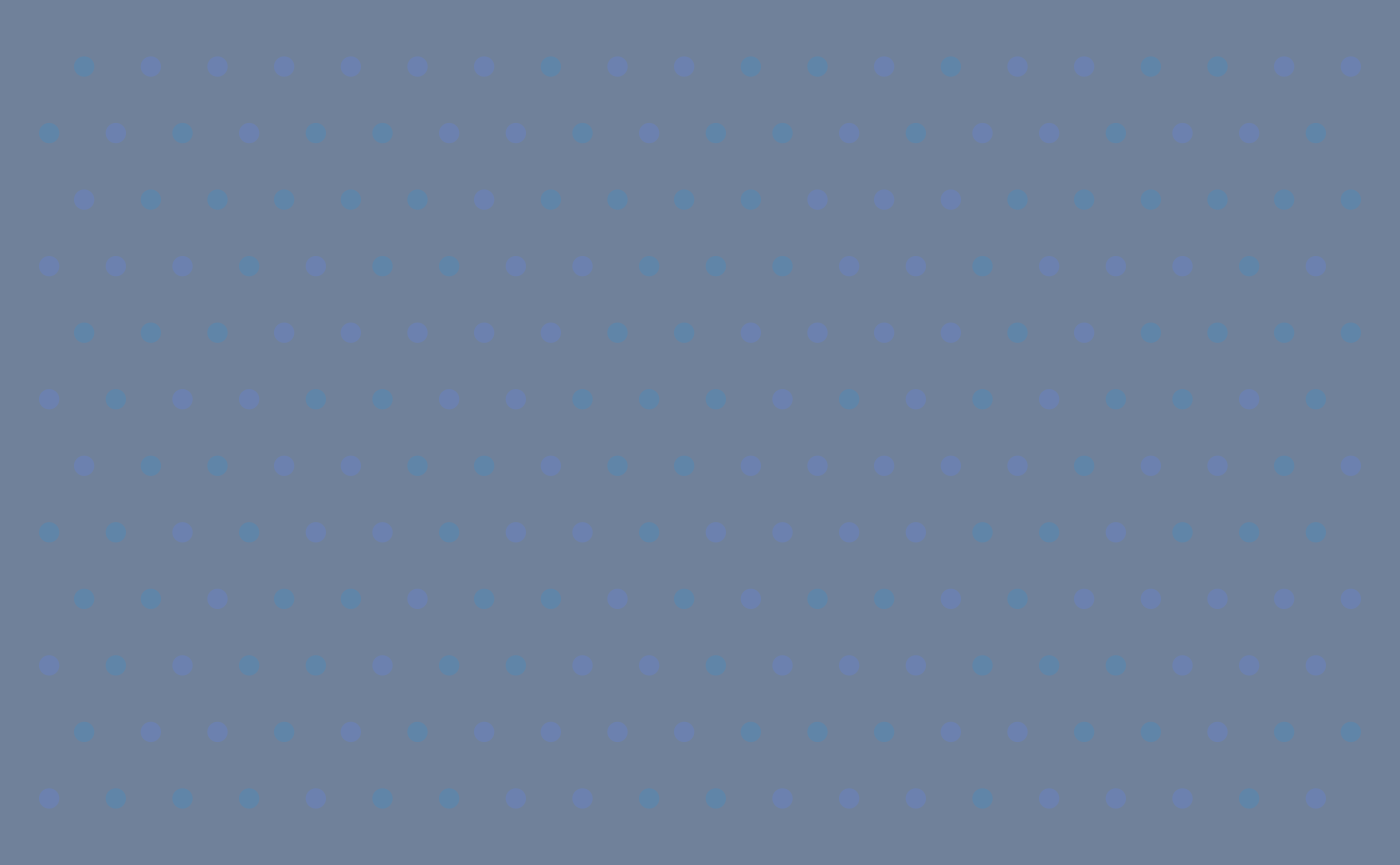

size_mag_=3.36e-01


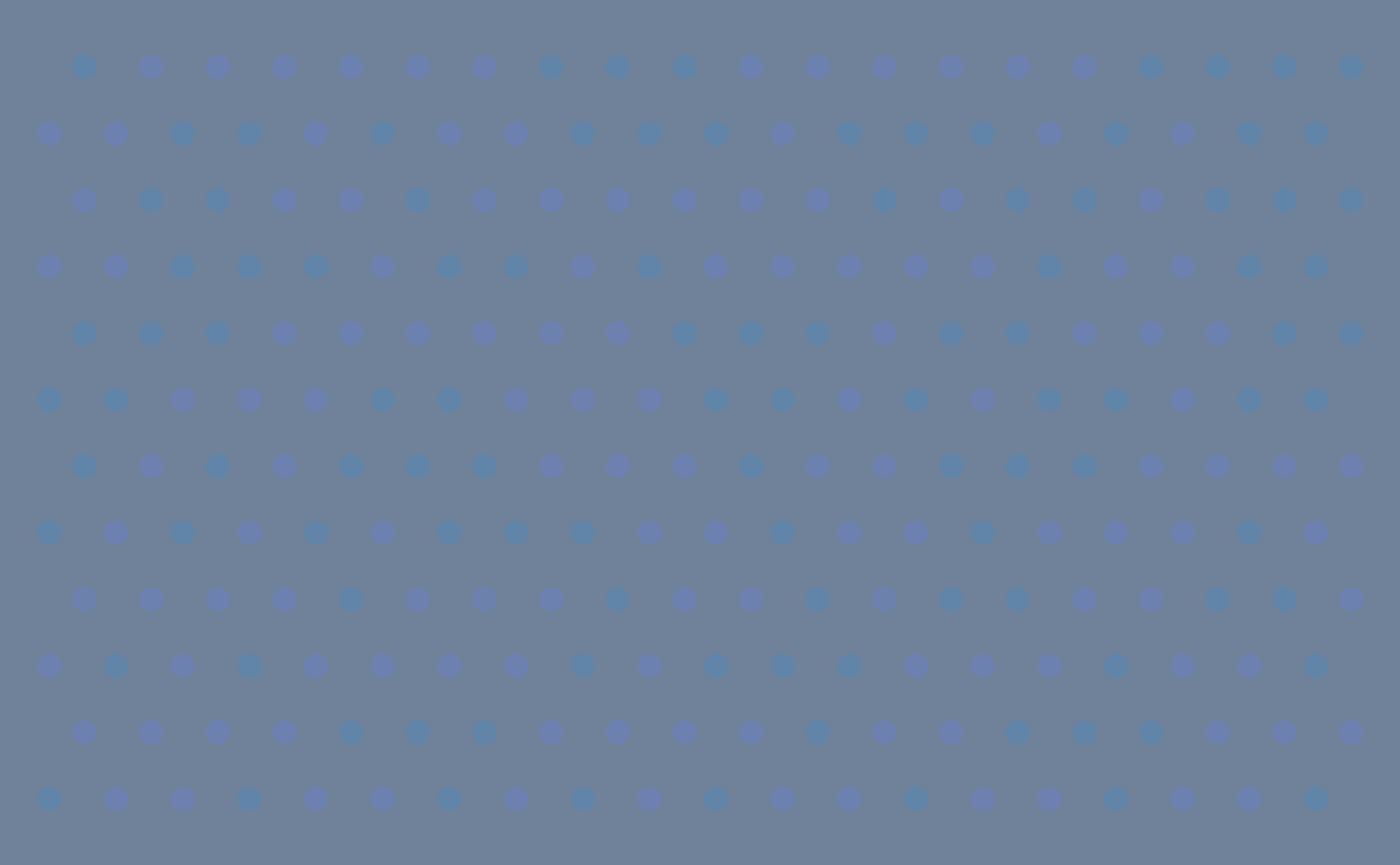

size_mag_=4.00e-01


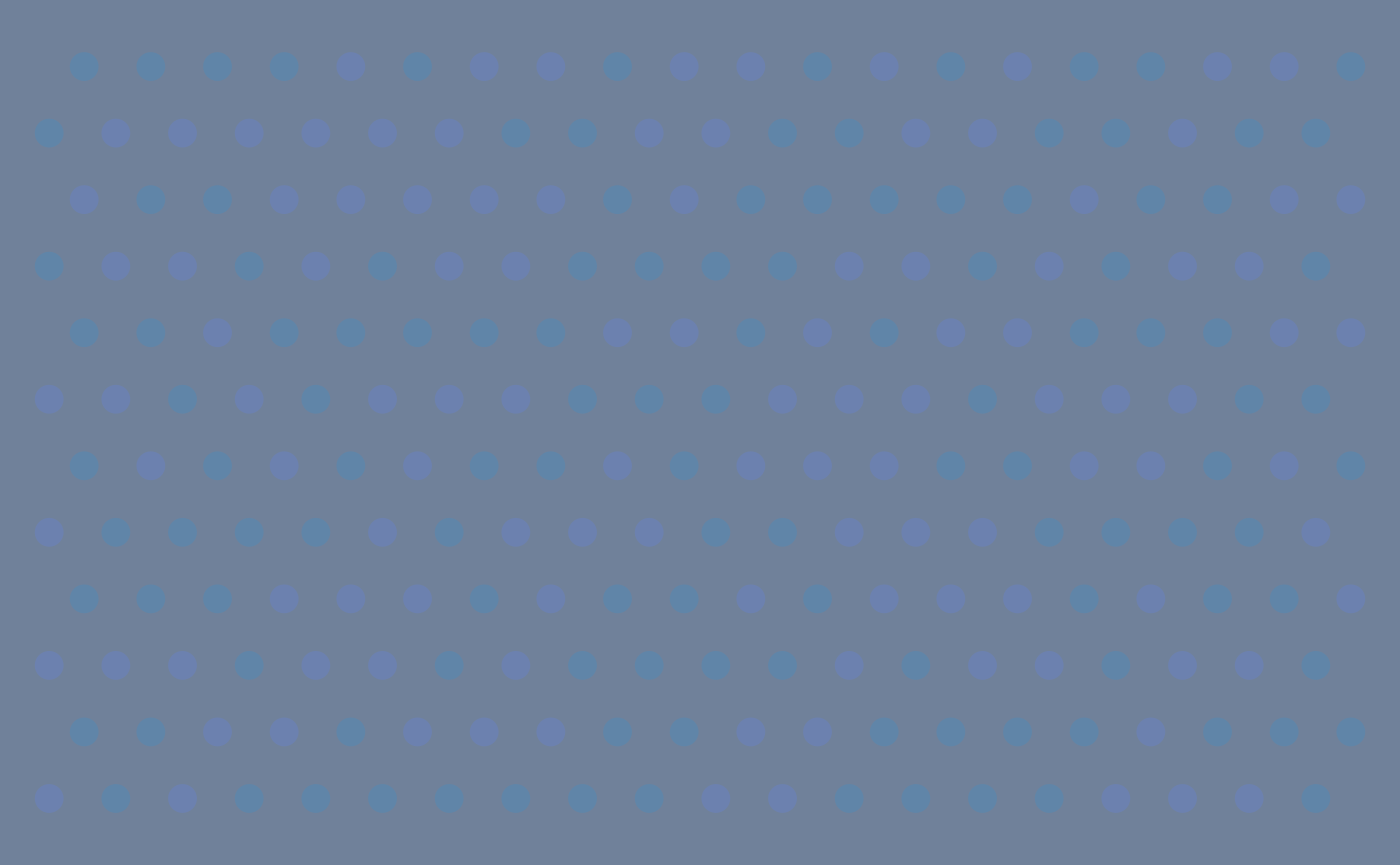

In [13]:
opts_ = opts.copy()
# for size_mag_ in np.geomspace(0.7, 1.4, N_scan, endpoint=True): 
for size_mag_ in np.geomspace(0.1, .40, N_scan, endpoint=True): 
    opts_.update(size_mag=size_mag_)
    print(f'{size_mag_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: size_mag (Dot Size)

First, this sweep changes dot size while preserving lattice topology and color controls. Second, the code scans size on a geometric scale and displays each resulting image, which is necessary because perceived size effects are nonlinear. Third, very small dots can approach threshold globally, very large dots become robustly visible across the field, and intermediate sizes often produce the strongest center-periphery dissociation because foveal sampling resolves fine contours that peripheral integration smooths out.

## c_mean

c_mean_=0.00


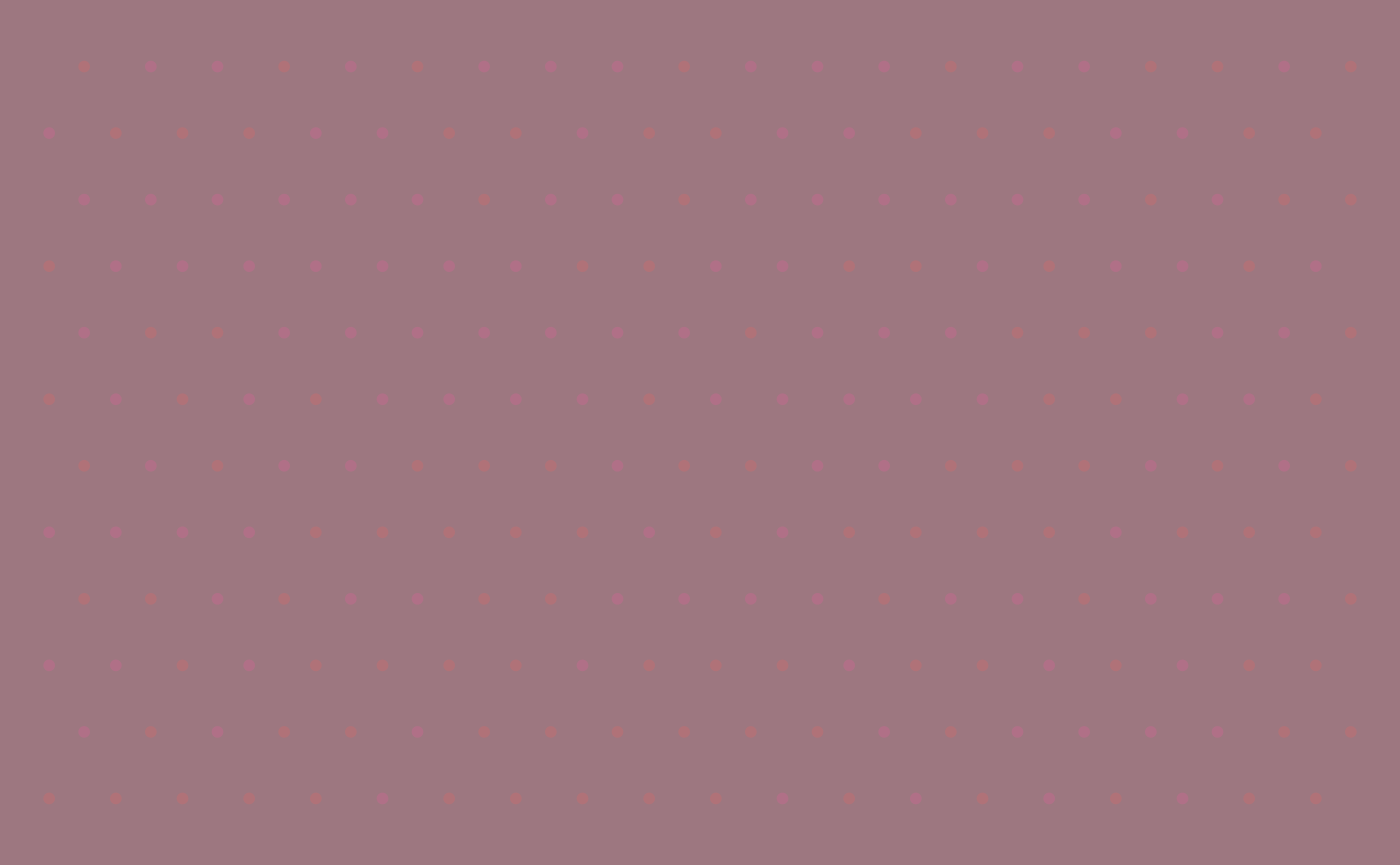

c_mean_=40.00


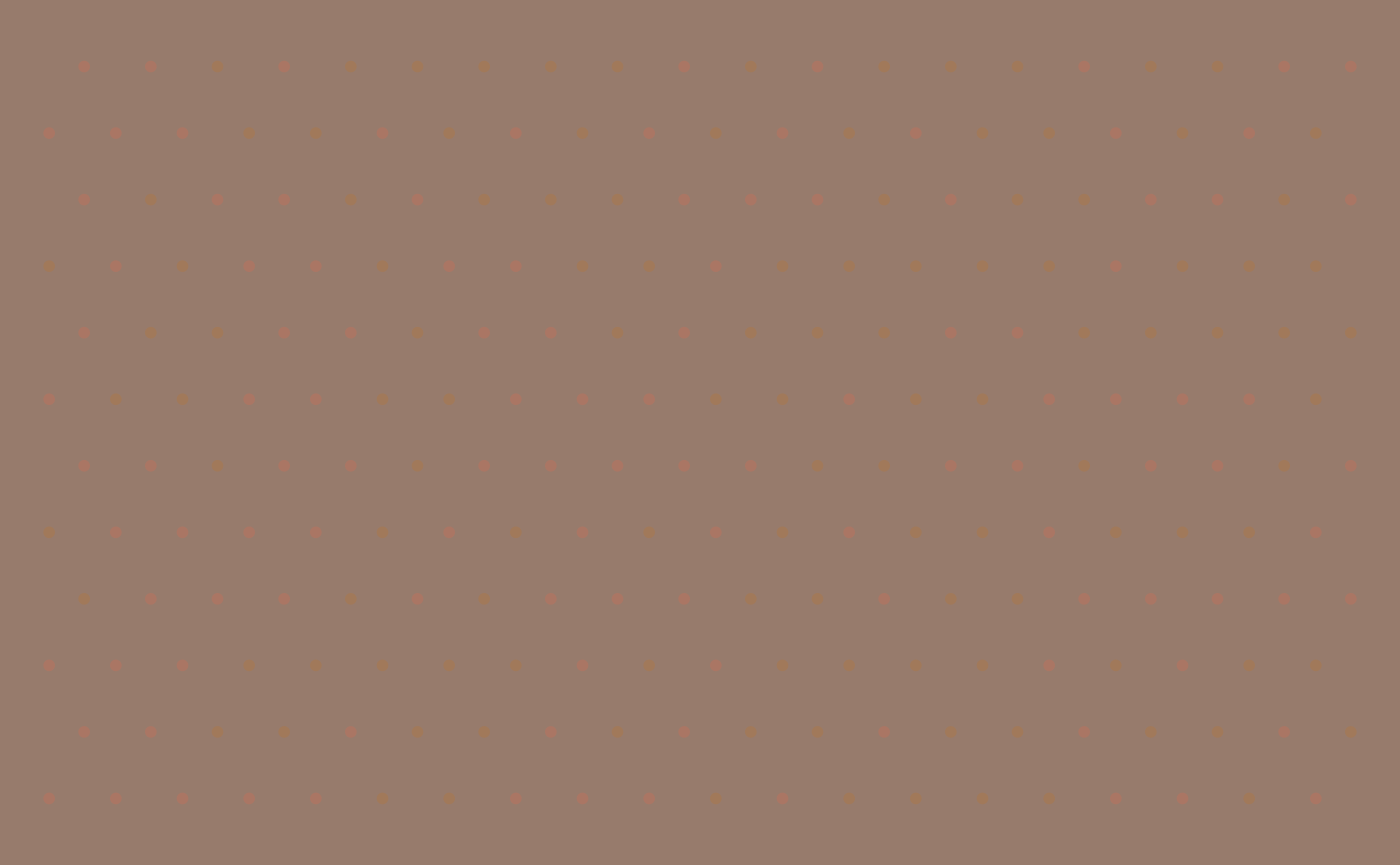

c_mean_=80.00


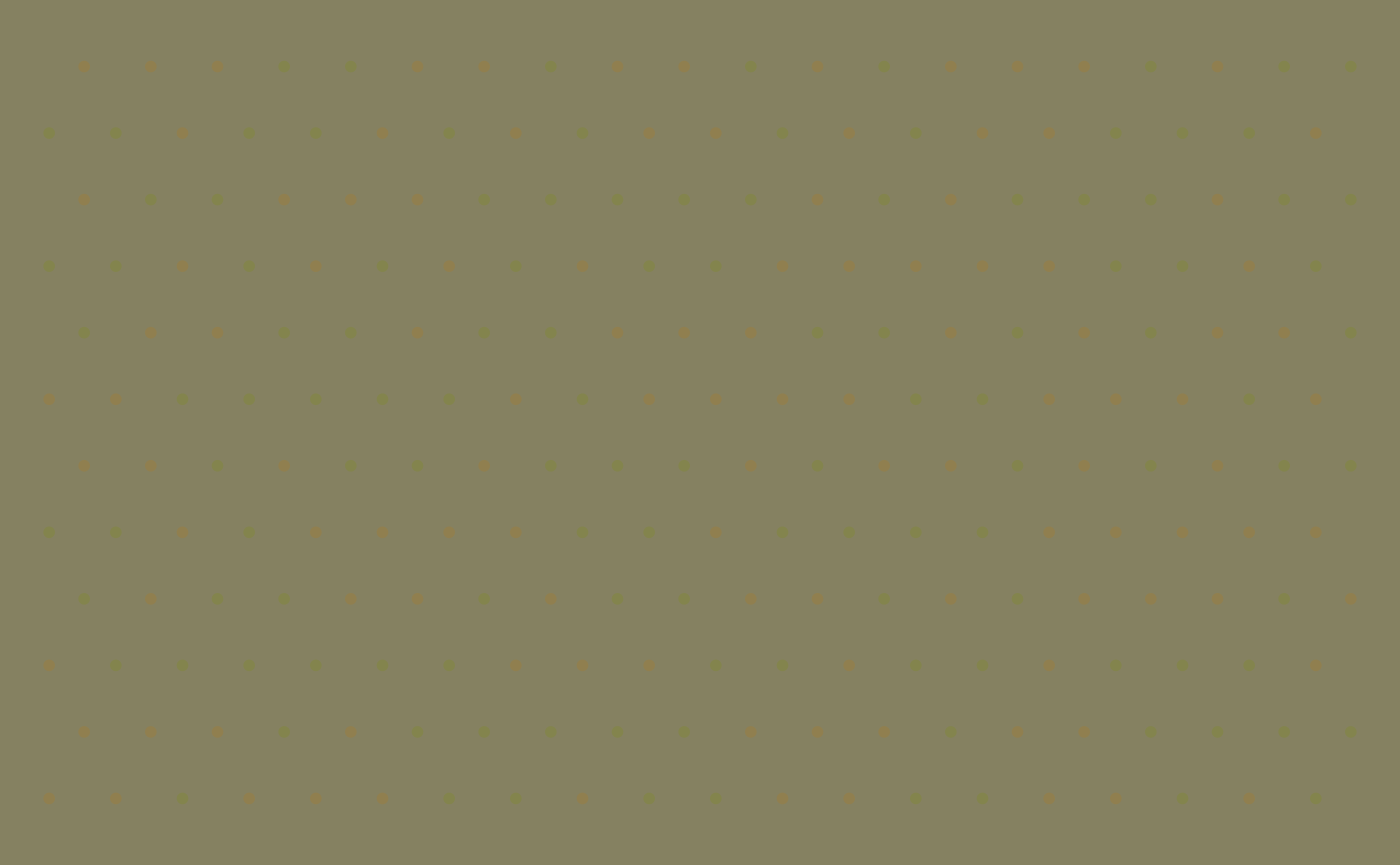

c_mean_=120.00


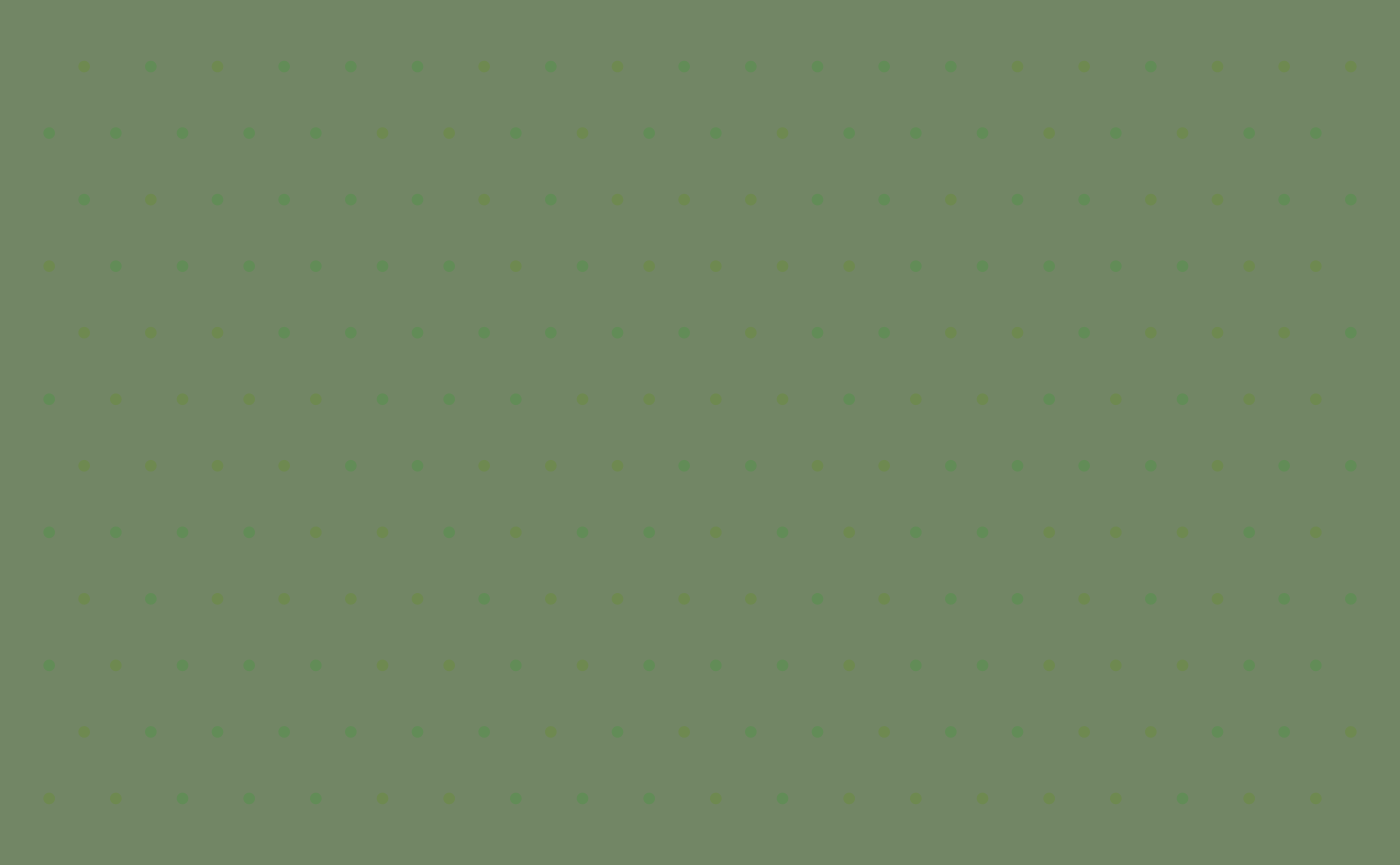

c_mean_=160.00


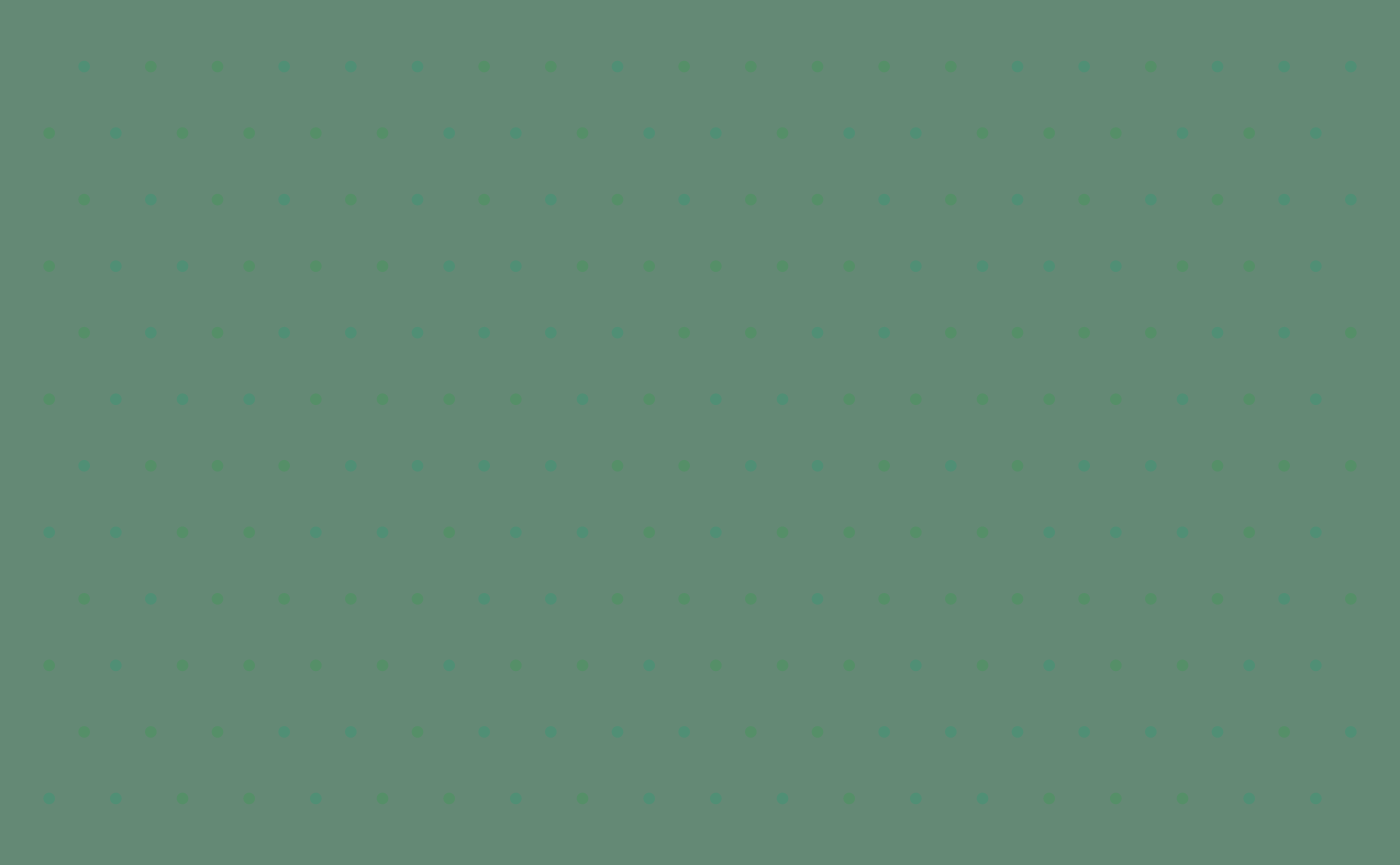

c_mean_=200.00


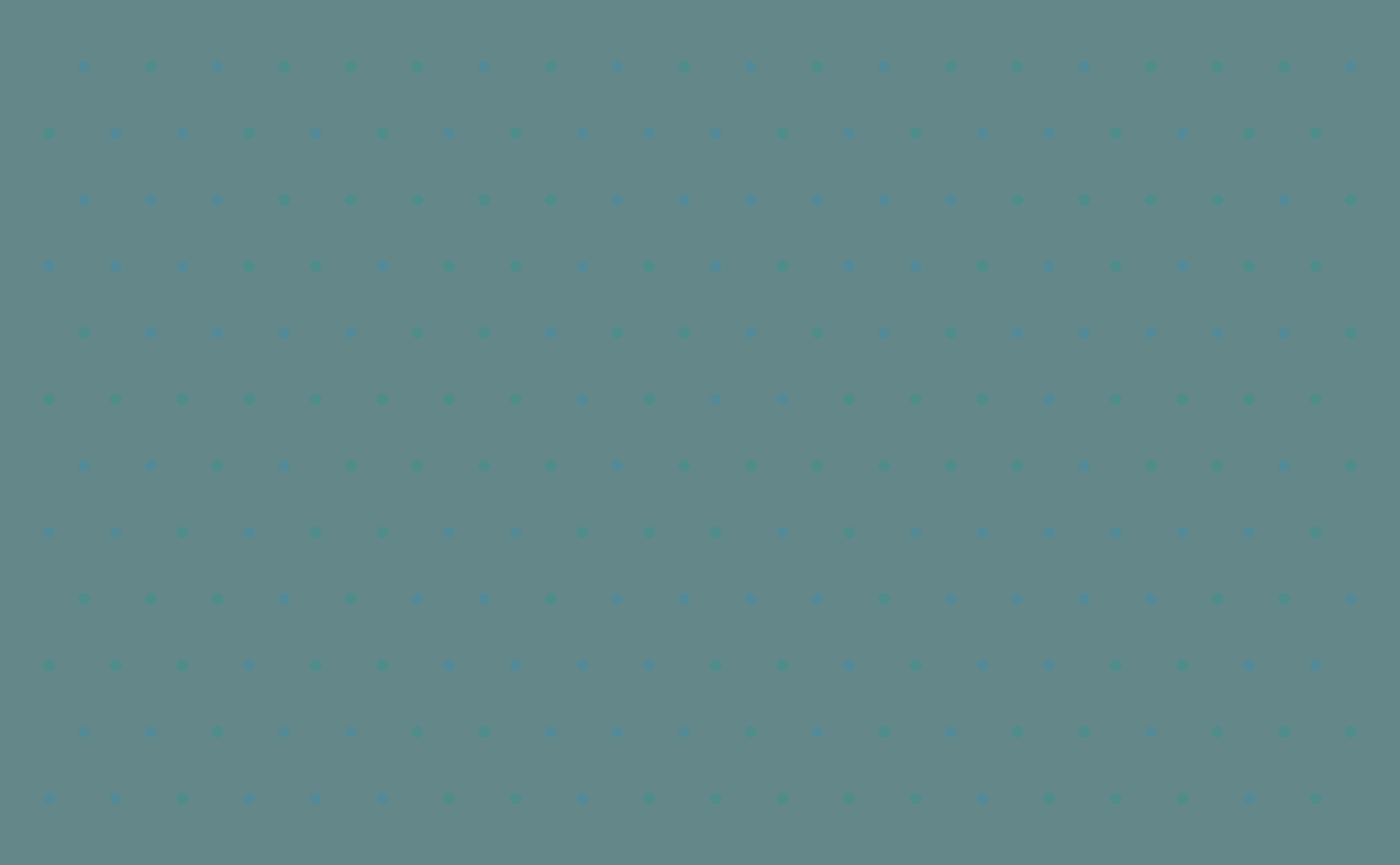

c_mean_=240.00


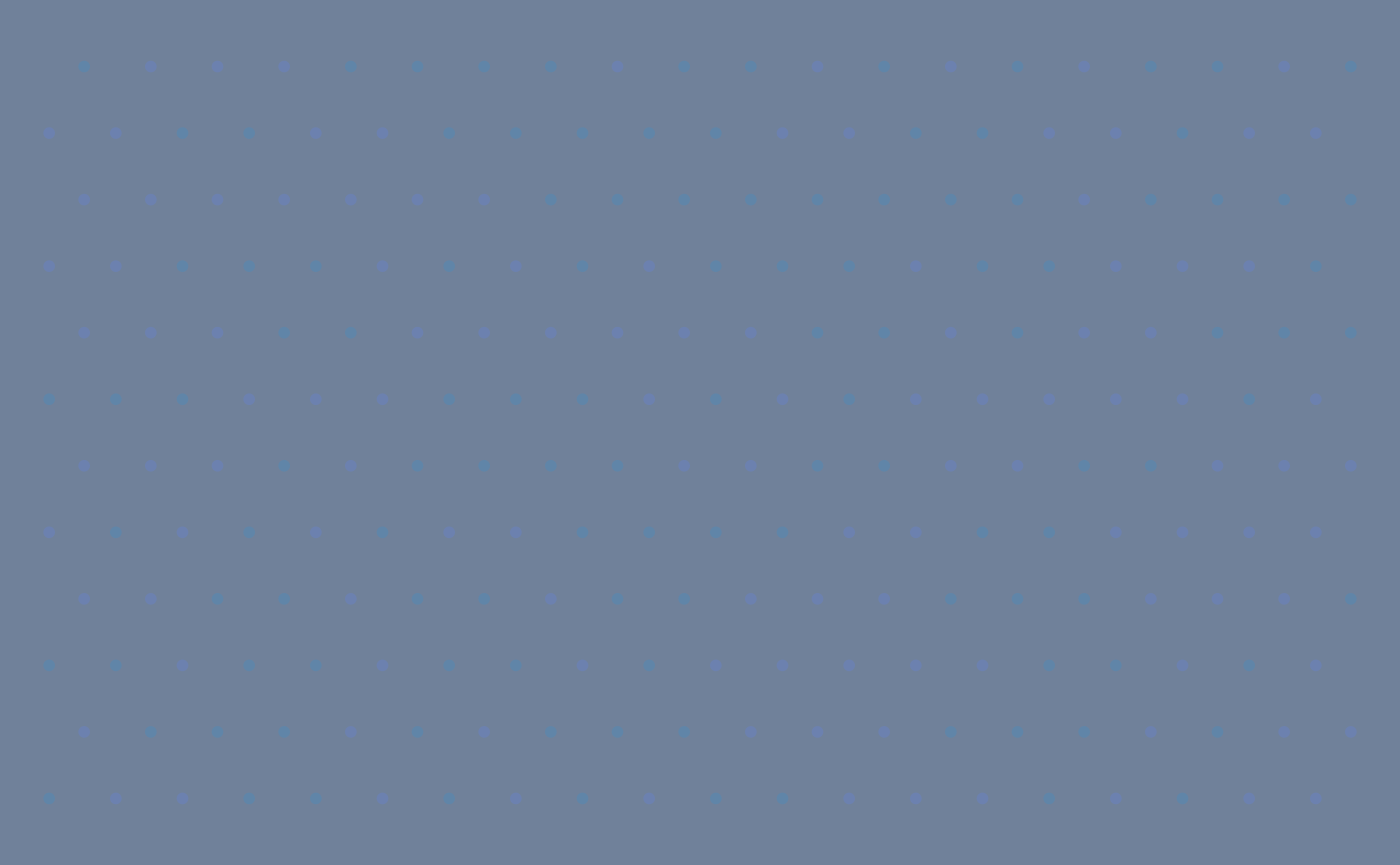

c_mean_=280.00


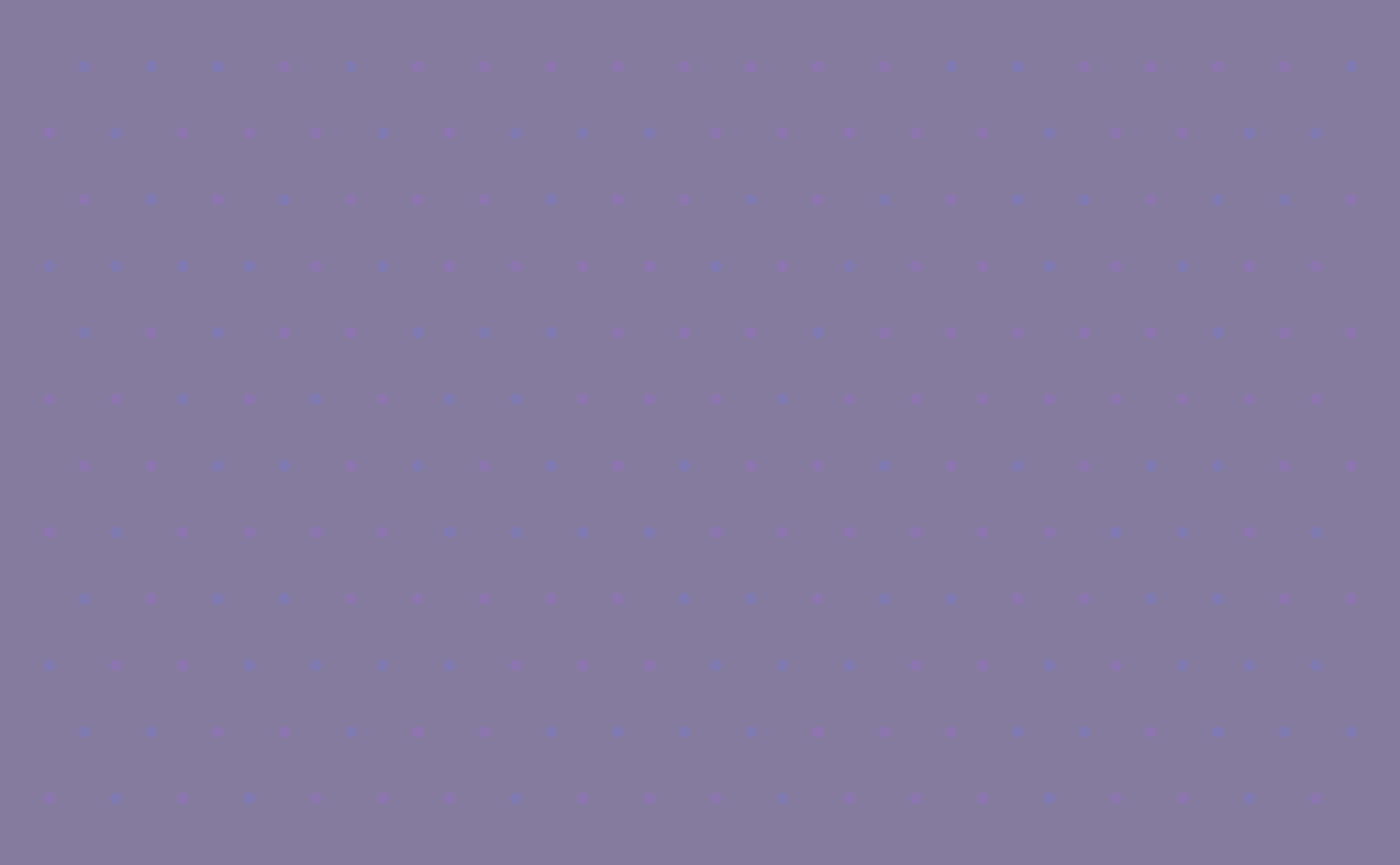

c_mean_=320.00


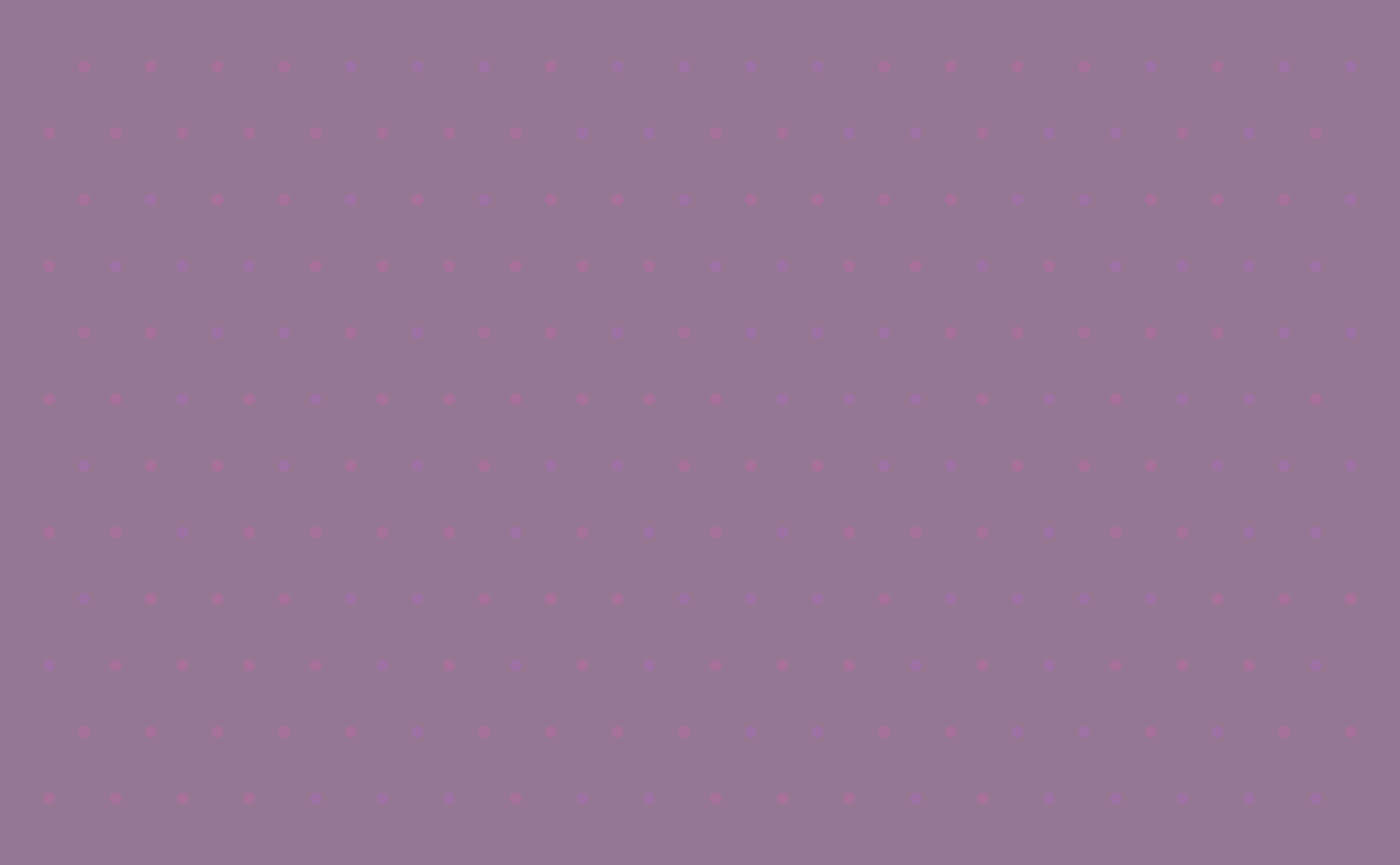

In [14]:
opts_ = opts.copy()
for c_mean_ in np.linspace(0., 360., N_scan, endpoint=False): 
    opts_.update(c_mean=c_mean_)
    print(f'{c_mean_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: c_mean (Mean Hue)

First, this sweep changes the mean hue while keeping geometric structure fixed. Second, the code rotates hue around the full color circle and displays each frame so that chromatic alignment with the background can be assessed directly. Third, some hue sectors increase perceived separation and others reduce it, and this modulation is expected because cone-opponent pathways dominate central chromatic discrimination whereas peripheral vision shows weaker color-resolved segmentation.

## c_std


c_std_=0.00e+00


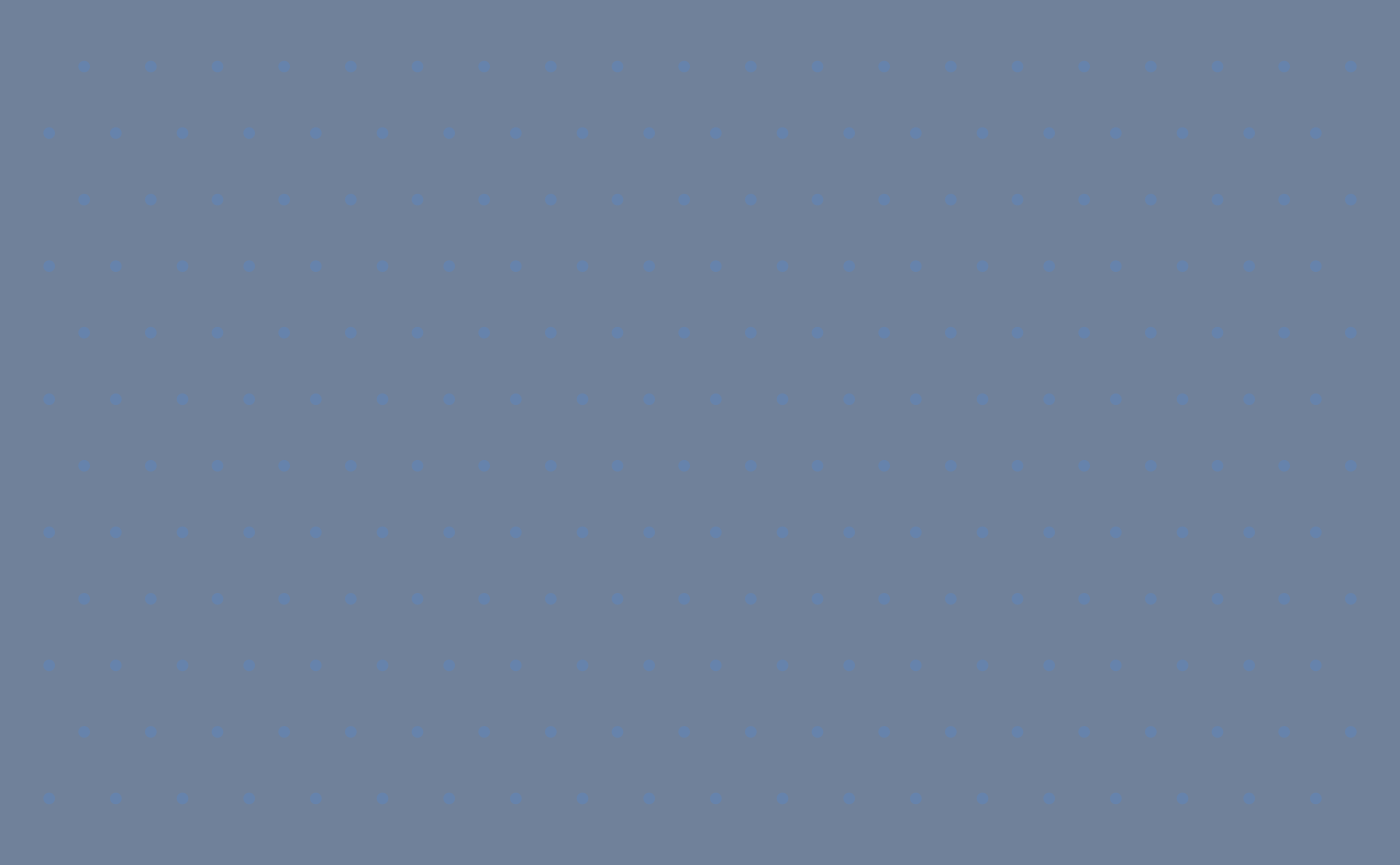

c_std_=3.33e+00


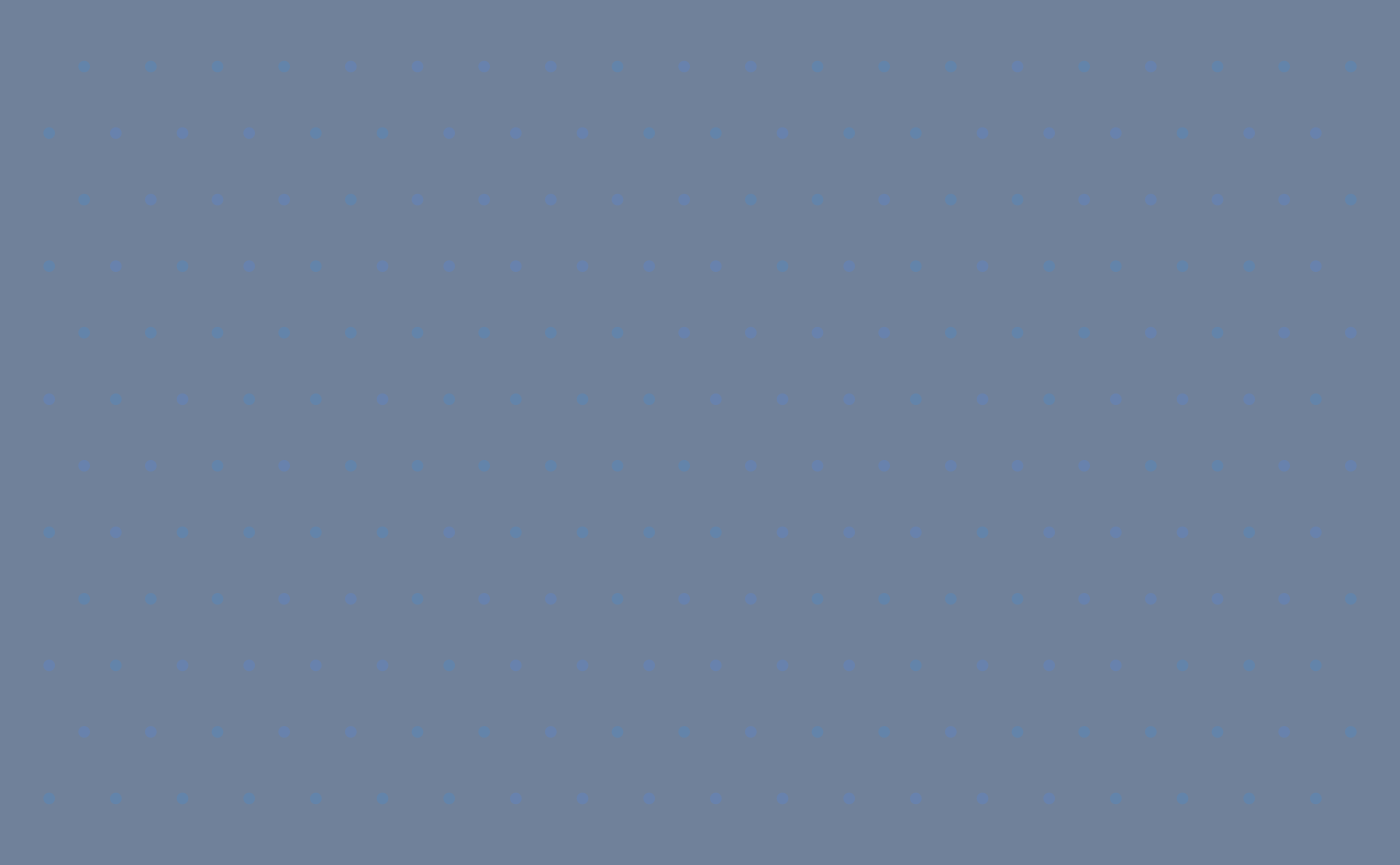

c_std_=6.67e+00


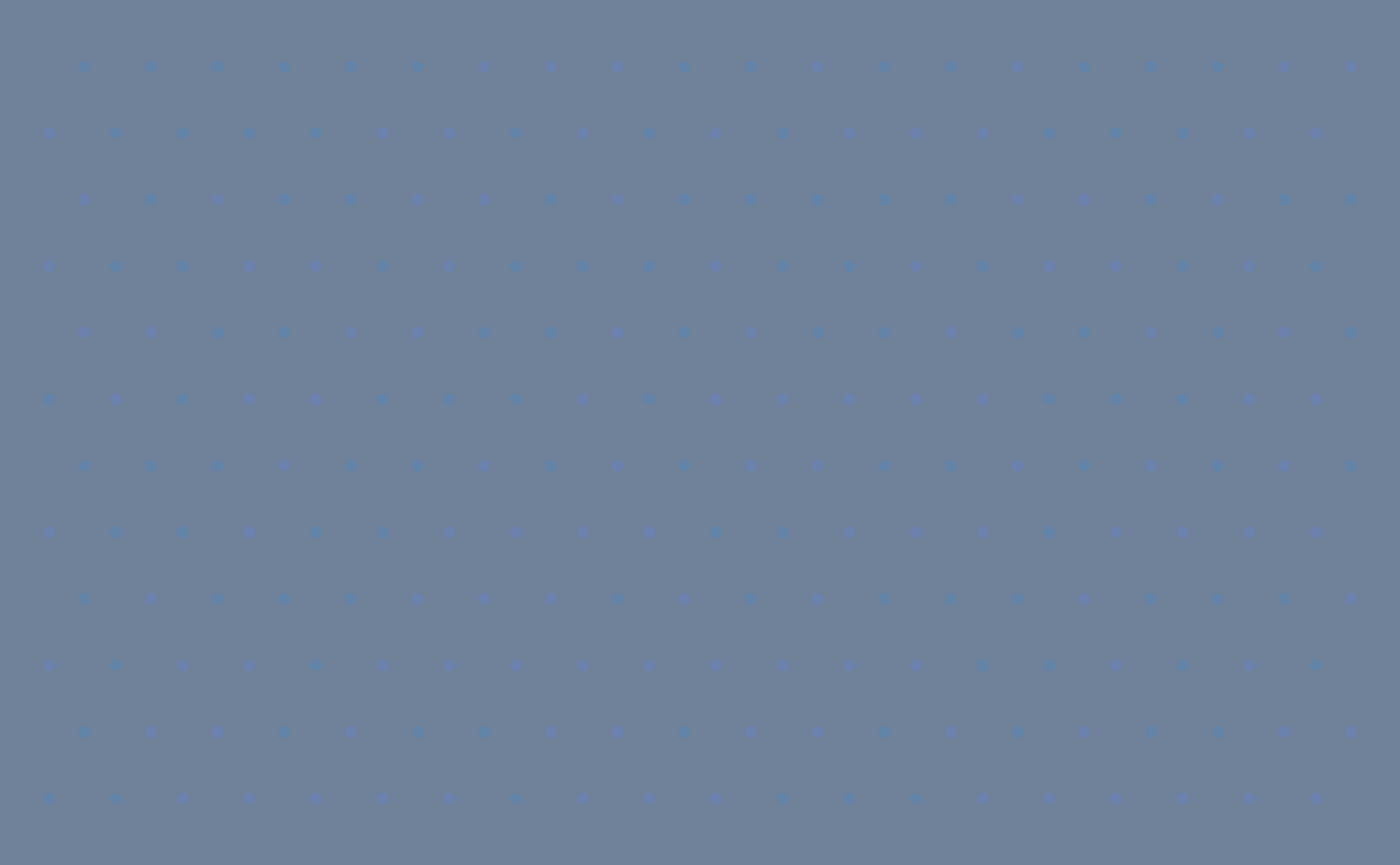

c_std_=1.00e+01


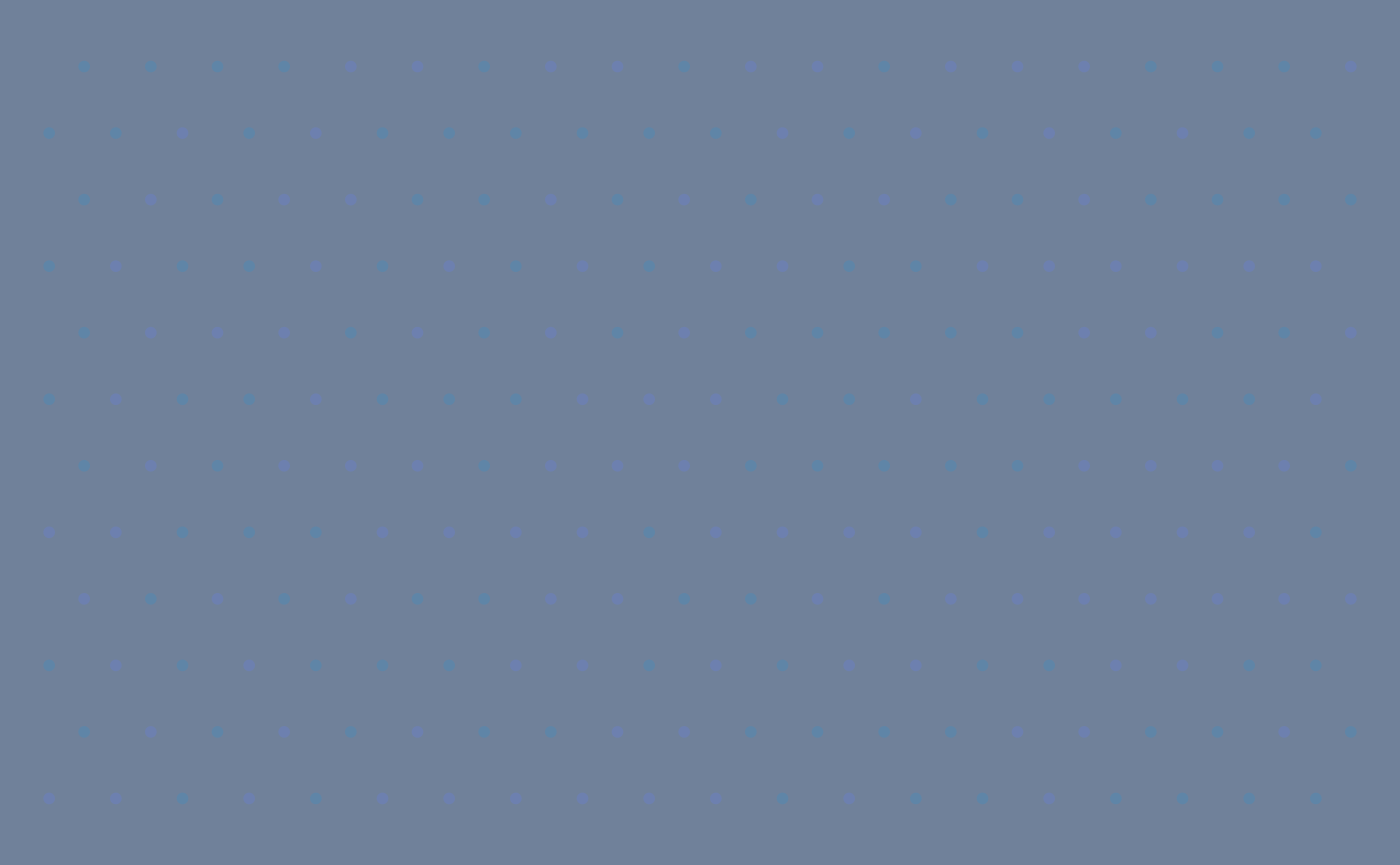

c_std_=1.33e+01


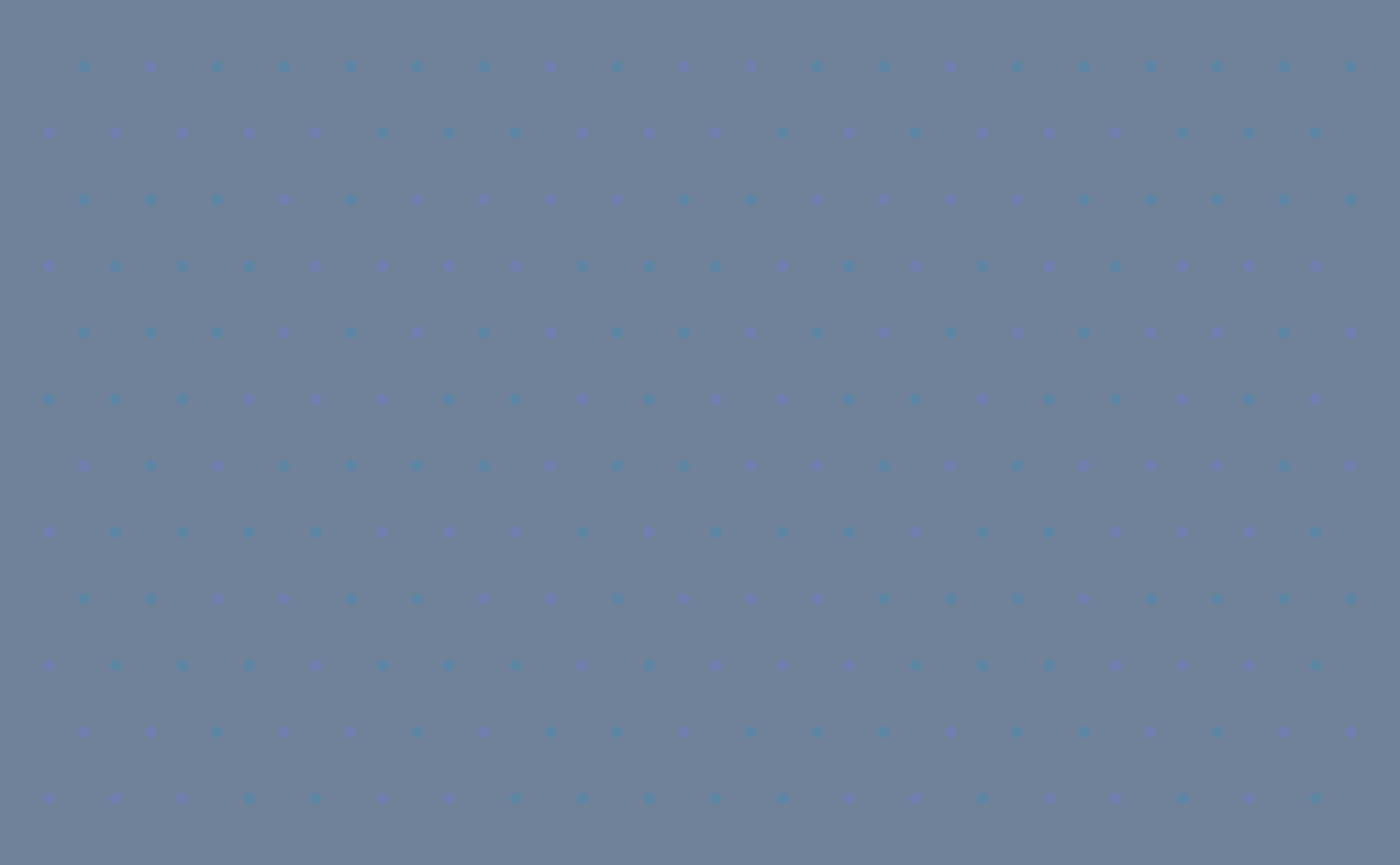

c_std_=1.67e+01


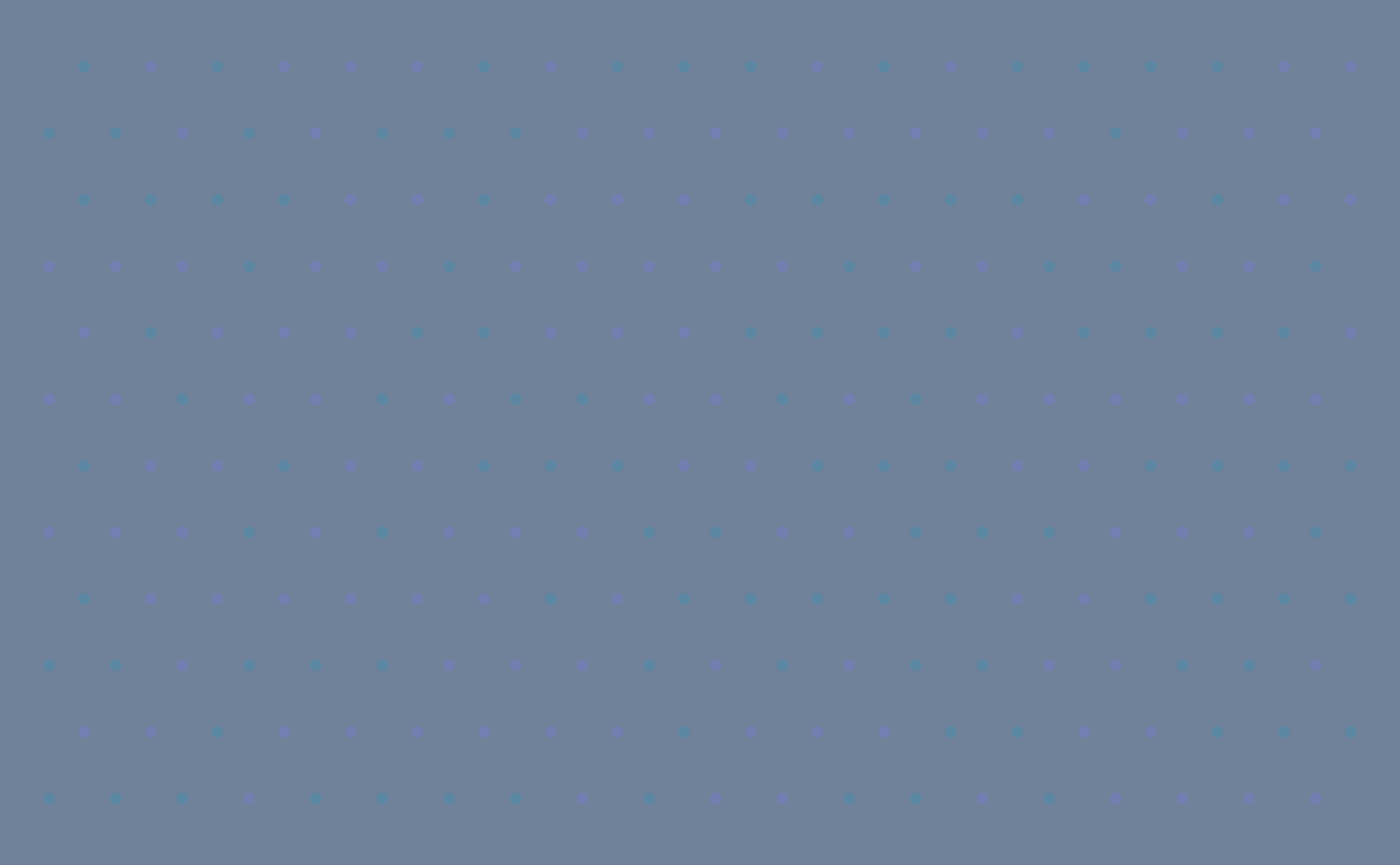

c_std_=2.00e+01


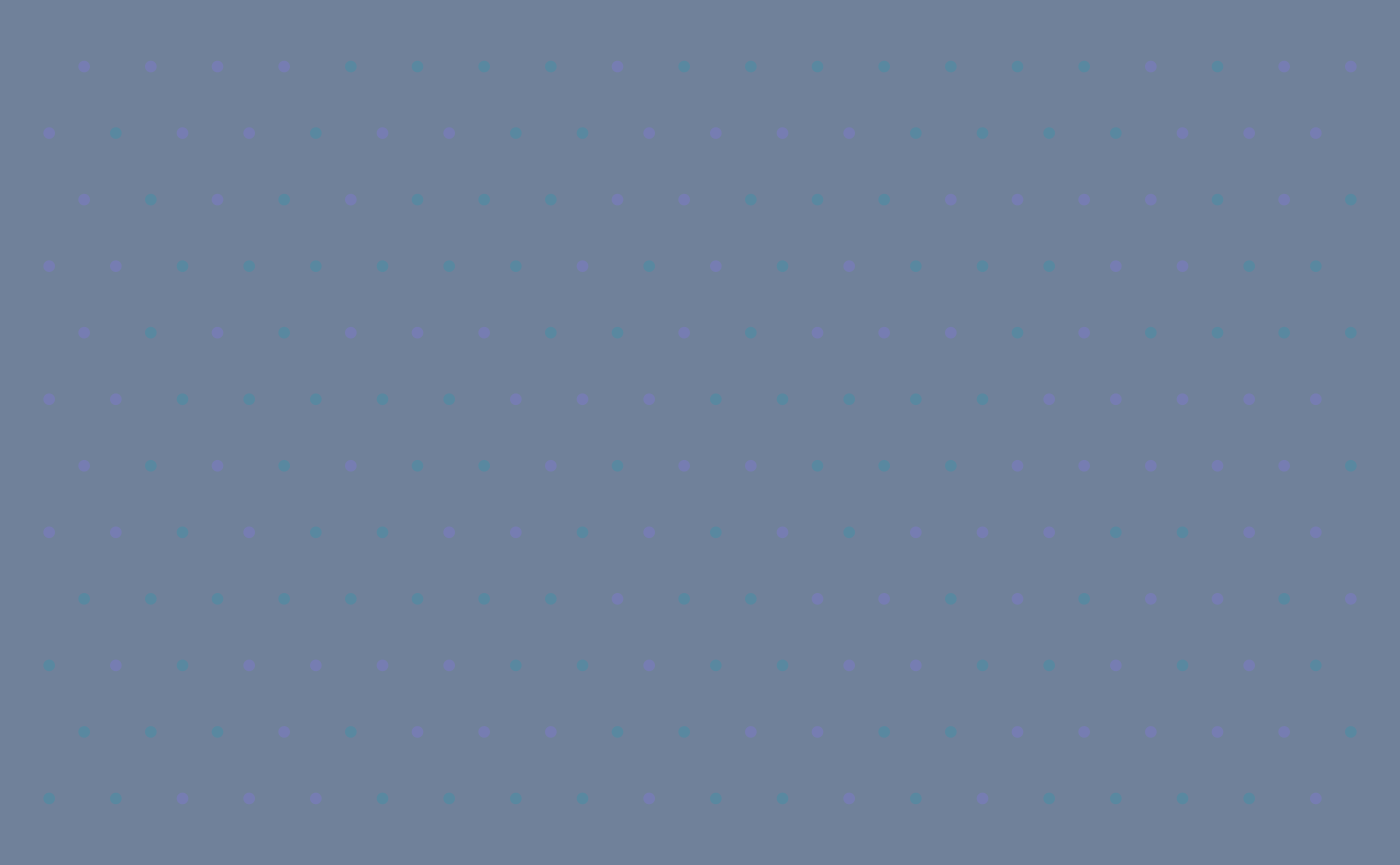

c_std_=2.33e+01


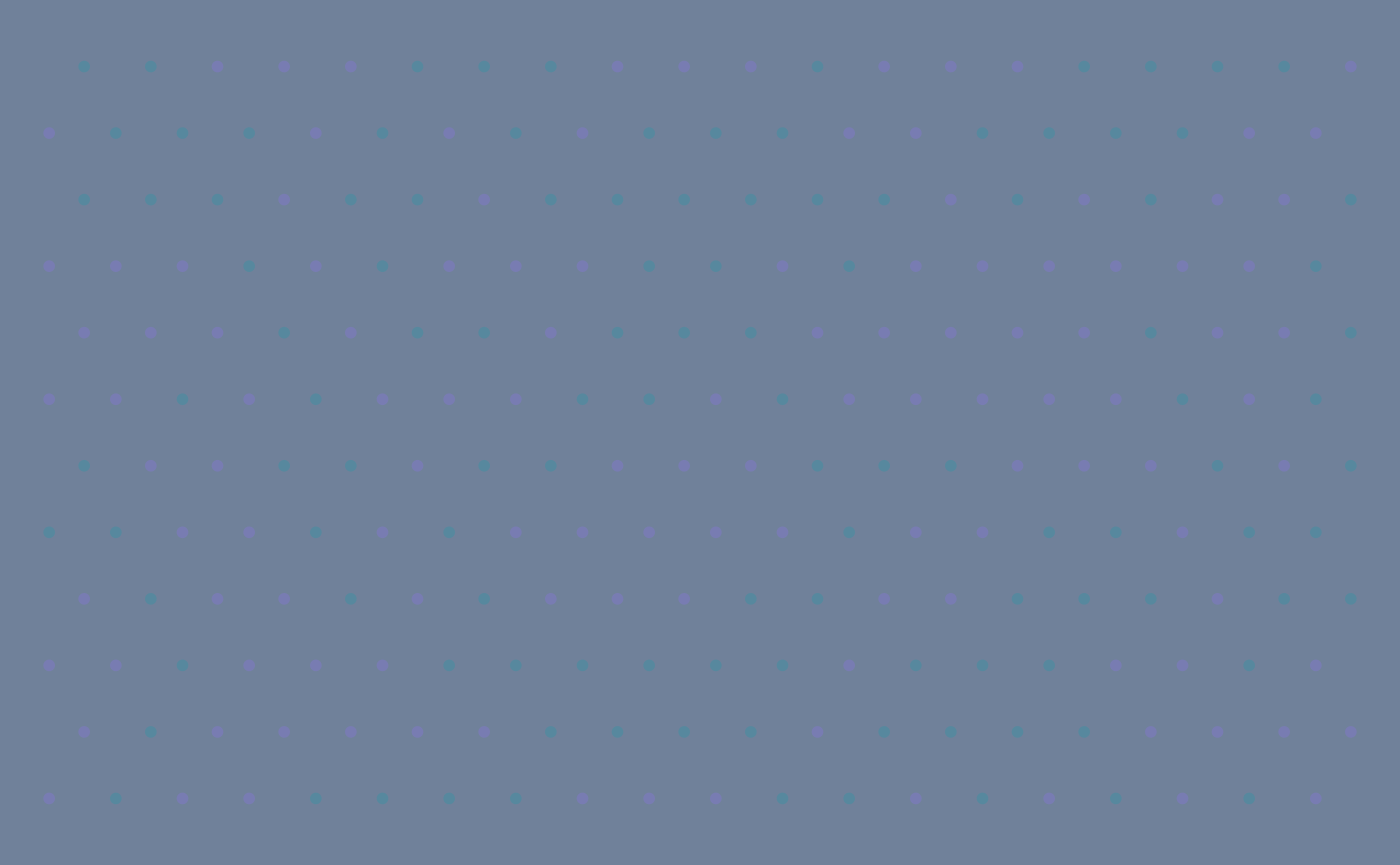

c_std_=2.67e+01


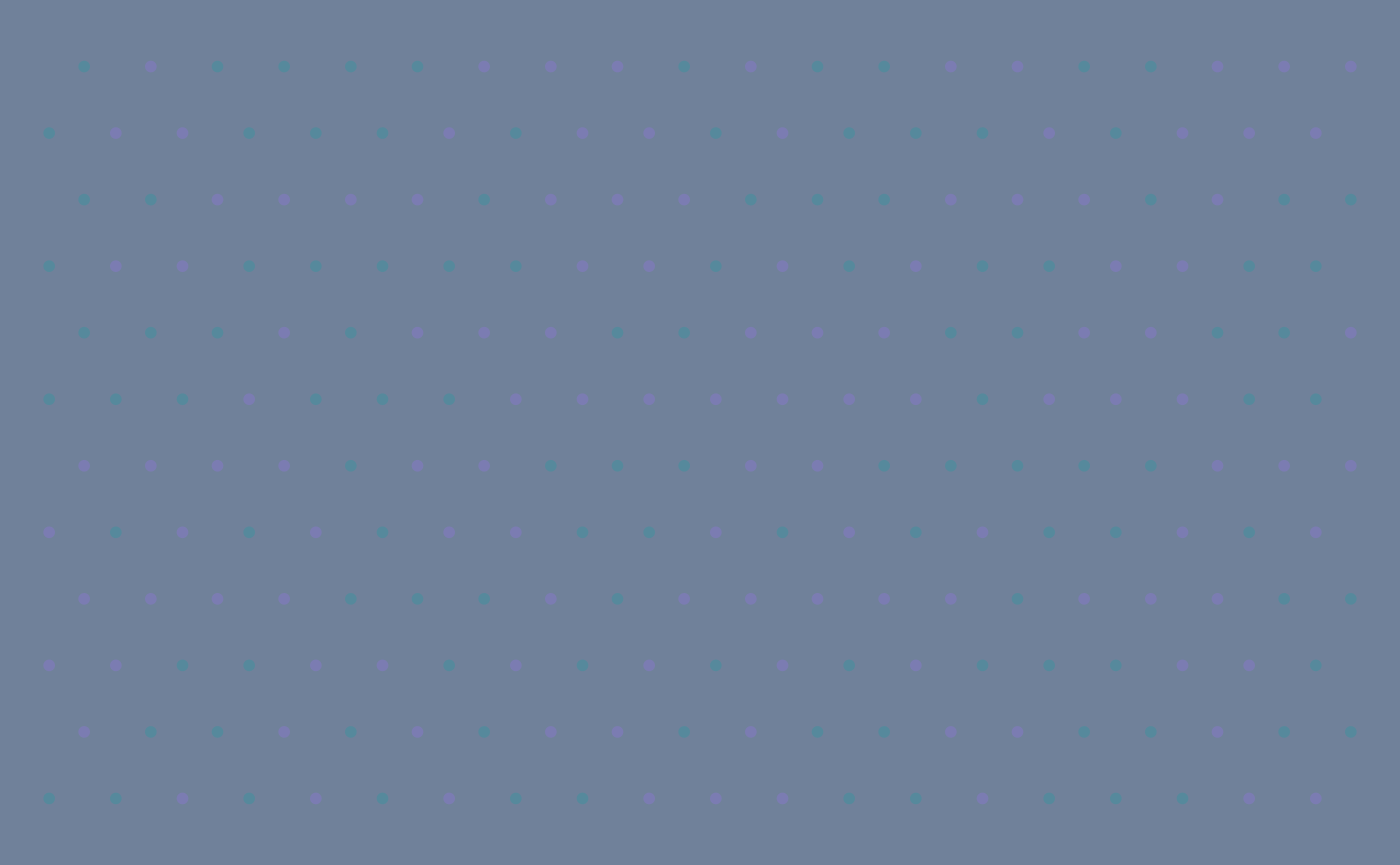

In [15]:
opts_ = opts.copy()
for c_std_ in np.linspace(0., 30, N_scan, endpoint=False): 
    opts_.update(c_std=c_std_)
    print(f'{c_std_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: c_std (Hue Spread)

First, this sweep changes hue variability across dots, which controls chromatic heterogeneity without changing lattice geometry. Second, the code progressively increases hue spread and displays each output to reveal how local irregularity affects grouping. Third, low spread tends to flatten differences, high spread can raise salience everywhere, and moderate spread often best preserves a central parsing advantage over peripheral fusion.

## s_mean

s_mean_=0.00


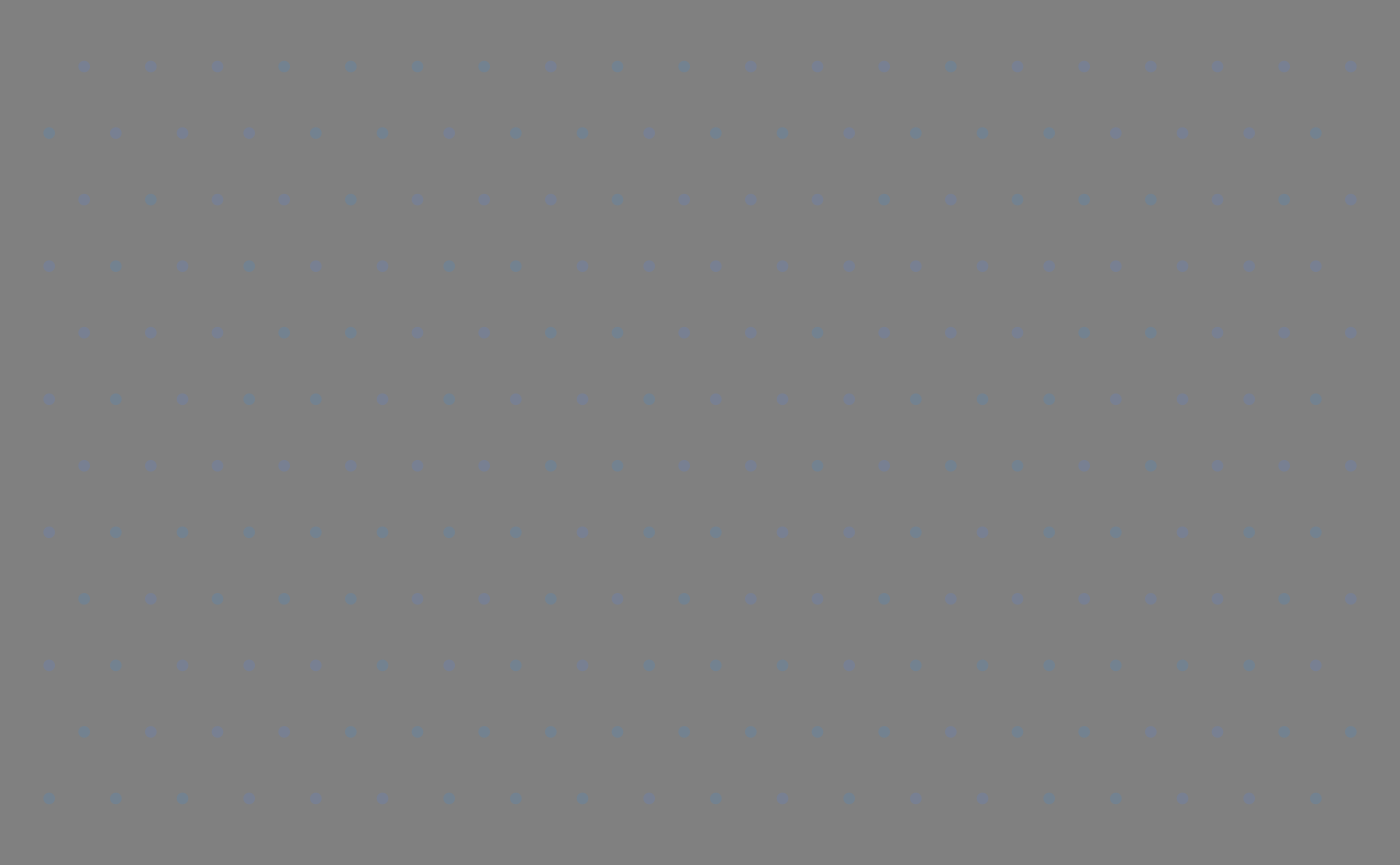

s_mean_=0.07


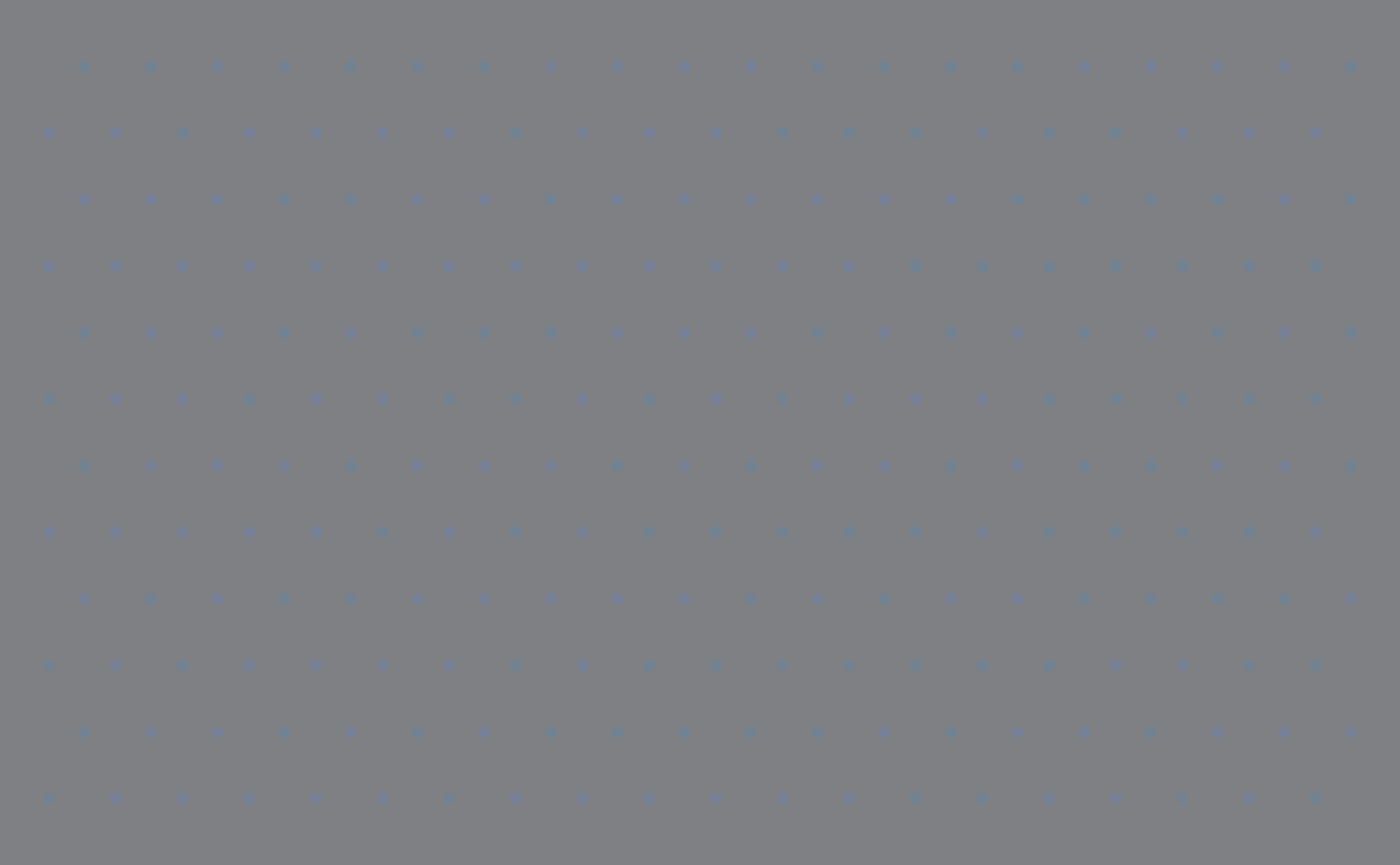

s_mean_=0.15


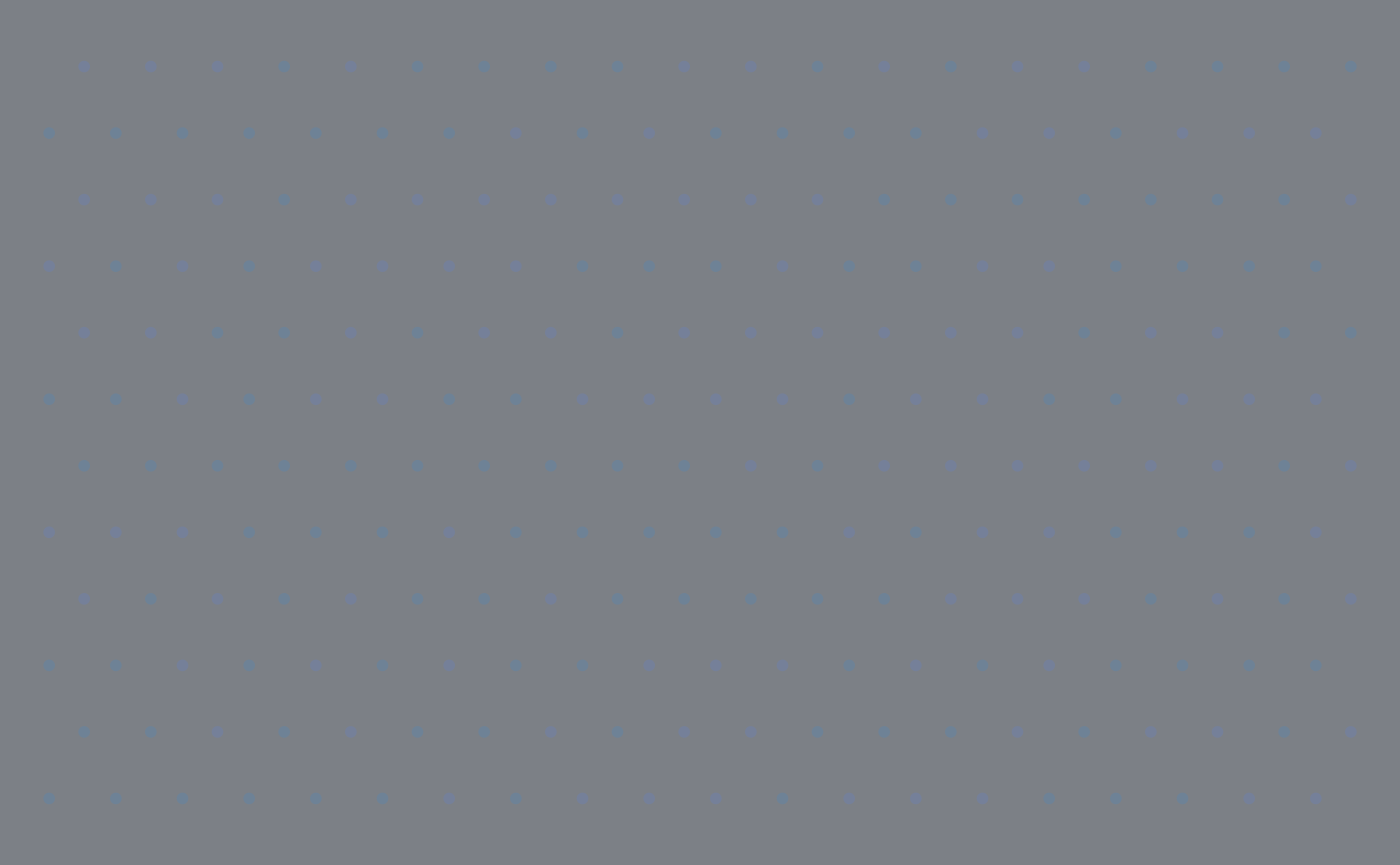

s_mean_=0.22


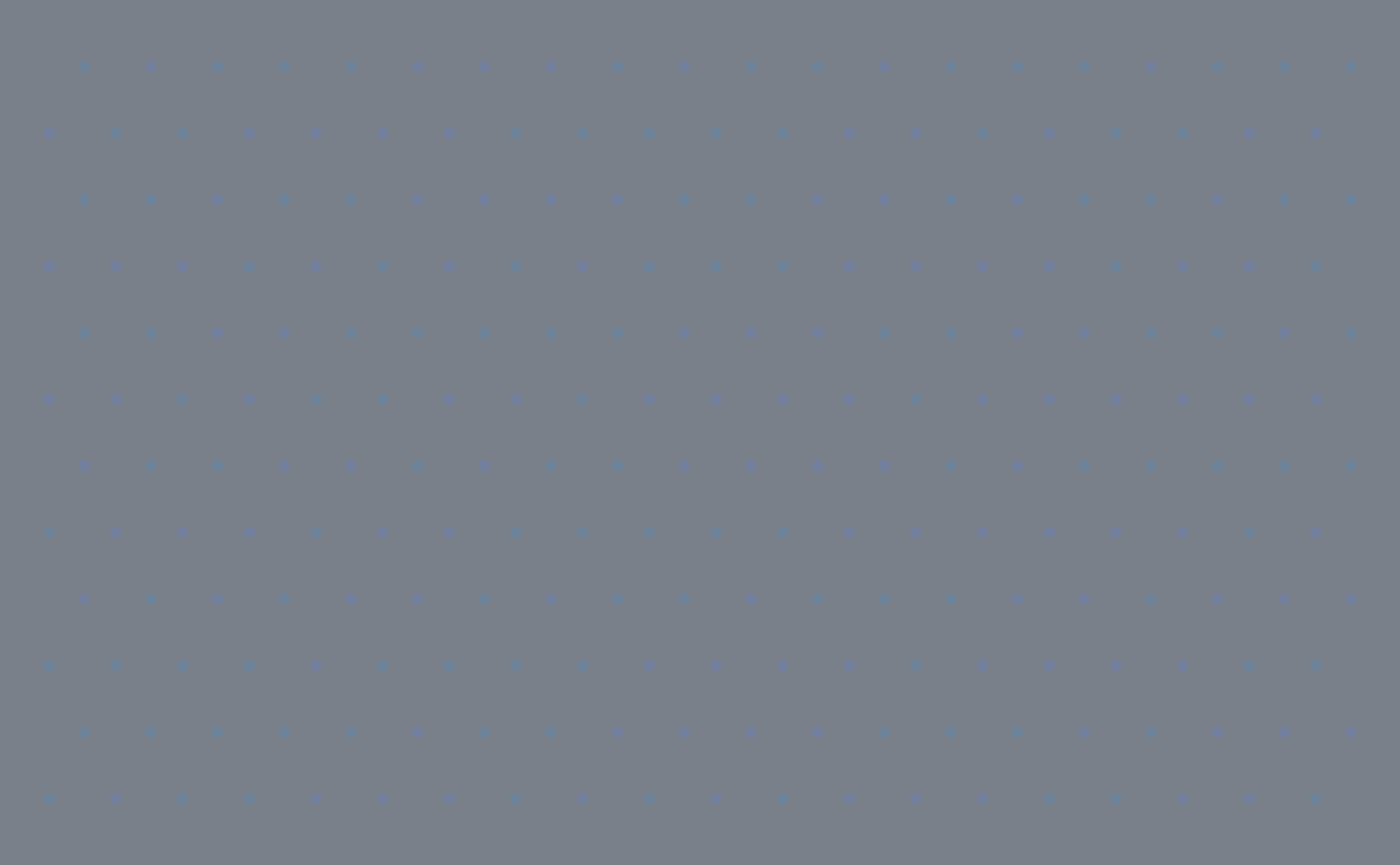

s_mean_=0.30


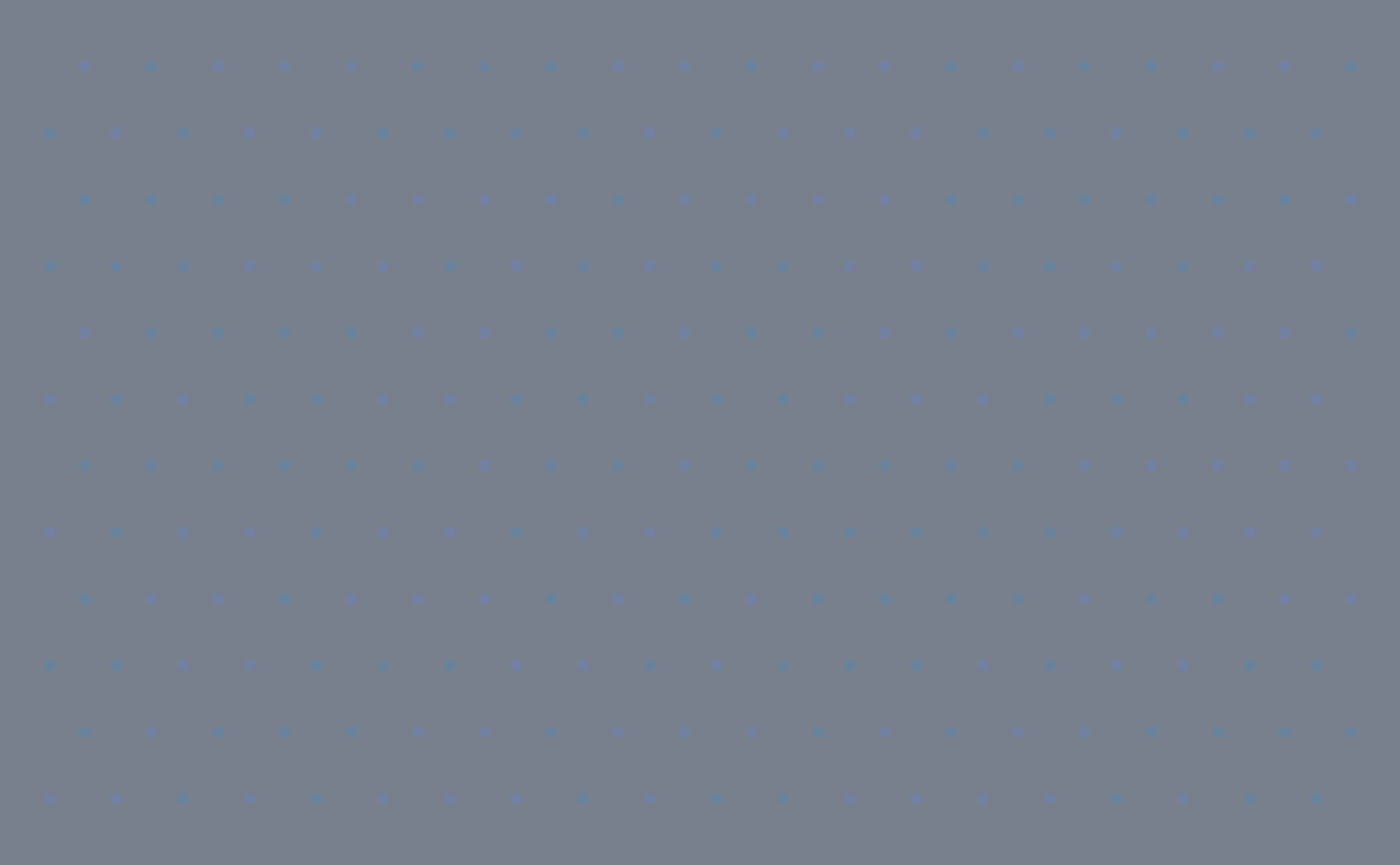

s_mean_=0.38


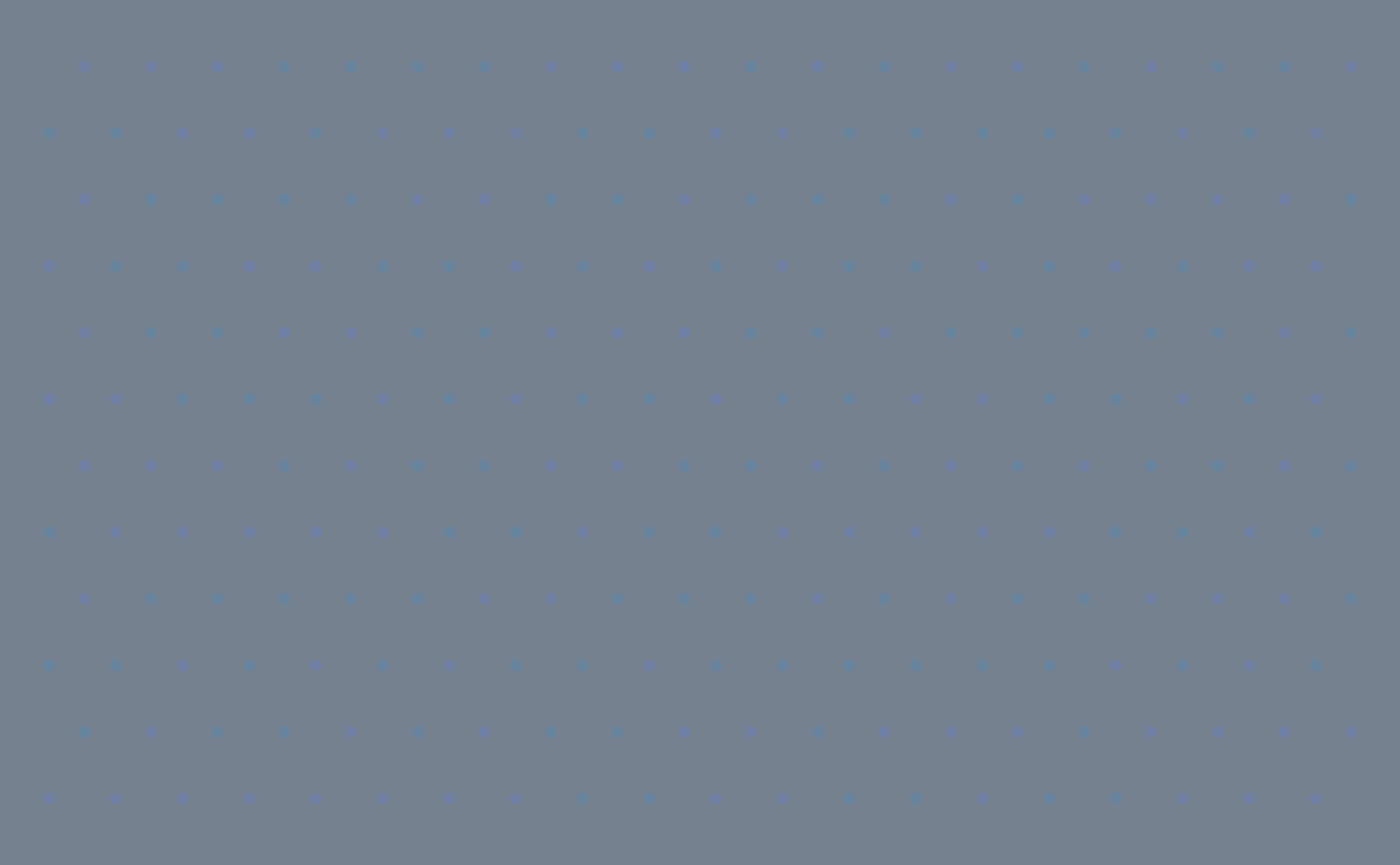

s_mean_=0.45


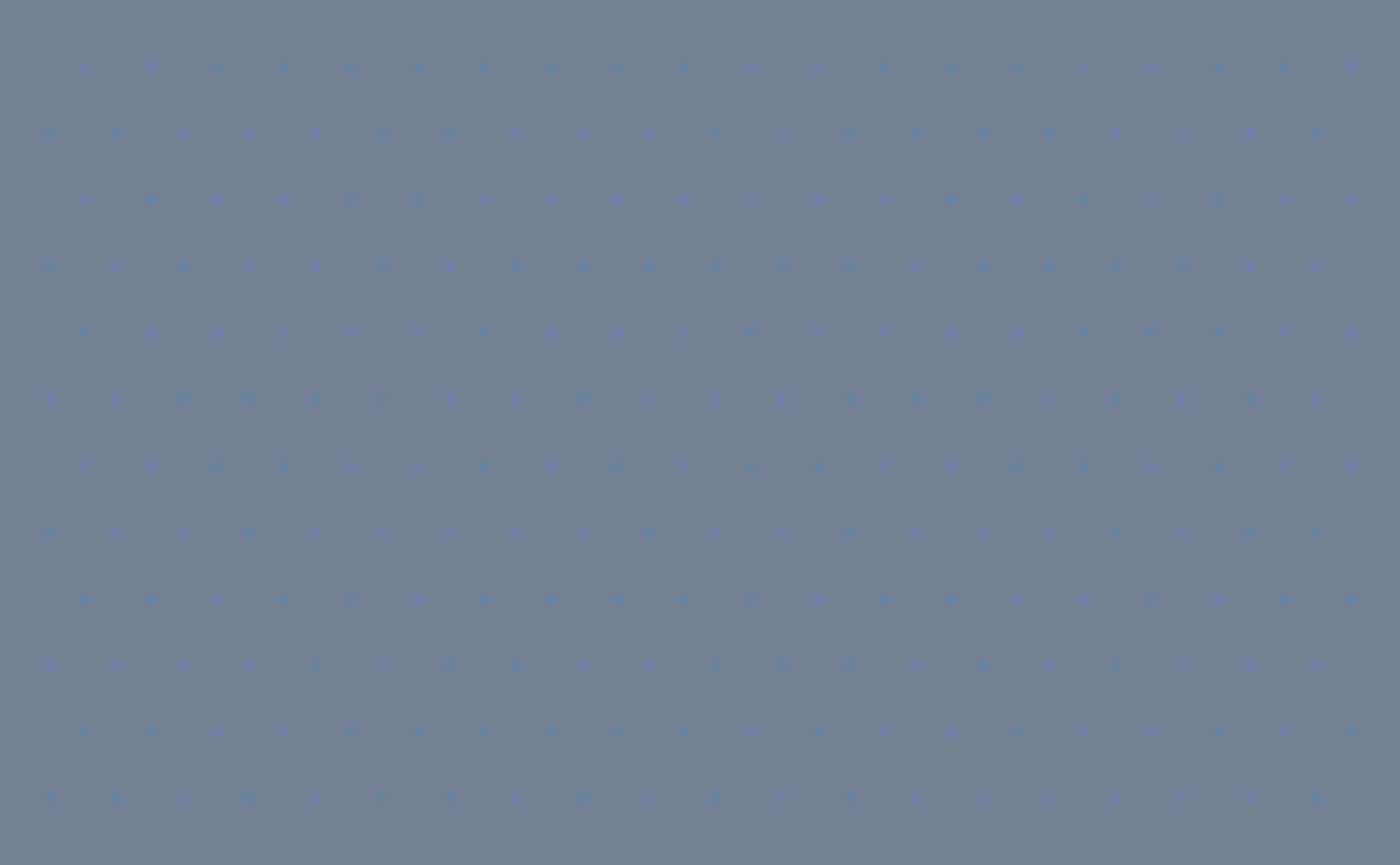

s_mean_=0.53


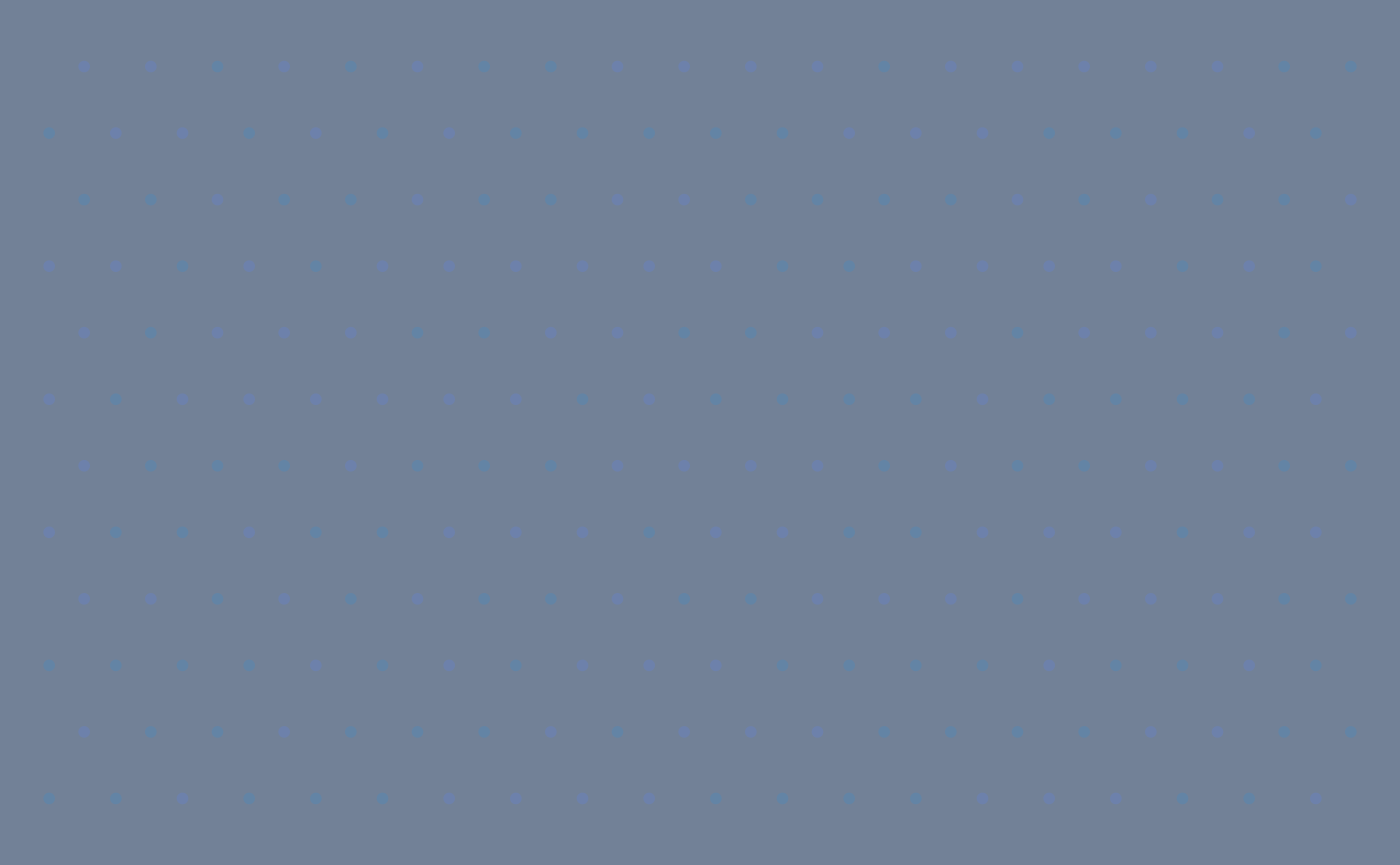

s_mean_=0.60


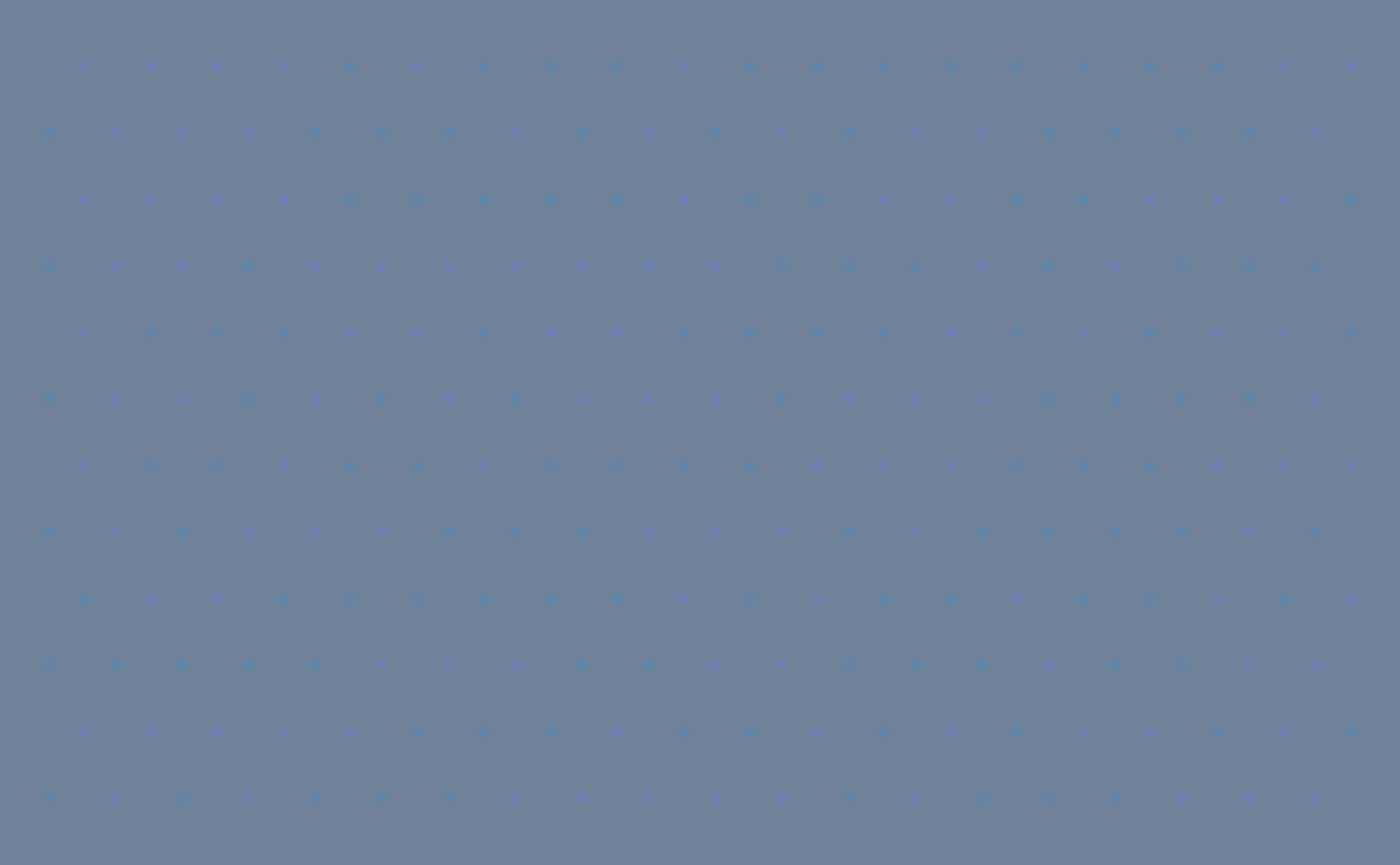

In [16]:
opts_ = opts.copy()
# for s_mean_ in np.linspace(s_std, 1., N_scan, endpoint=True): 
for s_mean_ in np.linspace(0., s_ref, N_scan, endpoint=True): 
    opts_.update(s_mean=s_mean_)
    print(f'{s_mean_=:.2f}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: s_mean (Mean Saturation)

First, this sweep changes the global saturation baseline, effectively scaling chromatic intensity. Second, the code scans saturation from muted to vivid and displays each image to expose where the field crosses from ambiguous to explicit. Third, weak saturation can erase chromatic boundaries while strong saturation can over-stabilize the entire lattice, and intermediate saturation often matches the physiological goal of strong central cone-driven segmentation with weaker peripheral color parsing.

## s_std


s_std_=0.00e+00


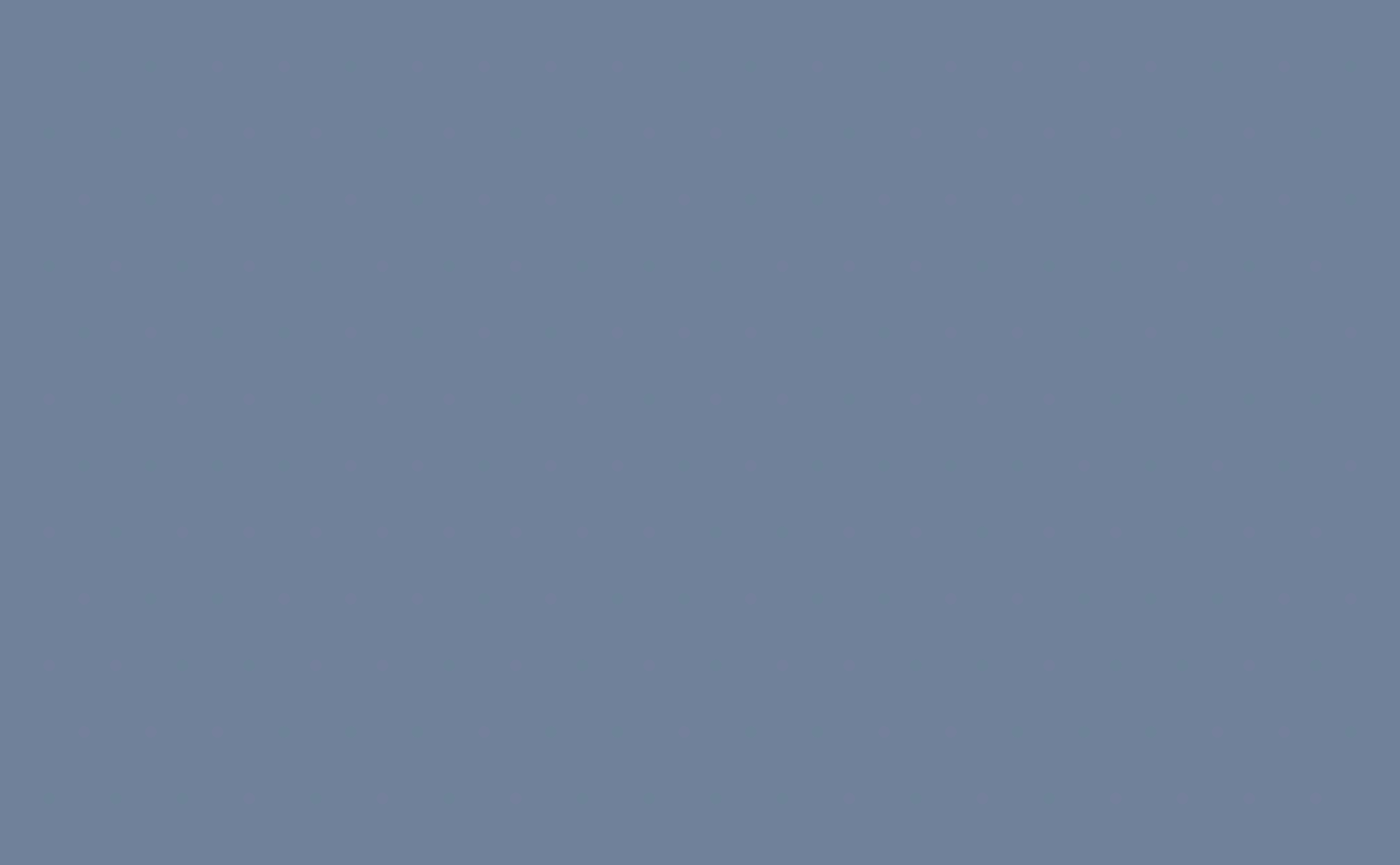

s_std_=5.00e-02


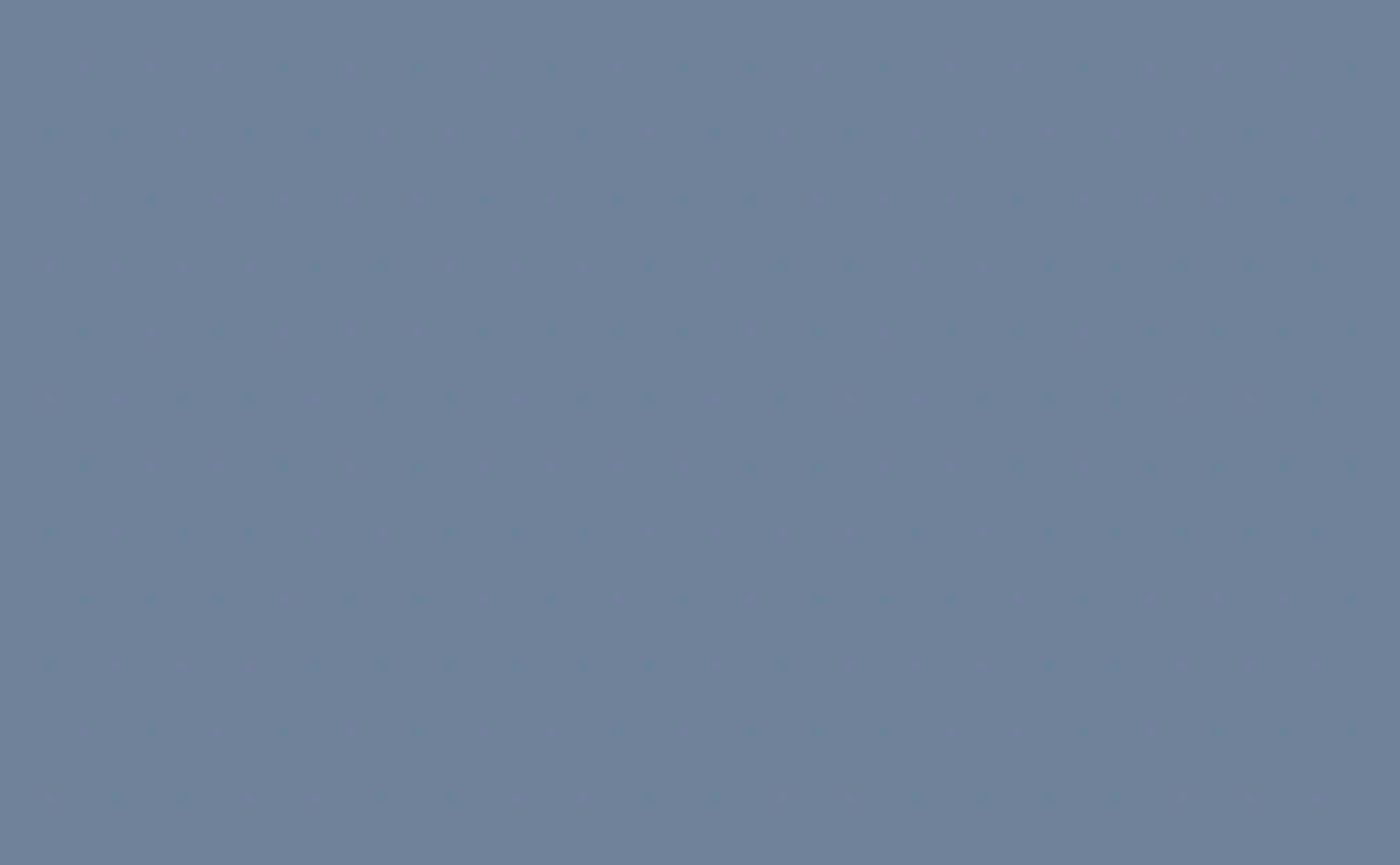

s_std_=1.00e-01


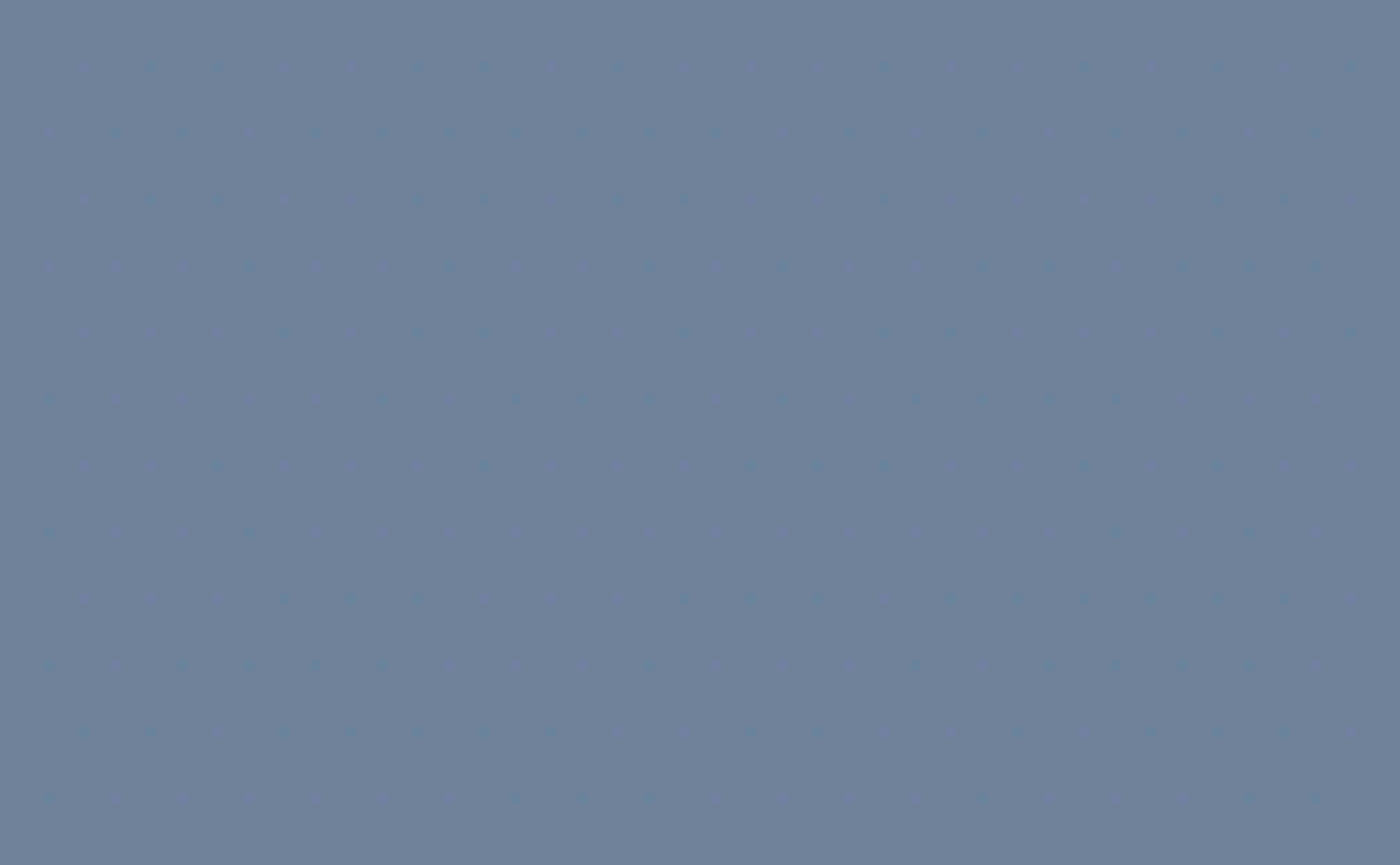

s_std_=1.50e-01


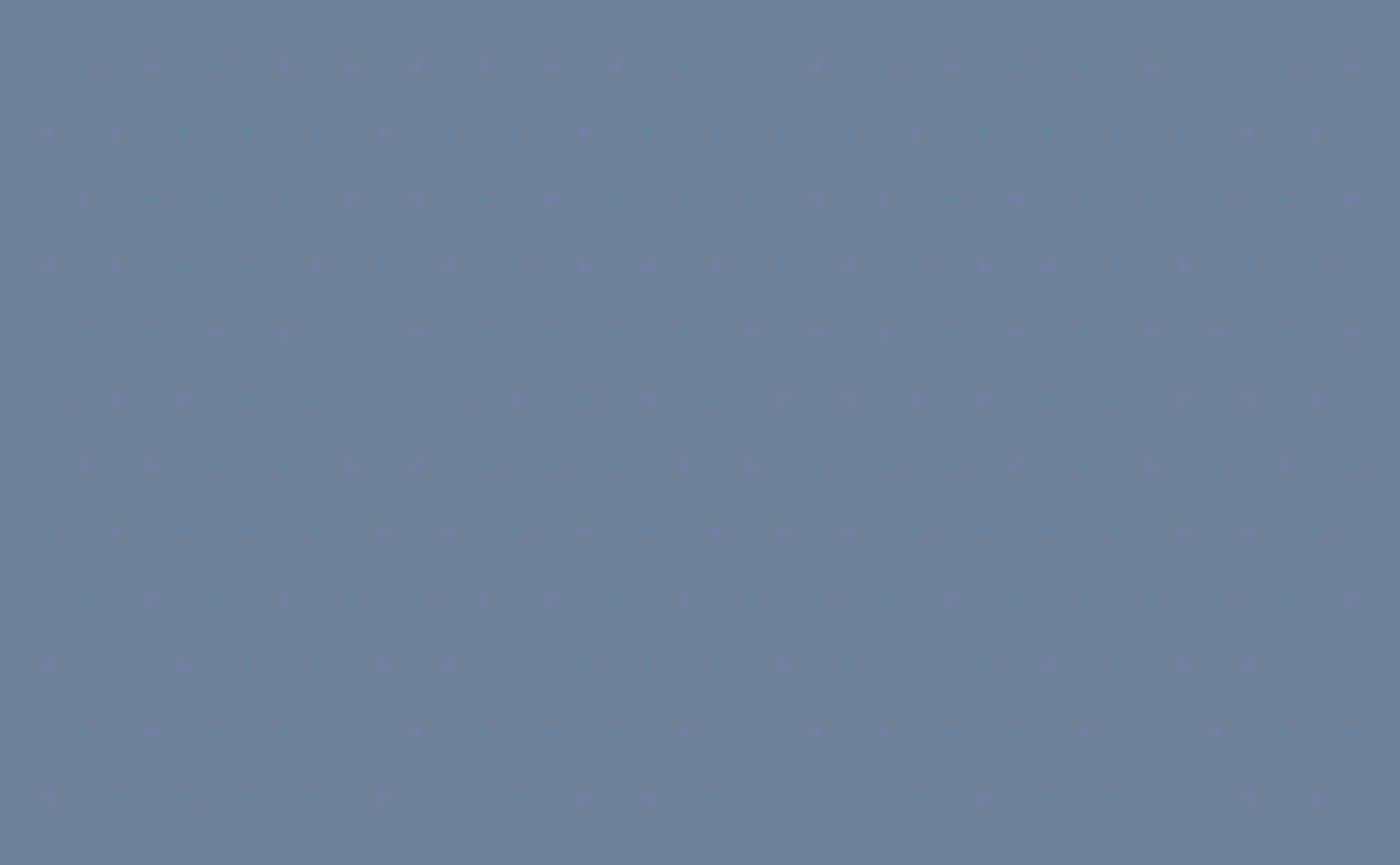

s_std_=2.00e-01


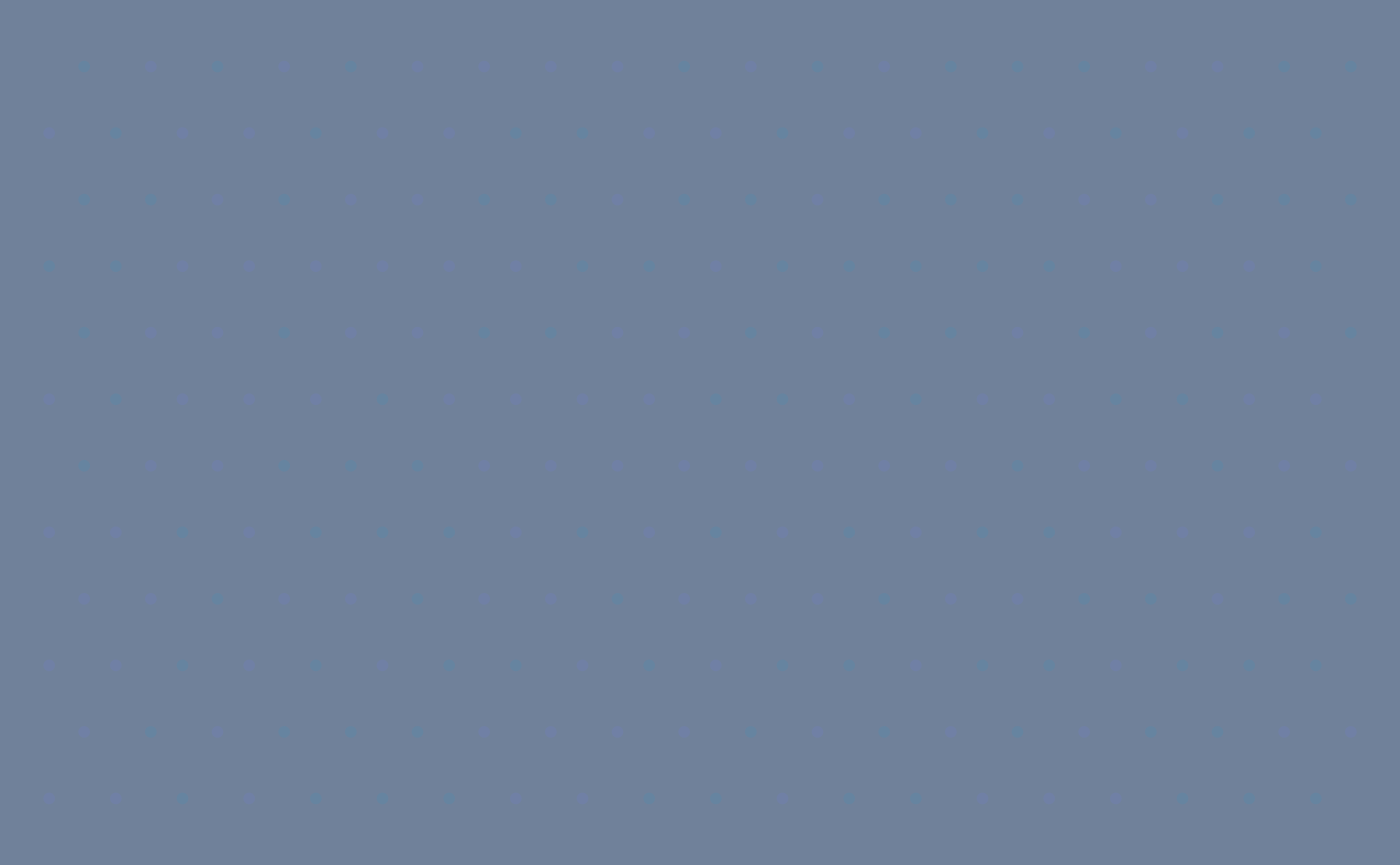

s_std_=2.50e-01


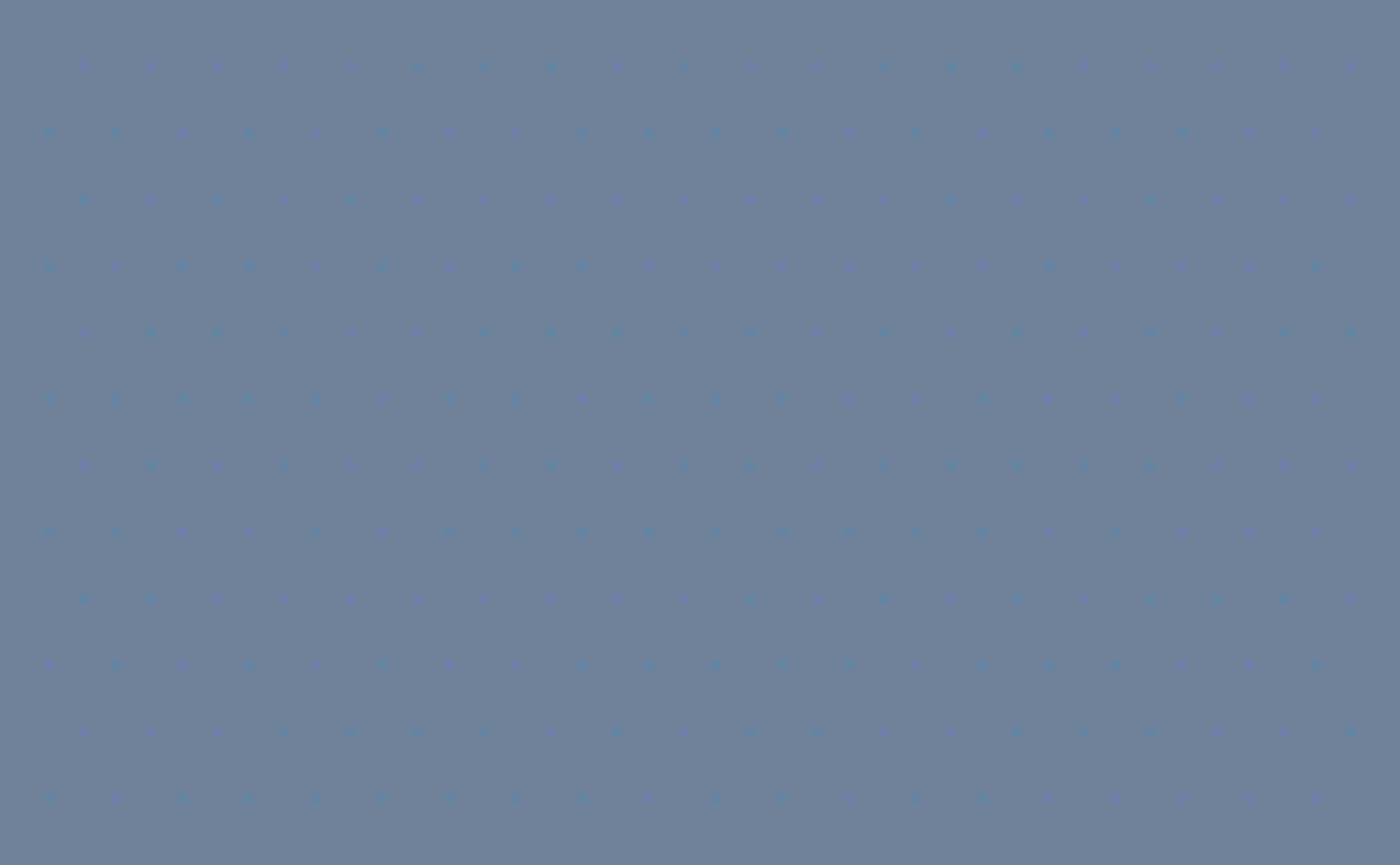

s_std_=3.00e-01


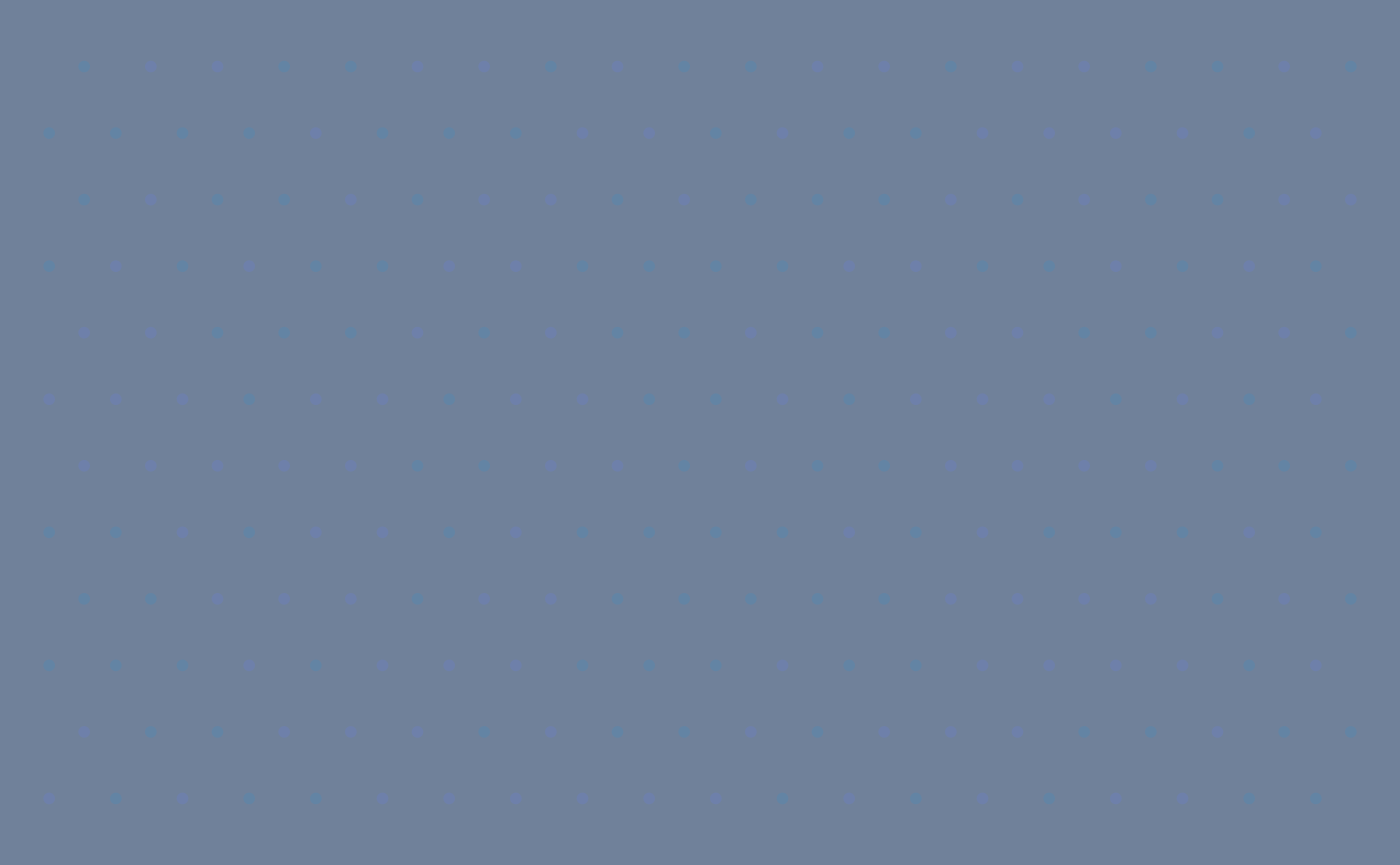

s_std_=3.50e-01


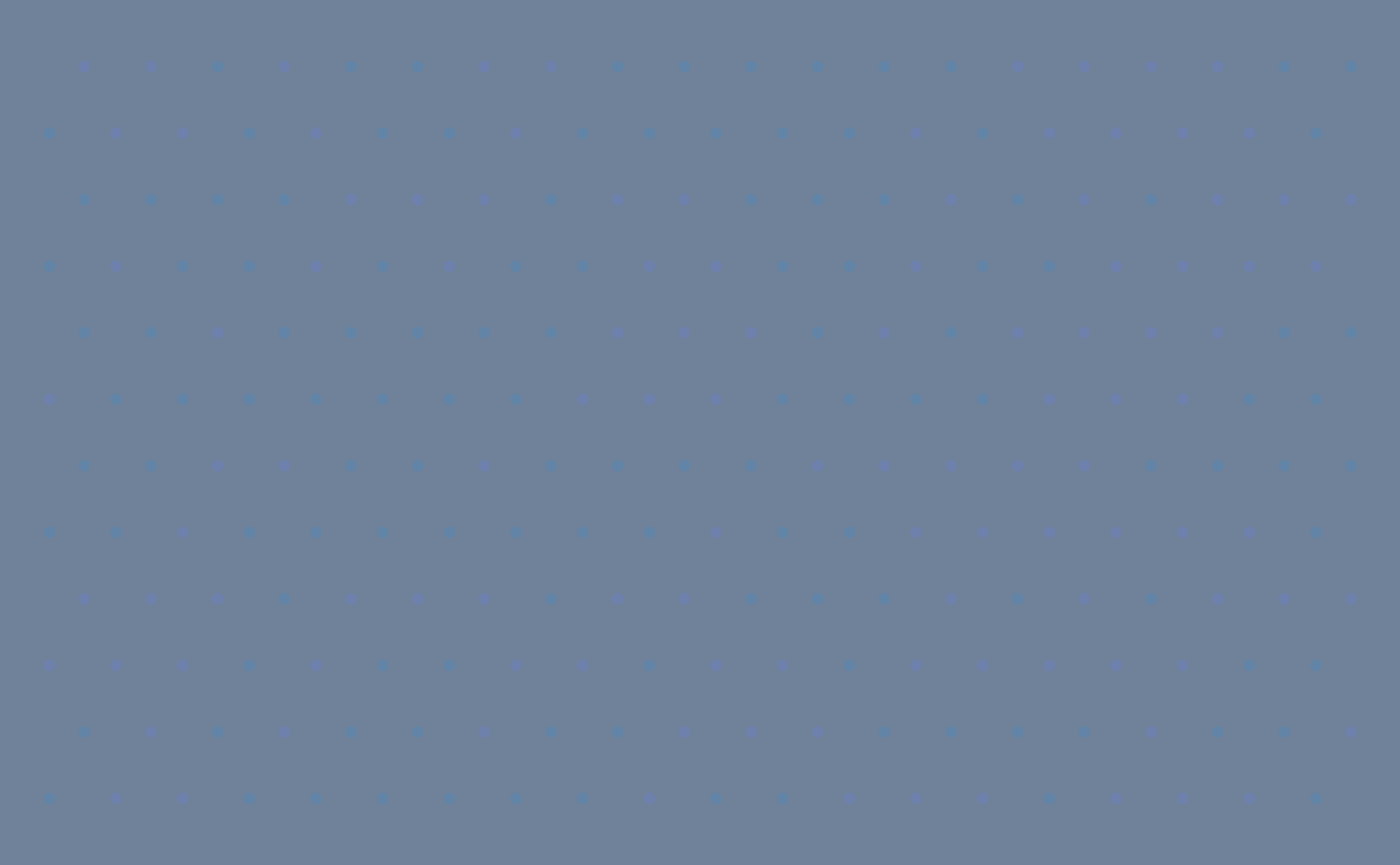

s_std_=4.00e-01


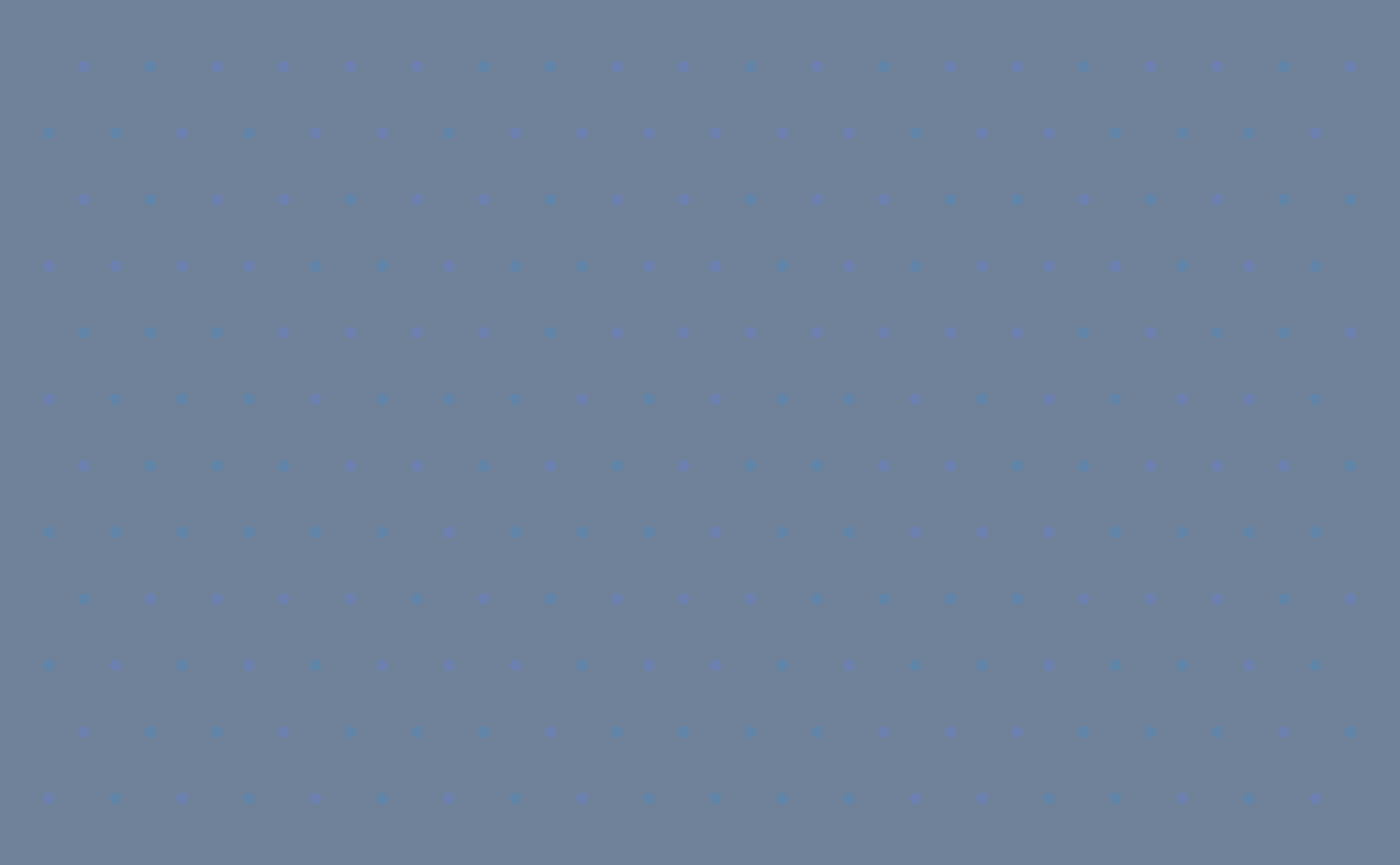

In [17]:
opts_ = opts.copy()
# for s_std_ in np.linspace(0., s_ref, N_scan, endpoint=True): 
for s_std_ in np.linspace(0., 1.-s_ref, N_scan, endpoint=True): 
    opts_.update(s_mean=s_ref, s_std=s_std_)
    print(f'{s_std_=:.2e}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: s_std (Saturation Spread)

First, this sweep changes saturation variability among dots while preserving the mean reference. Second, the code increases dispersion and displays each output so that local contrast fluctuations can be judged visually. Third, low dispersion yields smoother appearance, high dispersion introduces strong local anchors, and moderate dispersion generally supports the intended illusion by keeping peripheral structure less stable than central structure.

## N_H

N_=np.int64(10)


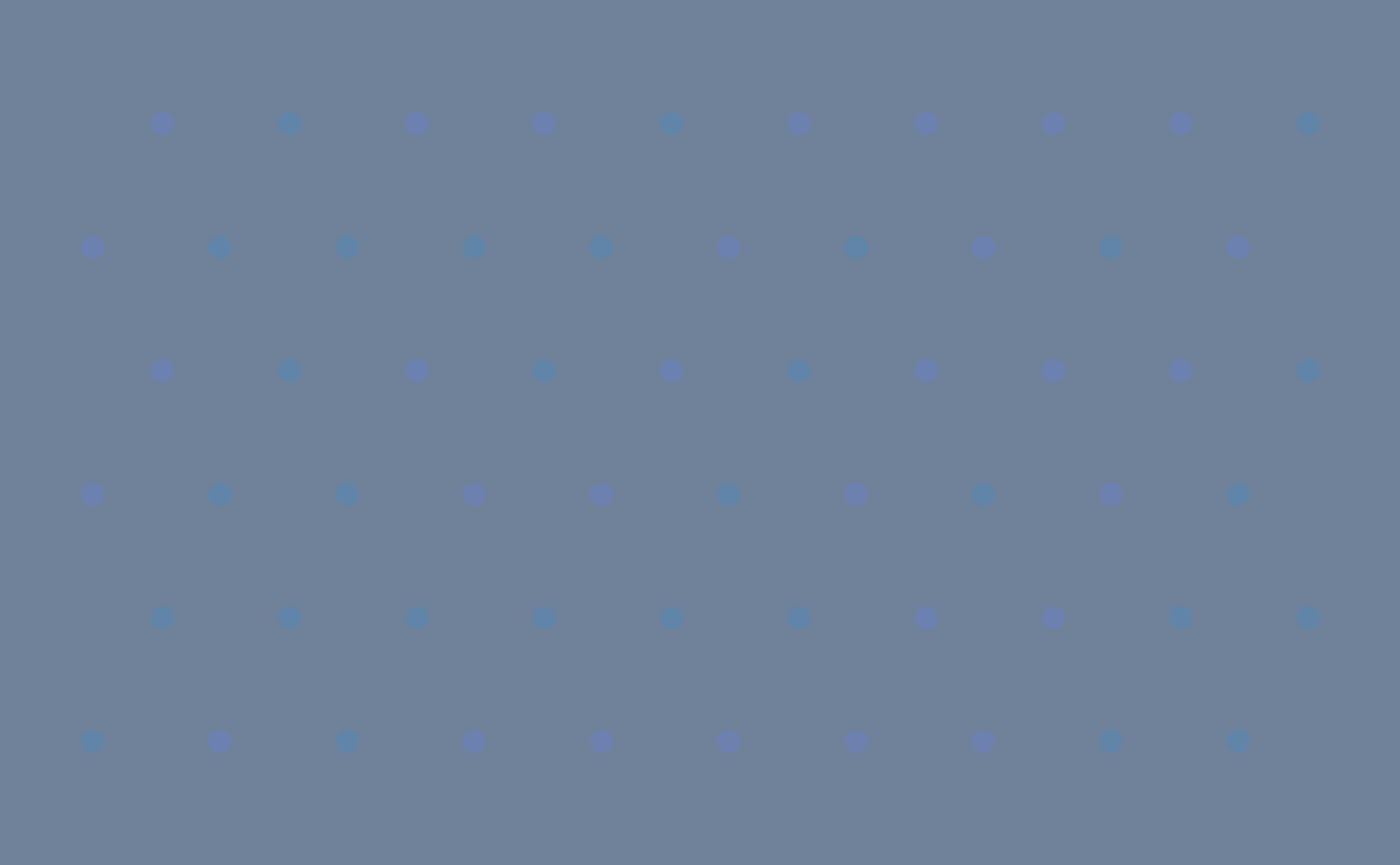

N_=np.int64(11)


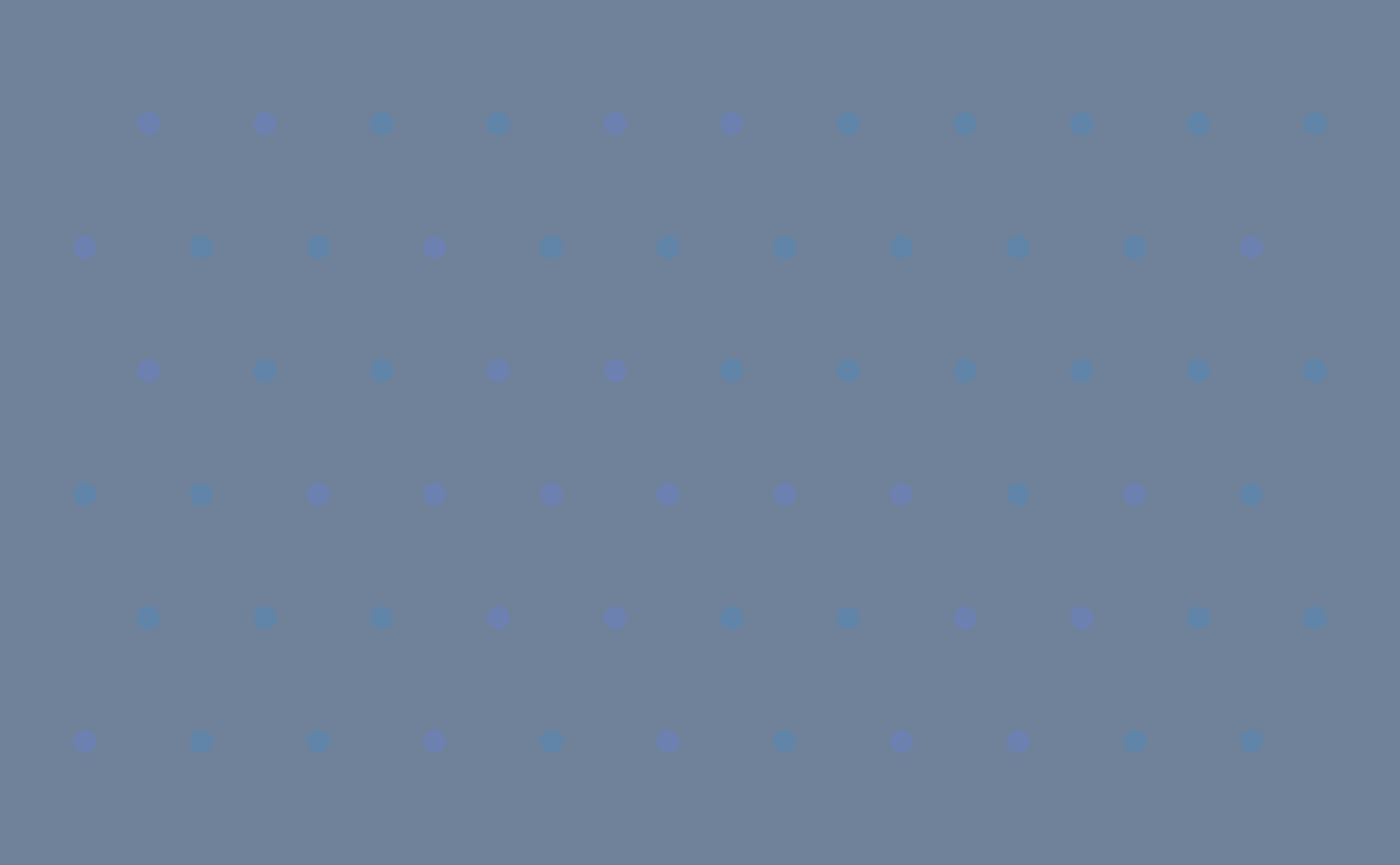

N_=np.int64(14)


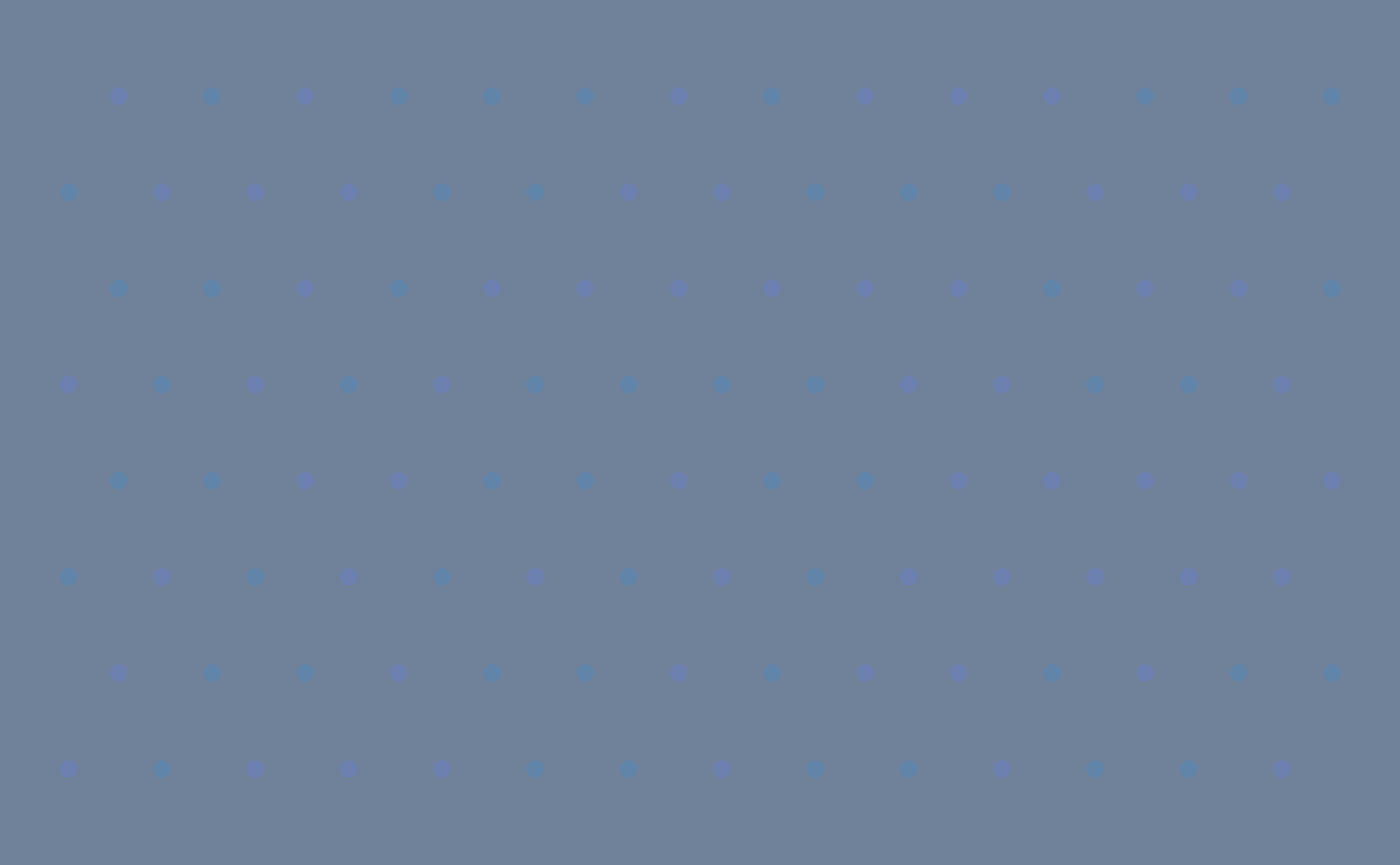

N_=np.int64(16)


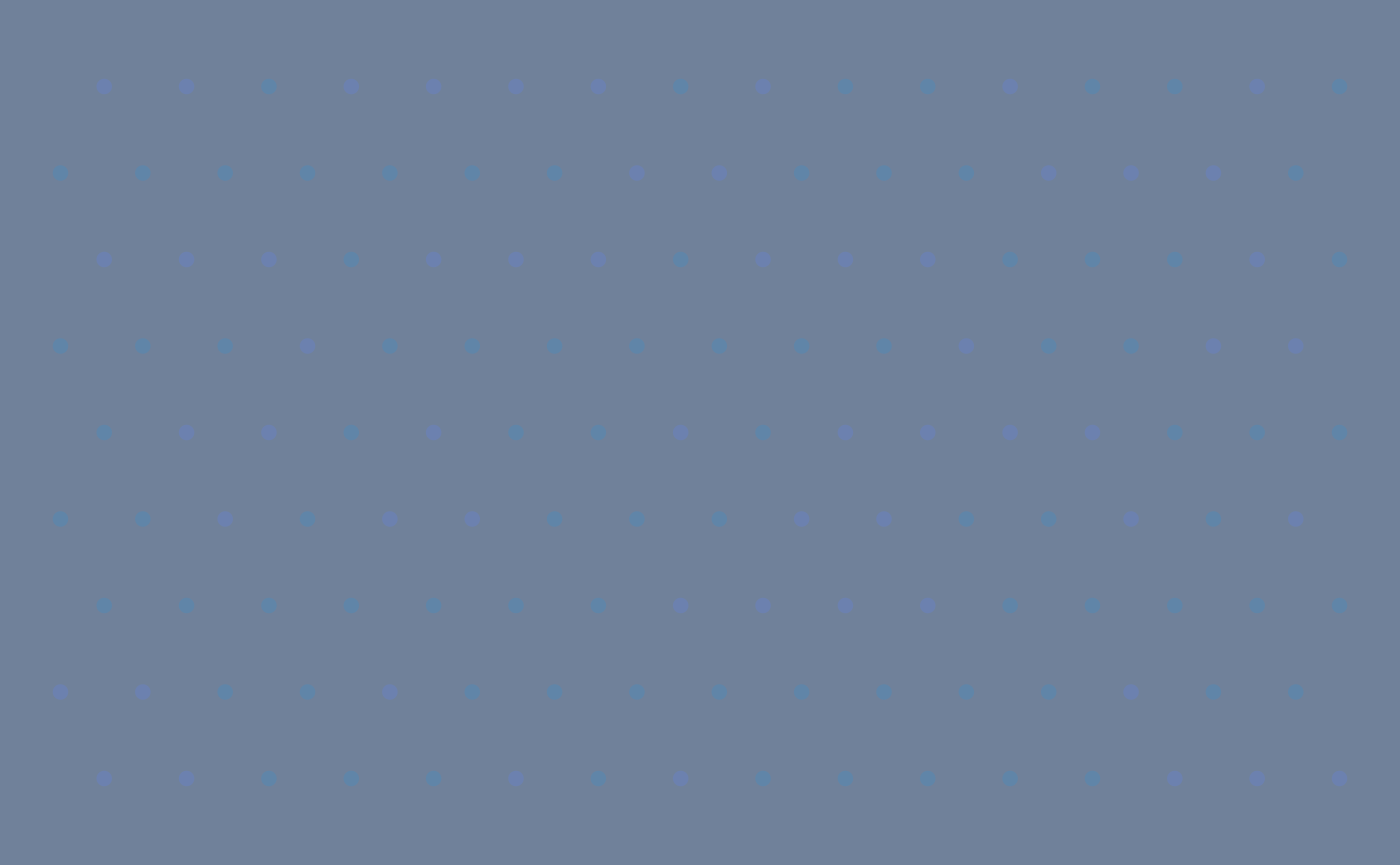

N_=np.int64(20)


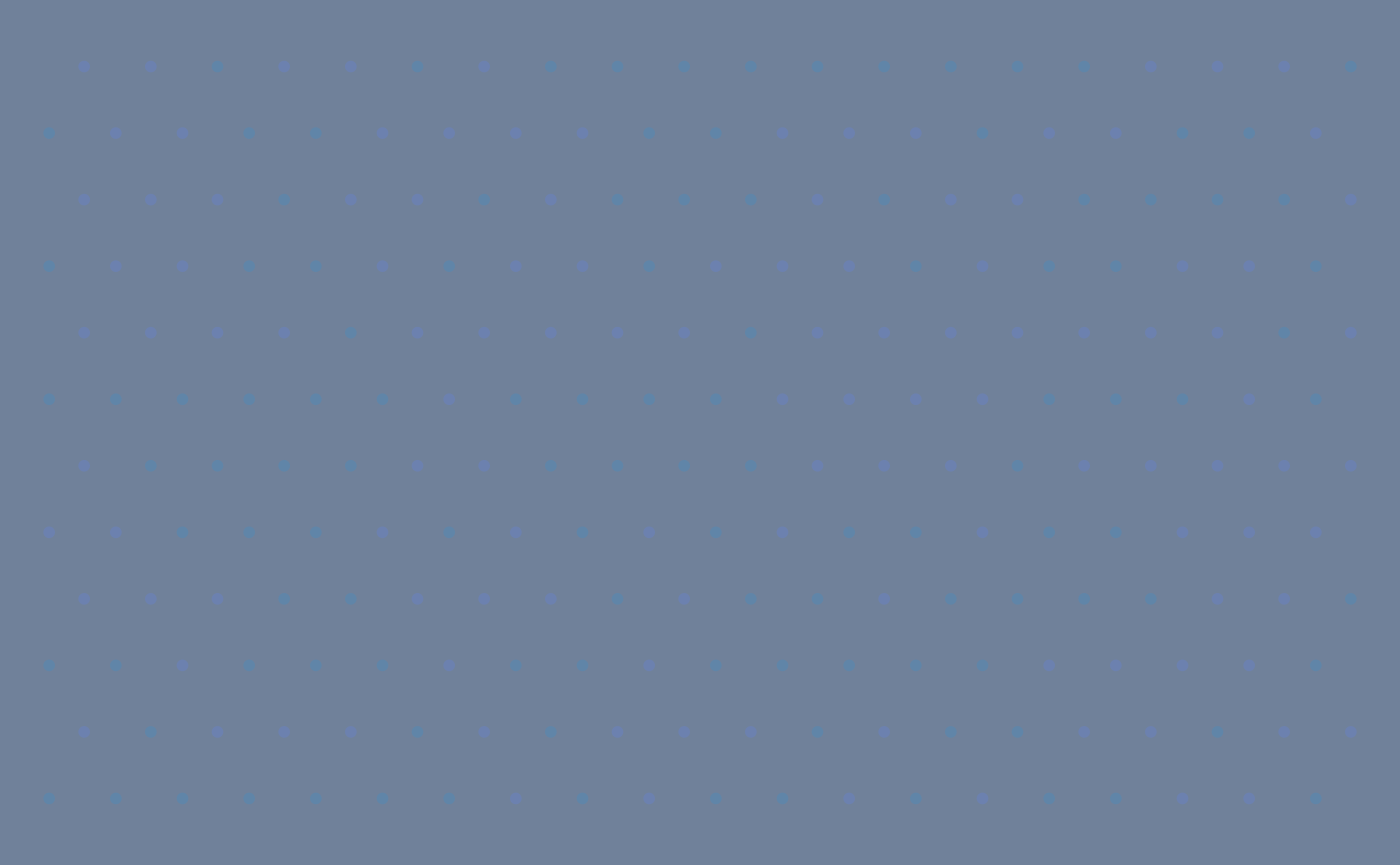

N_=np.int64(23)


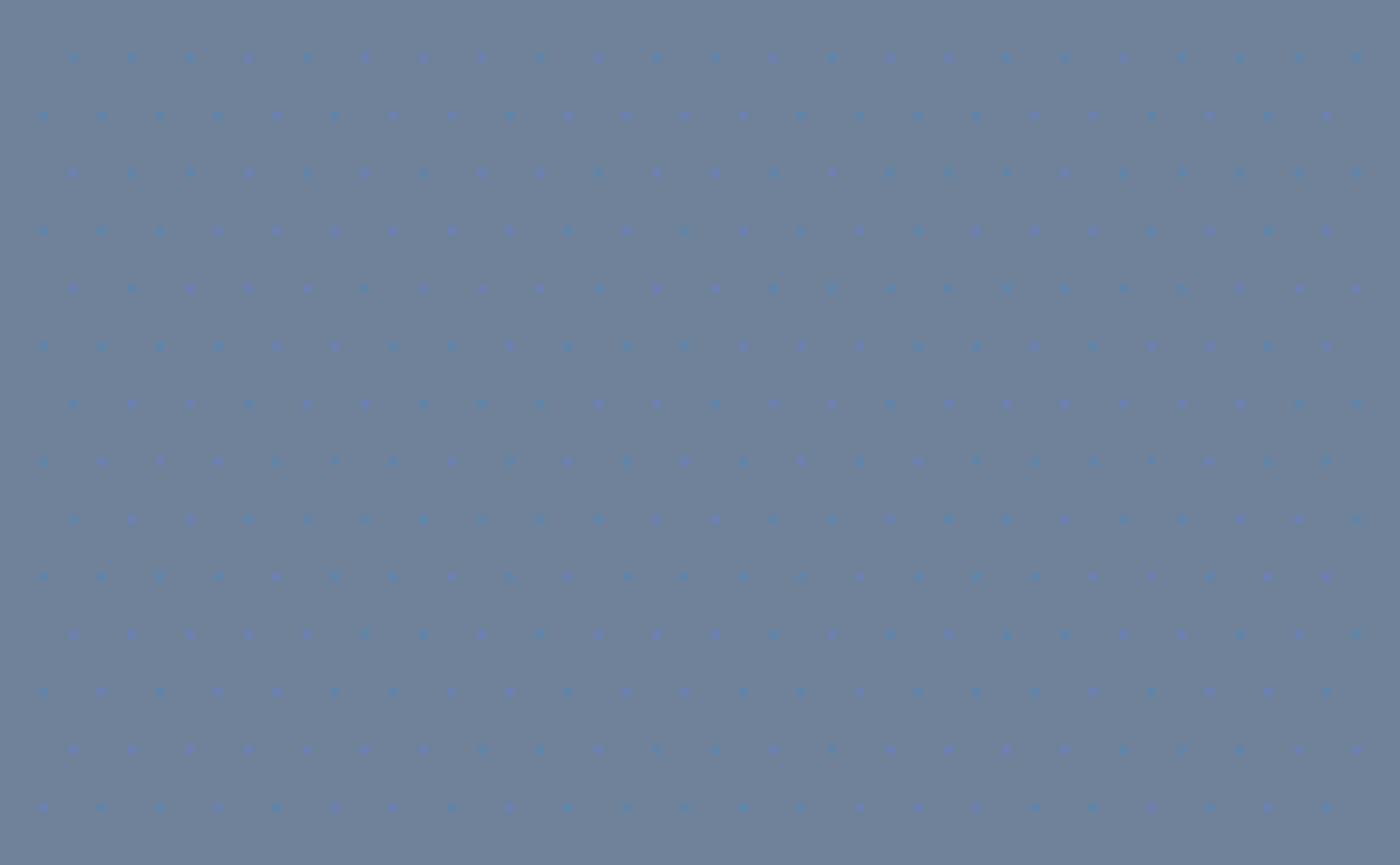

N_=np.int64(28)


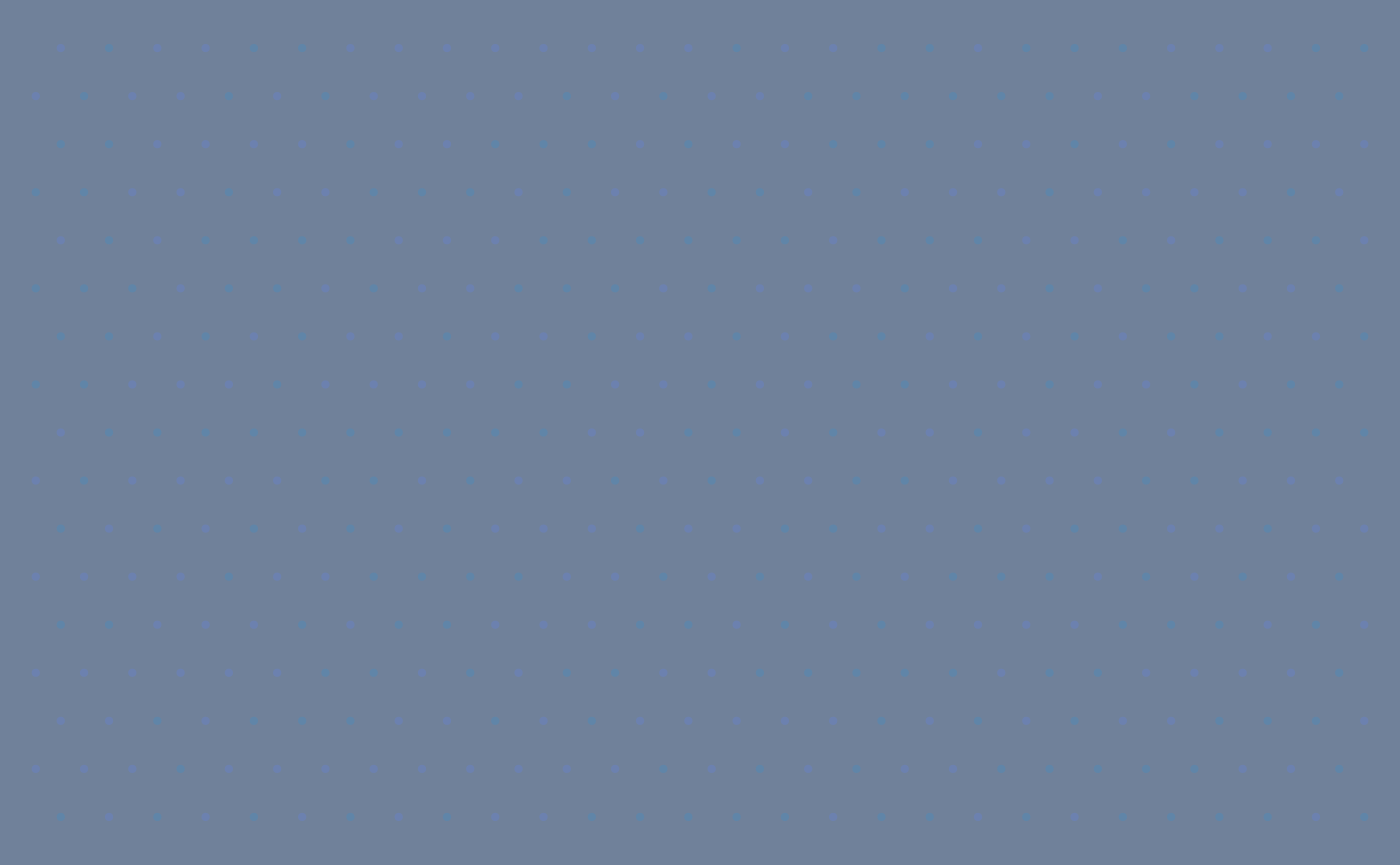

N_=np.int64(33)


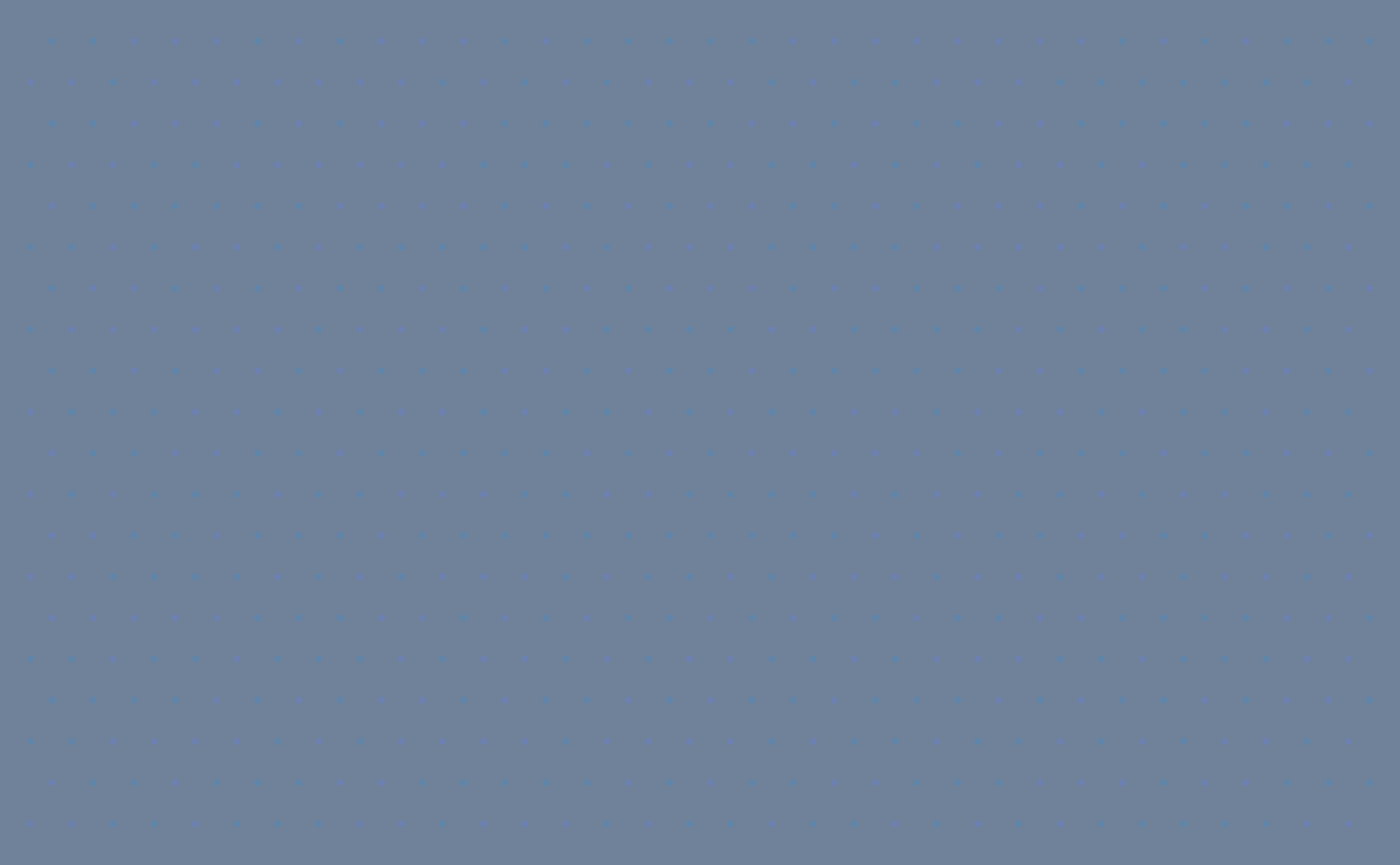

N_=np.int64(40)


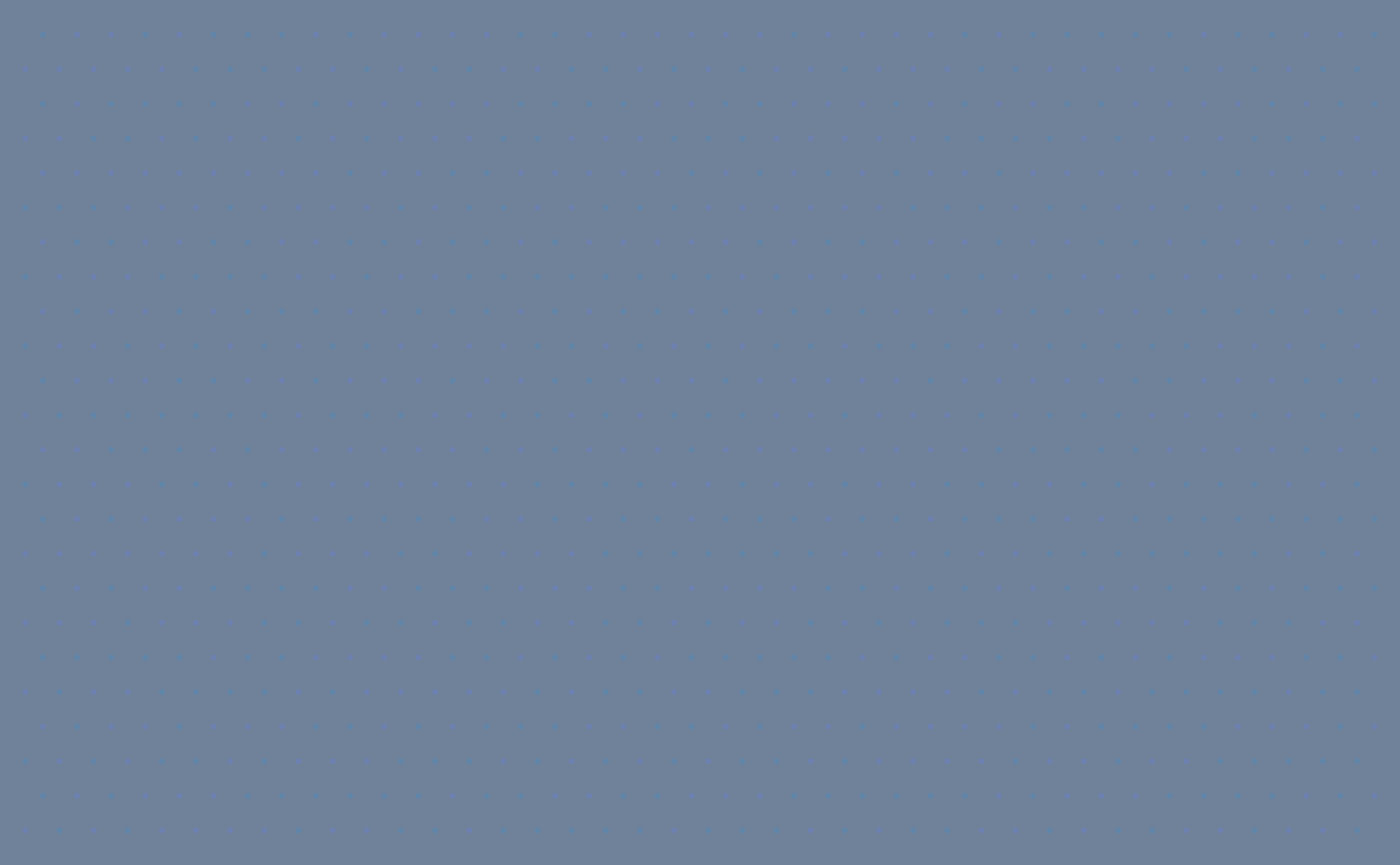

In [18]:
opts_ = opts.copy()
Ns = np.unique([int(k) for k in N_W * np.logspace(-1, 1, N_scan, base=2, endpoint=True)]).astype(int)
for N_ in Ns: 
    opts_.update(N_H=int(N_*N_height/N_width), N_W=N_)
    print(f'{N_=}')
    @disp
    def draw(cr, N_height=N_height, N_width=N_width): cr = hexagonal_grid(cr, **opts_)

### Scan Analysis: N_H and N_W (Grid Density)

First, this sweep changes lattice density, which is equivalent to changing the spatial frequency content of the pattern. Second, the code traverses density values and renders each configuration so that spacing-dependent perceptual transitions are explicit. Third, sparse spacing is usually readable everywhere, dense spacing can fuse in the periphery, and the most informative operating point is near the boundary where central segmentation remains available but peripheral parsing degrades through larger receptive-field pooling.

## shape exploration

shape_mode=circle, n_sides=6


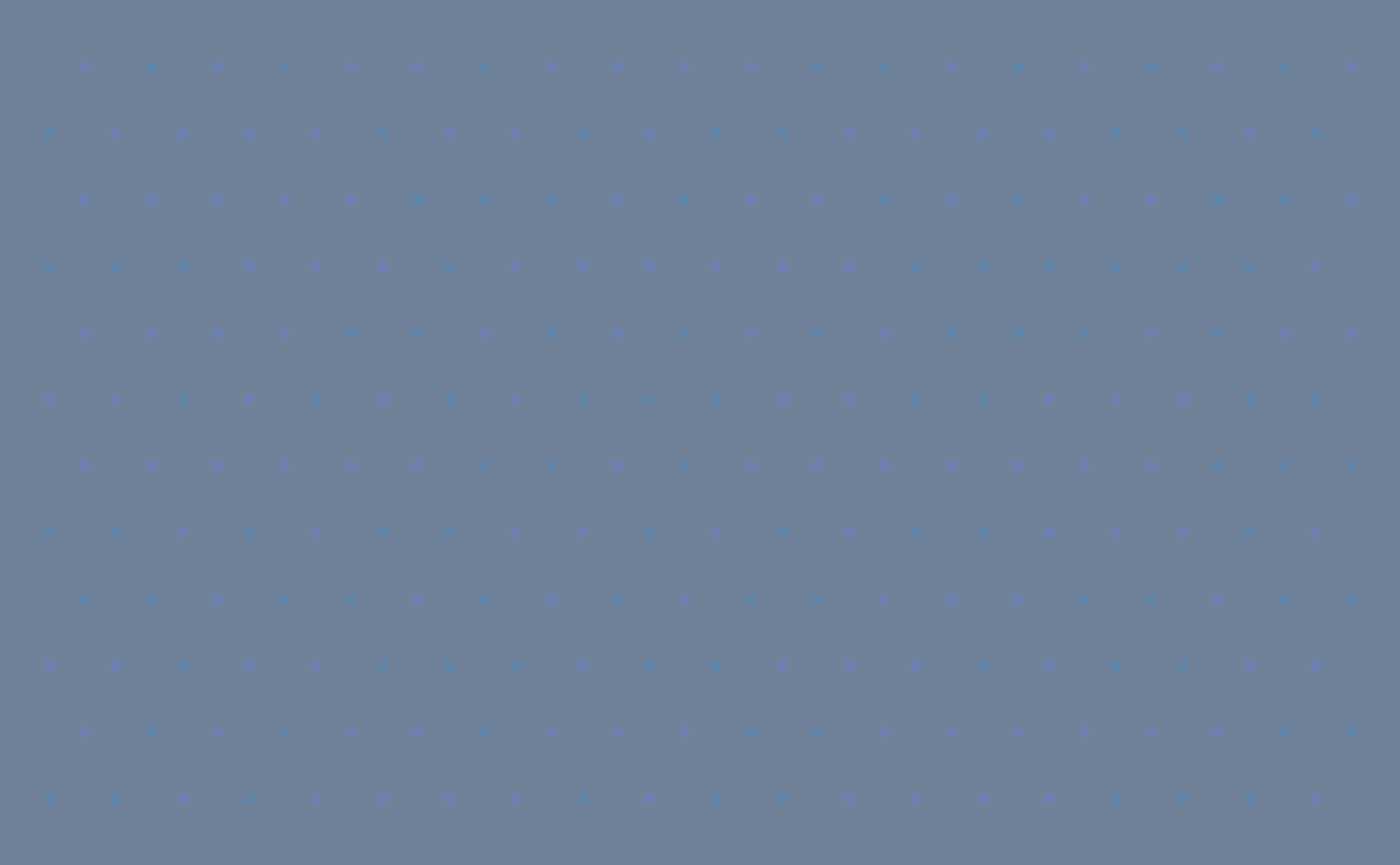

shape_mode=diagonal, n_sides=4


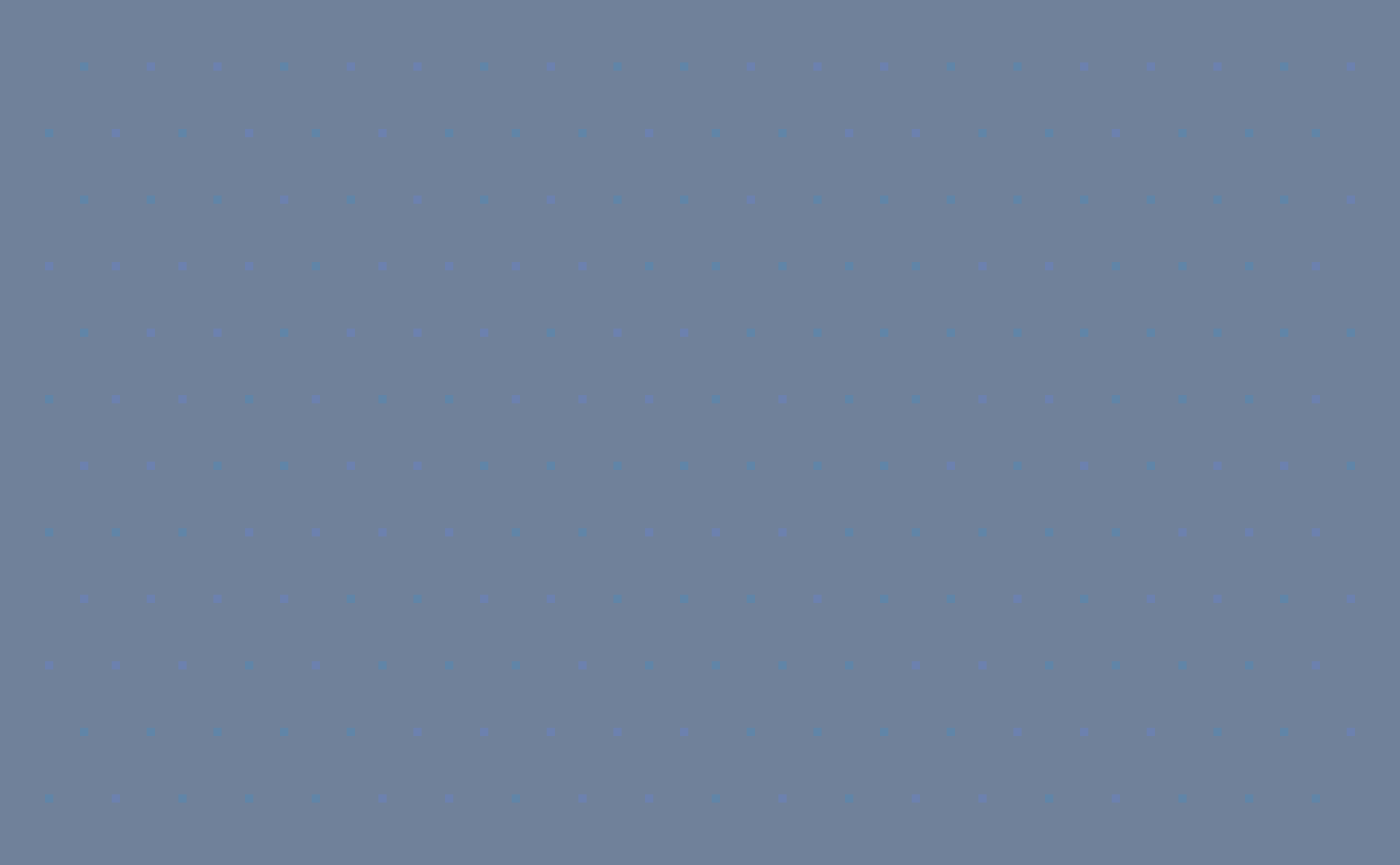

shape_mode=polygon, n_sides=3


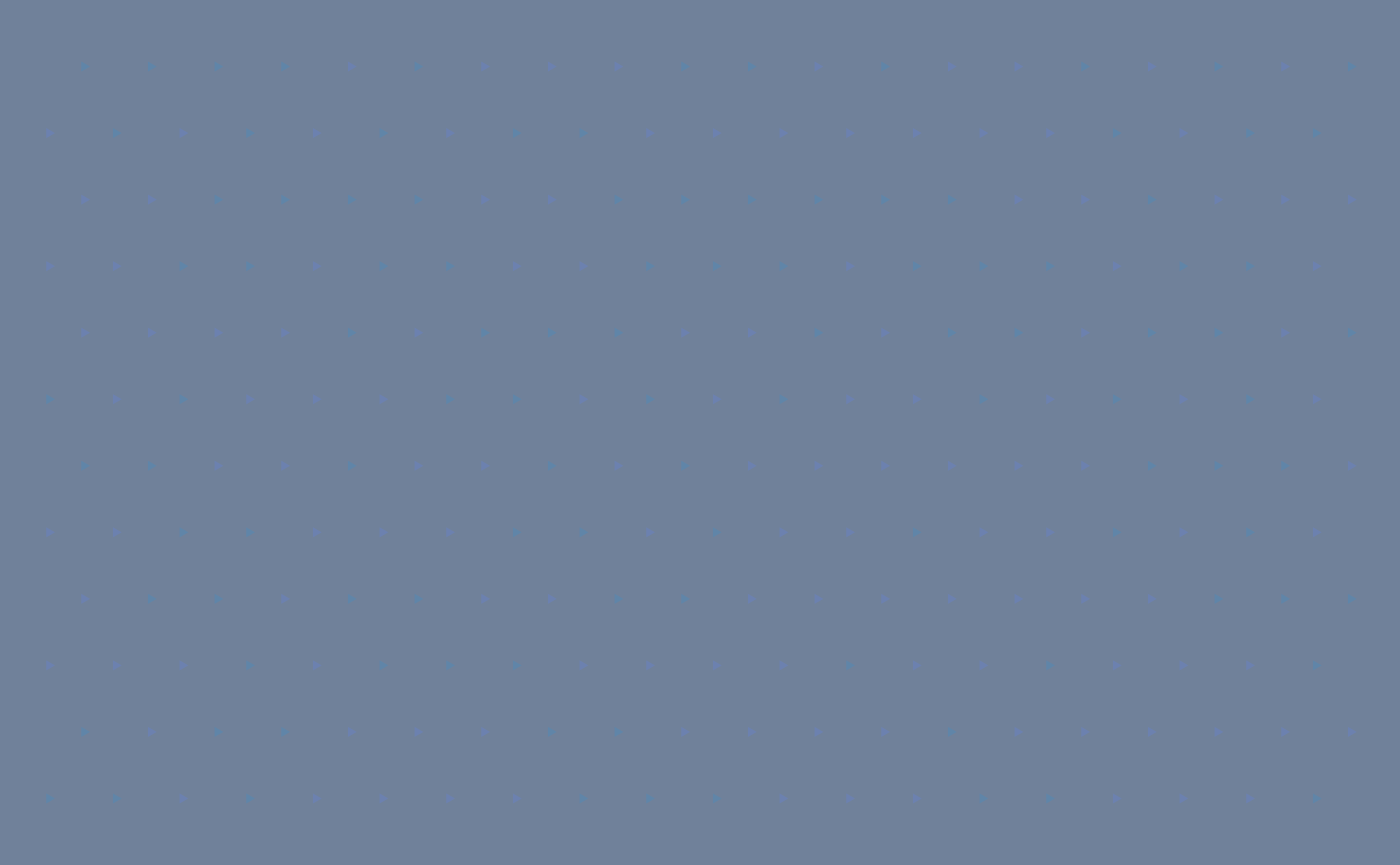

shape_mode=polygon, n_sides=4


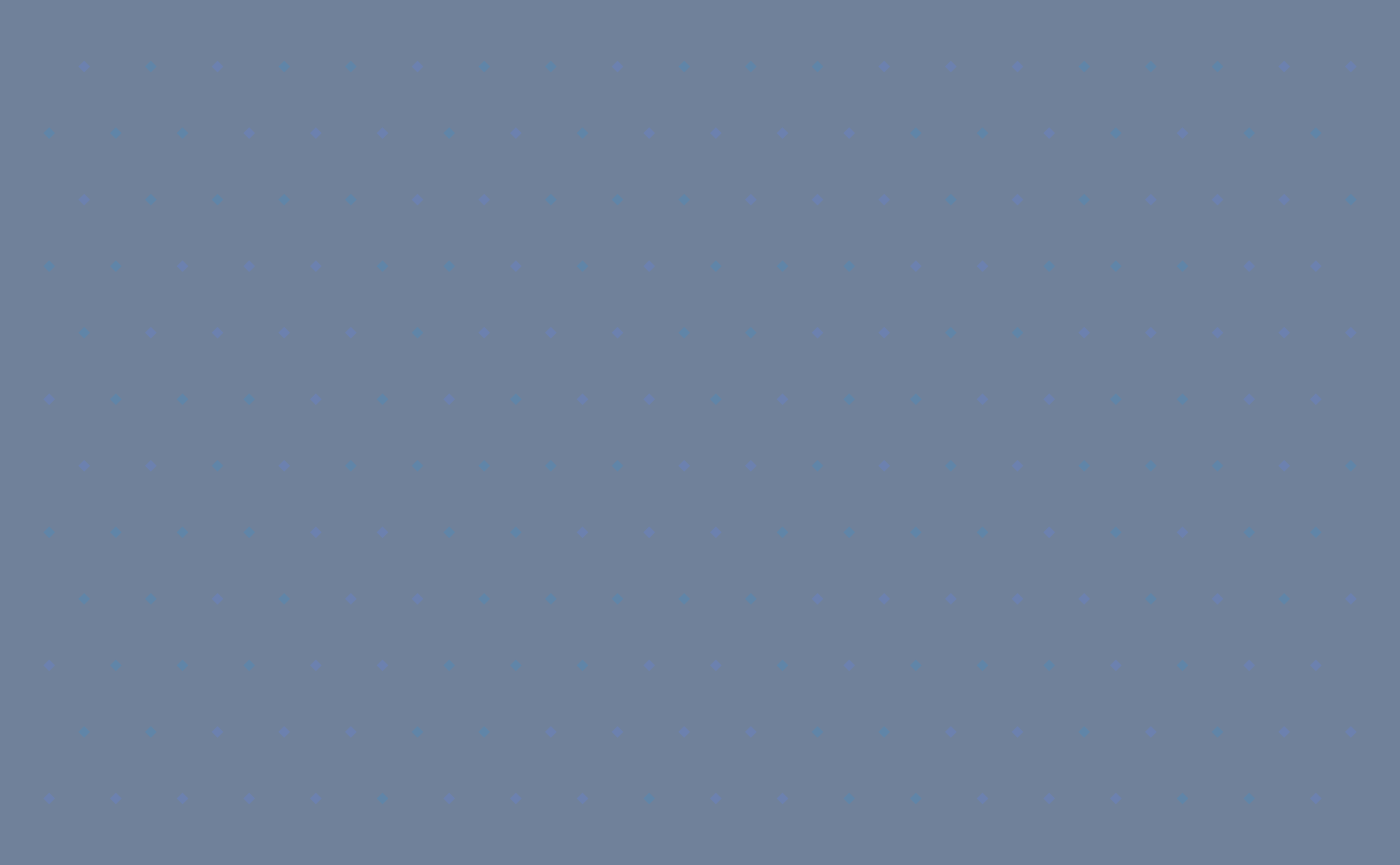

shape_mode=polygon, n_sides=5


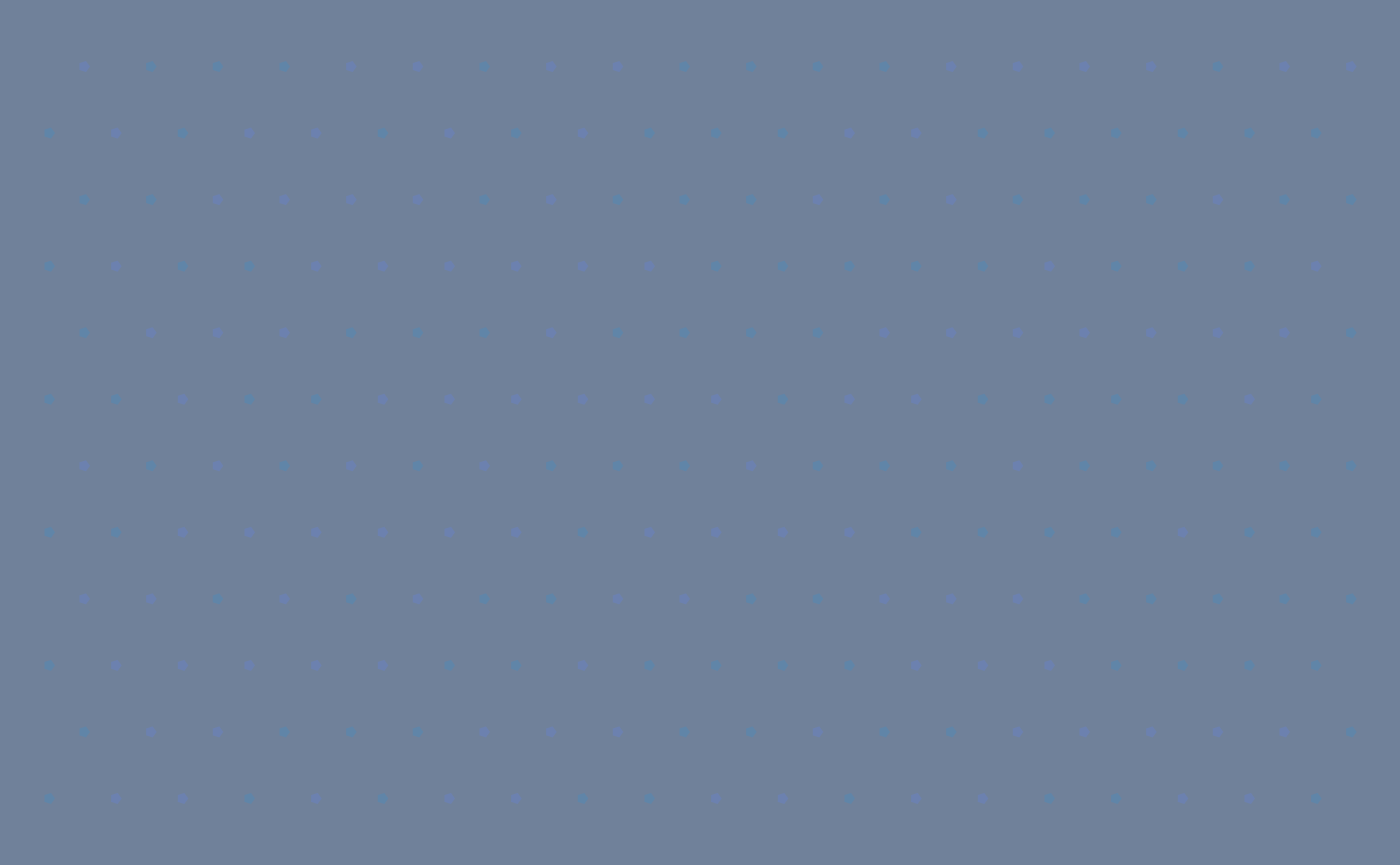

shape_mode=polygon, n_sides=6


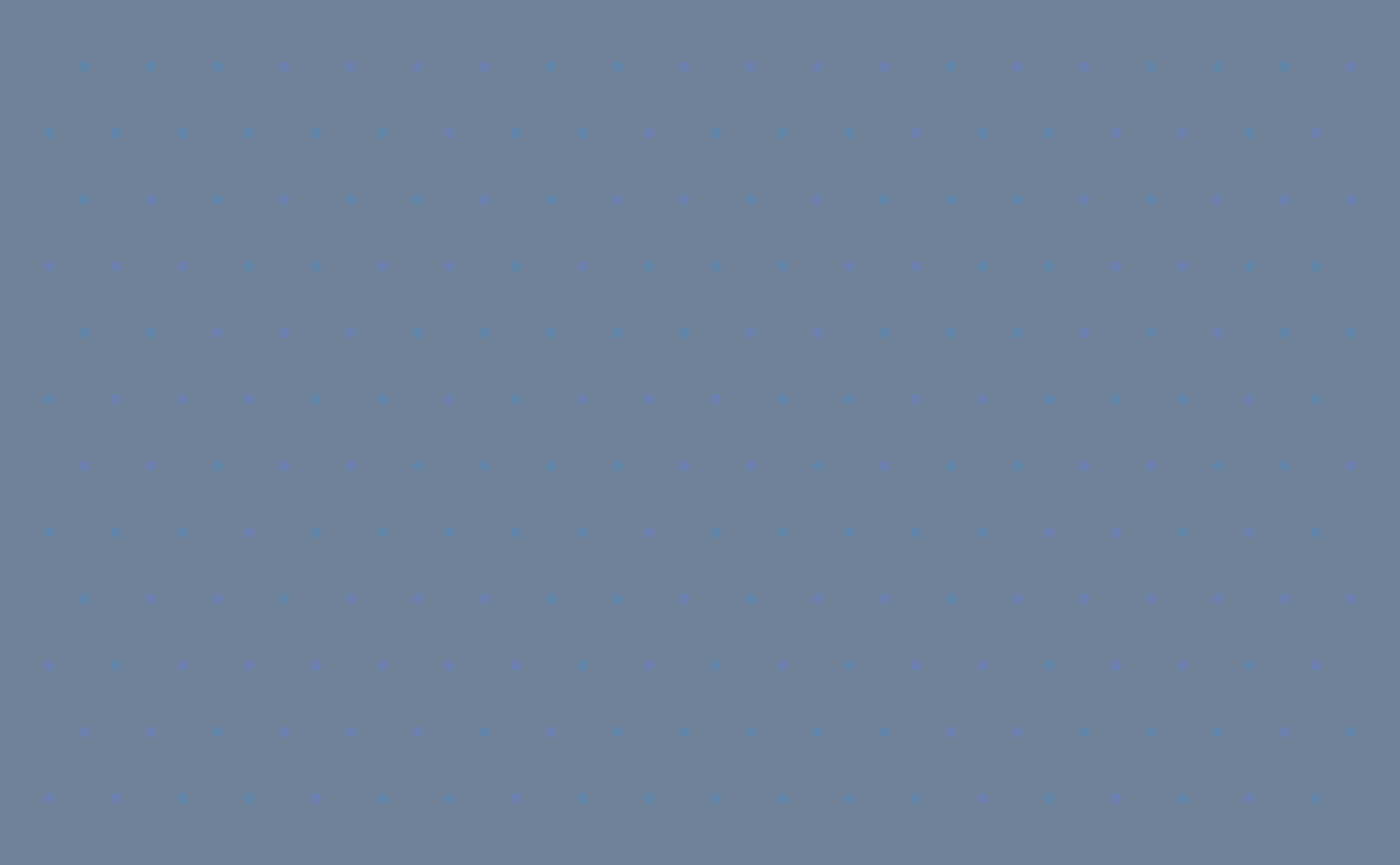

shape_mode=polygon, n_sides=8


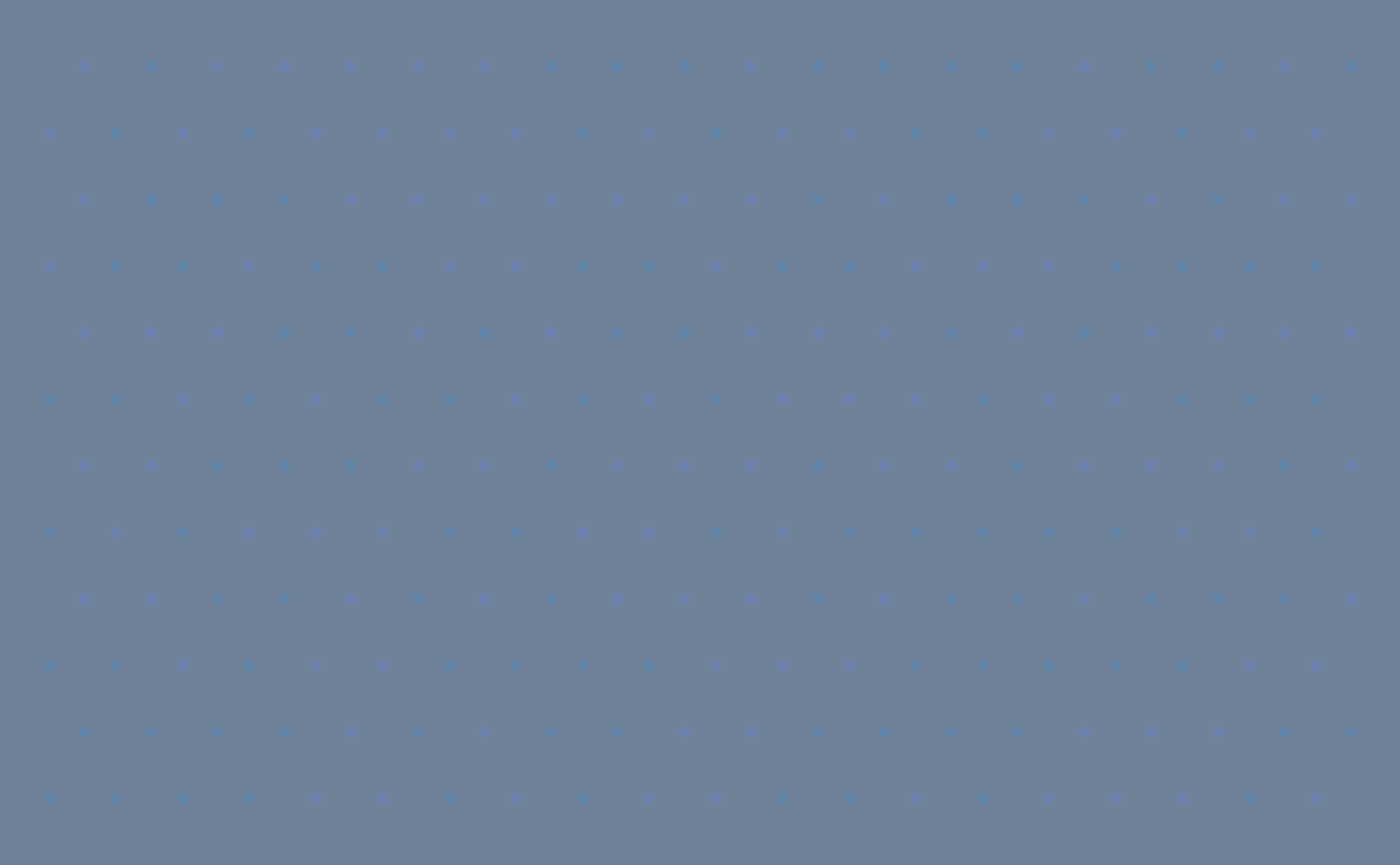

In [19]:
# Exploration of different shape families
opts_ = opts.copy()
# opts_.update(size_mag=.5, N_H=max(6, N_H//2), N_W=max(6, N_W//2))

shape_configs = [
    ('circle', 6),
    ('diagonal', 4),
    ('polygon', 3),
    ('polygon', 4),
    ('polygon', 5),
    ('polygon', 6),
    ('polygon', 8),
]

for shape_mode_, n_sides_ in shape_configs:
    opts_.update(shape_mode=shape_mode_, n_sides=n_sides_)
    print(f'shape_mode={shape_mode_}, n_sides={n_sides_}')

    @disp
    def draw(cr, N_height=N_height, N_width=N_width):
        cr = hexagonal_grid(cr, **opts_)


### Scan Analysis: Shape Family

First, this sweep changes local contour class by alternating circles, diagonals, and polygons with different side counts. Second, the code enumerates shape configurations and displays one frame per configuration, enabling direct comparison of orientation and corner cues. Third, smoother contours generally reduce explicit local anchors, whereas angular shapes increase corner energy and orientation evidence, which can improve fixation-locked parsing but may also reduce peripheral ambiguity if the cues become too strong.

## Discussion and Conclusion

Across sweeps, the most effective stimuli are those that sit near a perceptual threshold where central segmentation is reliable and peripheral structure remains unstable. This operating regime is coherent with retinal physiology, because foveal and parafoveal cone-rich regions support fine chromatic and spatial discrimination, while rod-dominated peripheral regions rely on larger pooling and weaker color-resolved parsing.

In practical terms, the illusion is strongest when opacity, size, chromatic spread, and density are jointly tuned so that dots do not become either globally invisible or globally obvious. The macular scale, roughly comparable to a thumb at arm length, offers a useful perceptual anchor for interpreting where detailed structure should remain stable in the image.

The main methodological strength of this notebook is the one-factor-at-a-time sweep strategy combined with immediate visual output. The next experimental step is to quantify these observations with psychophysical measurements, for example by measuring detectability as a function of eccentricity and mapping the parameter region that maximizes fixation-dependent appearance changes.

## some book keeping for the notebook

In [20]:
%pwd

'/Users/laurentperrinet/sdrive_cnrs/blog/laurentperrinet.github.io_sciblog/posts'

In [21]:
%load_ext watermark
%watermark -i -h -m -v -p numpy,cairo  -r -g -b

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.16.0

numpy: 2.5.1
cairo: unknown

Compiler    : Clang 17.0.0 (clang-1700.6.4.2)
OS          : Darwin
Release     : 24.6.0
Machine     : x86_64
Processor   : i386
CPU cores   : 36
Architecture: 64bit

Hostname: Ahsoka

Git hash: 4ee03959adcd2bd30bba3a2e02614b925edf5549

Git repo: https://github.com/laurentperrinet/sciblog

Git branch: master

